# Community Resource: A Genome-Guided Extension of Large-Scale Wheat Proteogenomics

---

## Author   
Dr Delphine Vincent  
_website:_ https://dlf2024.github.io/  
_github:_ https://github.com/dlf2024      
_Date:_ 18/05/2026

---

## Rationale  
This project aims at validating gene model annotations in bread wheat (_Triticum aestivum_, IWGSC RefSeq v2.1) using a proteogenomics strategy by identifying peptides/proteins in various wheat tissues from public proteomics experiments and aligning them along the genome.     
This study follows on our previous proteogenomics project from 2024 in which peptides identified in public repositories MSV000090572 and PXD004720 were aligned along the wheat genome using a tBLASTn strategy (Citation: Vincent, D.; Appels, R. (2024) Community Resource: Large-Scale Proteogenomics to Refine Wheat Genome Annotations. Int. J. Mol. Sci. 2024, 25, 8614. https://doi.org/10.3390/ijms25168614).    
The peptide alignments along bread wheat genome are publicly available from the Apollo JBrowse service (https://bread-wheat-um.genome.edu.au/apollo/49826/jbrowse/index.html).   

---

## Steps  
- 1: Data retrieval and extraction (LFTP via Ubuntu Unix outside of this notebook)
- 2: Data conversion (using MSConvert GUI outside of this notebook)
- 3: Protein database creation with decoy (using Galaxy Proteomics platform outside of this notebook)
- 4: Peptide/Protein search (using FragPipe program outside of this notebook)
- 5: Build a protein-to-gene mapping table (this notebook)
- 6: FragPipe Output Annotation and Quality Summary (this notebook)
- 7: Build non-contaminant peptide–protein evidence tables (this notebook)
- 8: Map proteins to gene models using the GFF3-derived mapping table (this notebook)
- 9: Project peptide positions from proteins onto genomic coordinates (this notebook)
- 10: Positional validation of annotation-guided peptide genome projections (this notebook)
- 11: Export all tissues BED6/BED12 files for JBrowse (this notebook)
- 12: Create a single non-redundant combined BED track (this notebook)
- 13: Generate tissue/protein/gene/isoform summary tables (this notebook)
- 14: Prepare BED Files for Apollo/JBrowse Public Upload (this notebook)
- 15: EDA: HC and LC Proteogenomic Coverage by Tissue (this notebook)
- 16: EDA: Tissue Overlap Using UpSet Plots (this notebook)
- 17: EDA: Peptide Support per Gene Model (this notebook)
- 18: EDA: Peptide Length, Probability, and Charge by Annotation Confidence  (this notebook)
- 19: EDA: Protein Length versus Peptide Support (this notebook)
- 20: EDA: Chromosomal Distribution of Peptide Genomic Start Positions (this notebook)
- 21: EDA: Circular Tissue-Level Peptide Genome Map (this notebook)
- 22: EDA: Circular Confidence-Level Peptide Genome Map (this notebook)
- 23: Combine Python workflow Summary Tables at Source/Tissue Level (this notebook)
- 24: Compare this annotation-based alignment with the tblastn one from the 2024 study (this notebook)
- 25: Sanity Checks for Annotation-Guided Peptide Genome Projections (this notebook)
- 26: Generate Sanity-Validated BED Files for Apollo/JBrowse Upload (this notebook)
- 27: Create Non-Redundant Combined Validated BED Tracks (this notebook)
- 28: Prepare manuscript Table 1 summary statistics (this notebook)

---

## Wheat Genome Annotation Source  
- Citation: The International Wheat Genome Sequencing Consortium (IWGSC); Appels, R. et al. (2018) Shifting the Limits in Wheat Research and Breeding Using a Fully Annotated Reference Genome. Science, 361, eaar7191. https://doi.org/10.1126/science.aar7191  
- IWGSC URL: https://urgi.versailles.inrae.fr/download/iwgsc/IWGSC_RefSeq_Annotations/v2.1/
- Data files:
  - iwgsc_refseqv2.1_annotation_200916_LC.gff3 (genome annotations of low confidence (LC) gene models)
  - iwgsc_refseqv2.1_annotation_200916_HC.gff3 (genome annotation of high confidence (HC) gene models)
  - iwgsc_refseqv2.1_functional_annotation.csv (gene model functional annotations)
  - iwgsc_refseqv2.1_annotation_200916_HC_pep.fasta (AA sequences of HC gene models)
  - iwgsc_refseqv2.1_annotation_200916_LC_pep.fasta (AA sequences of LC gene models)

---

## MS-Proteomics Raw Data Sources 

### Liu et al 2025 (PXD050500)  
- Citation: Liu S, et al (2025) A telomere-to-telomere genome assembly coupled with multi-omic data provides insights into the evolution of hexaploidy bread wheat. Nature Genetics, 57: 1008-1020. https://doi.org/10.1038/s41588-025-02137-x   
- ProteomeXchange URL: https://proteomecentral.proteomexchange.org/cgi/GetDataset?ID=PXD050500   
- PRIDE URL: https://www.ebi.ac.uk/pride/archive/projects/PXD050500    
- FTP URL: https://ftp.pride.ebi.ac.uk/pride/data/archive/2024/12/PXD050500/   
- Data files: 180 .d files (timsTOF Pro mass spectrometer, Bruker Daltonics) - 400 GB
- Tissues: 
  - node (60 fractions)
  - coleoptile (60 fractions)
  - radicle (60 fractions)

### Vincent et al 2023 (MSV000090572)    
- Citation: Vincent, D. et al. (2023) A Community Resource to Mass Explore the Wheat Grain Proteome and Its Application to the Late-Maturity Alpha-Amylase (LMA) Problem. GigaScience, 12, giad084. https://doi.org/10.1093/gigascience/giad084     
- MassIVE URL: https://massive.ucsd.edu/ProteoSAFe/result.jsp?task=9e8c4c3c9d924de8800237e7e828e1d9&view=advanced_view#%7B%7D   
- FTP URL: ftp://massive-ftp.ucsd.edu/v05/MSV000090572/
- Data files: 62 .raw files (LTQ Orbitrap Elite mass analyser, Thermo Scientific) - 12 GB
- Tissues:
  - stored grains (mature, harvested grains stored in optimum conditions)

### Duncan et al 2017 (PXD004720)     
- Citation: Duncan, O. et al (2017) Resource: Mapping the Triticum aestivum Proteome. Plant J., 89, 601-616. https://doi.org/10.1111/tpj.13402      
- ProteomeXchange URL: https://proteomecentral.proteomexchange.org/ui?pxid=PXD004720    
- PRIDE URL: https://www.ebi.ac.uk/pride/archive/projects/PXD004720   
- FTP URL: https://ftp.pride.ebi.ac.uk/pride/data/archive/2016/11/PXD004720/
- Data files: 335 .mzXML files (QTOF, Agilent) - 600 GB
- Tissues:
  - anther (12 fractions)
  - boot (12 fractions)
  - coleoptile (12 fractions)
  - embryo (12 fractions)
  - endosperm (12 fractions)
  - glume (12 fractions)
  - grain-zadoks-70 (12 fractions)
  - grain-zadoks-71 (12 fractions)
  - grain-zadoks-75 (12 fractions)
  - grain-zadoks-83 (12 fractions)
  - grain-zadoks-87 (12 fractions)
  - leaf-flag-mature (12 fractions)
  - leaf-flag-senescing (12 fractions)
  - leaf-flag-young (12 fractions)
  - lemma (12 fractions)
  - node (12 fractions)
  - node_secretion (12 fractions)
  - palea (11 fractions)
  - pericarp (12 fractions)
  - pollen (12 fractions)
  - rachilla (12 fractions)
  - radicle (12 fractions)
  - root-mature (12 fractions)
  - root-secretion (12 fractions)
  - root-tip (12 fractions)
  - root-vasculature (12 fractions)
  - spike-immature (12 fractions)
  - stem (12 fractions)

---

## Computational environment  
- Windows 10
- WSL2 Ubuntu 24.04
- Python 3.12
- JupyterLab 4.3.4
- FragPipe 24.0
- MSFragger 4.4.1
- ProteoWizard MSConvert 3.0
- Galaxy Proteomics platform

---

## Folder architecture  
project/   
├── raw_data/    
├── mzML/    
├── genome_annotation/    
├── protein_database/    
├── fragpipe_results/    
├── tblastn_results/  
├── python_outputs/    
│      ├── bed/    
│      ├── tables/    
│      └── figures/  

---

## AI-assisted workflow development   
Portions of the Python workflow, code optimisation, debugging assistance, and markdown documentation were developed with the assistance of OpenAI ChatGPT (GPT-5 series) under the direction and scientific supervision of the author.   
All computational workflows, parameter selections, biological interpretations, quality control, and final validation were performed and verified by the author.  

---

## Apollo JBrowse Deployment

Projected peptide alignments generated from this workflow are publicly available through the Apollo JBrowse genome browser:  

https://bread-wheat-um.genome.edu.au/apollo/49826/jbrowse/index.html

Tracks include:
- annotation-guided peptide genome projections
- BED6 and BED12 visualisation tracks
- tissue-specific peptide mappings
- non-redundant combined peptide tracks 

# Step 1 — Data Retrieval and Extraction

Large-scale public proteomics datasets were retrieved from the PRIDE and MassIVE repositories using the Linux command-line utility `lftp` executed within a Ubuntu WSL2 environment under Windows 11. Due to the large data volume (>1 TB total), data management and storage optimisation were critical considerations throughout the workflow.

---

## Computational environment

### Operating system
- Windows 11 Pro
- WSL2 Ubuntu Linux

### Software
- `lftp`
- `7zip`
- Windows PowerShell

### Install required Linux utilities

```bash
sudo apt update
sudo apt install lftp p7zip-full
```

---

## Data retrieval using lftp (e.g. PXD050500)

### Create new directory to store files

```bash
mkdir -p /mnt/e/wheat_proteogenomics/PXD050500
cd /mnt/e/wheat_proteogenomics/PXD050500
```

### Connect to public repository (PRIDE)

```bash
lftp ftp.pride.ebi.ac.uk
```

### Inside the `lftp` session, download files

```bash
cd /pride/data/archive/2024/12/PXD050500
mirror --verbose .
exit
```

---

## Monitoring storage usage in WSL2

Large downloads can rapidly consume WSL2 virtual disk space.

### Check Linux folder size

```bash
du -sh /root/wheat_pride/PXD004720
```

### Check available disk space

```bash
df -h
```

### Cleaning temporary files

```bash
rm -rf /tmp/*
```

---

## Archive extraction

### Test archive integrity before extraction

```bash
7z t filename.rar
```

### Extract archive

```bash
7z x filename.rar
```

### Remove extracted archives no longer needed

```bash
rm filename.rar
```

---

## WSL2 disk cleanup

After deleting large datasets, WSL2 virtual disks may still occupy substantial space on the Windows drive.

### Shutdown WSL2

```powershell
wsl --shutdown
```

### Locate the virtual disk

```powershell
Get-ChildItem "$env:LOCALAPPDATA\Packages" -Recurse -Filter ext4.vhdx
```

---

## Notes

- Download times varied from several hours to multiple days depending on repository speed and internet bandwidth.
- Stable internet connection and uninterrupted power supply were strongly recommended.
- External SSD storage substantially improved workflow efficiency compared to mechanical HDD devices.

# Step 2 — Data Conversion using MSConvert

Some raw mass spectrometry files required conversion into the open standard `.mzML` format prior to peptide identification analysis in FragPipe. File conversion was performed using the ProteoWizard software suite (`MSConvert GUI`) under Windows 11.

### Software
- ProteoWizard MSConvert
- URL: https://proteowizard.sourceforge.io/

---

## Input formats

### PXD004720
- Input format: `.mzXML`
- Instrument: Agilent QTOF

### MSV000090572
- Input format: `.raw`
- Instrument: Thermo Orbitrap Elite

### PXD050500
- Input format: `.d`
- Instrument: Bruker timsTOF Pro
- No conversion required for FragPipe analysis

---

## MSConvert GUI workflow

### 1. Launch MSConvert GUI

Open:
```text
ProteoWizard → MSConvert
```

### 2. Select input files

- Click `Browse`
- Select raw data files
- Add files to processing queue

### 3. Select output directory

Choose destination folder for converted files.

Example:
```text
E:\wheat_proteogenomics\PXD004720\mzML\
```

---

## Recommended conversion settings

### Output format
```text
mzML
```

### Binary encoding precision
```text
64-bit
```

### Compression
```text
zlib compression
```

### Peak picking
```text
Vendor peak picking
```

### Use zlib compression
```text
Enabled
```

### Write index
```text
Enabled
```

### TPP compatibility
```text
Enabled
```

---

## Start conversion

Click:
```text
Start
```

Converted `.mzML` files were subsequently used as input for FragPipe peptide identification workflows.

---

## Notes

- File conversion duration depended on instrument type and file size.
- Some Agilent `.mzXML` files from PXD004720 were unreadable by FragPipe and required reconversion using MSConvert.
- Output `.mzML` files substantially increased compatibility and stability during downstream peptide identification analyses.

# Step 3 — FASTA Database Creation

A combined target-decoy protein database was created using Galaxy Proteomics by merging high-confidence (HC) and low-confidence (LC) wheat protein annotations together with the common Repository of Adventitious Proteins (cRAP) contaminant database.

## Wheat protein sequence source

- IWGSC URL:
  https://urgi.versailles.inrae.fr/download/iwgsc/IWGSC_RefSeq_Annotations/v2.1/

### Input FASTA files

```text
iwgsc_refseqv2.1_annotation_200916_HC_pep.fasta
iwgsc_refseqv2.1_annotation_200916_LC_pep.fasta
```

---

## Software

### Galaxy Proteomics platform

- Galaxy URL:
  https://proteomics.usegalaxy.eu/


---

## Upload wheat FASTA files

### Open tool

```text
Upload Data
```

### Workflow

- Click `Choose local file`
- Select HC and LC FASTA files
- Click `Start`

---

## Download cRAP contaminant database

The cRAP database contains common mass spectrometry contaminants such as keratins and trypsin.

### Open tool

```text
Protein Database Downloader
```

### Settings

```text
Database = cRAP (contaminants)
```

### Run tool

Click:

```text
Run Tool
```

---

## Merge FASTA databases and remove duplicate entries

### Open tool

```text
FASTA Merge Files and Filter Unique Sequences
```

### Settings

#### Merge strategy

```text
Merge all FASTAs (always output a single FASTA)
```

#### Input files

```text
HC + LC + cRAP FASTA files
```

#### Duplicate filtering mode

```text
Accession Only
```

#### Parsing rule

```text
^>([^ ]+).*$
```

### Run tool

Click:

```text
Run Tool
```

---

## Create decoy database

A reverse-sequence decoy database was generated for false discovery rate (FDR) estimation during peptide identification.

### Open tool

```text
Create Decoy Database (reverse)
```

### Settings

#### Include original sequences

```text
Yes
```

#### Decoy prefix

```text
decoy_
```

### Run tool

Click:

```text
Run Tool
```

---

## Download final protein database

Download the generated target-decoy FASTA database locally.

### Final database filename

```text
iwgsc_refseqv2.1_annotation_200916_HC_LC_pep_cRAP_with_DECOY.fasta
```

---

## Notes

- HC = high-confidence gene models.
- LC = low-confidence gene models.
- Reverse decoy sequences were used for downstream FDR estimation in FragPipe.
- Inclusion of the cRAP database improved contaminant identification and filtering during peptide searches.

# Step 4 — Peptide and Protein Search using FragPipe

Peptide and protein identification was performed using FragPipe with MSFragger against the combined wheat HC/LC target-decoy protein database containing cRAP contaminant sequences. All tissues were processed using the same FragPipe workflow and search parameters.

---

## Software

### FragPipe workflow version

```text
FragPipe version: 24.0
MSFragger version: 4.4.1
Philosopher version: 5.1.3-RC9
ProteinProphet: enabled
PeptideProphet: enabled
Percolator: disabled
IonQuant: disabled
```

---

## Input files

FragPipe searches were performed on the converted or native mass spectrometry files for each tissue.

### Input formats

```text
PXD050500    Bruker .d folders
MSV000090572 Thermo .raw files
PXD004720    mzML files converted from mzXML
```

---

## Protein database

The following combined target-decoy FASTA database was used:

```text
iwgsc_refseqv2.1_annotation_200916_HC_LC_pep_cRAP_with_DECOY.fasta
```

### Decoy prefix

```text
decoy_
```

---

## Workflow setup

For each tissue, a separate FragPipe run was created.

### Example output directory

```text
C:\Users\Delphine_2026\FragPipe_results\PDX004720_stem_run01
```

### Computational settings

```text
Threads: 4
RAM: 32 GB
Data type: DDA
```

---

## MSFragger search parameters

### Enzyme specificity

```text
Enzyme: Trypsin/P
Cleavage residues: K, R
Cleavage direction: C-terminal
Number of enzymatic termini: 2
Allowed missed cleavages: 10
```

### Peptide length and mass range

```text
Minimum peptide length: 6 aa
Maximum peptide length: 100 aa
Peptide mass range: 300–10,000 Da
```

### Precursor mass tolerance

```text
Precursor mass tolerance: ±10 ppm
True precursor mass tolerance: ±20 ppm
Isotope error: 0/1/2
Precursor mass mode: selected
```

### Fragment mass tolerance

```text
Fragment mass tolerance: ±0.05 Da
Fragment ion series: b, y
Maximum fragment charge: 10
```

### Precursor charge

```text
Charge range: 1–4
Override charge: disabled
```

---

## Modifications

### Fixed modification

```text
Cysteine carbamidomethylation: +57.02146 Da
```

### Variable modifications

```text
Methionine oxidation: +15.9949 Da
Protein N-terminal acetylation: +42.0106 Da
Protein N-terminal methionine clipping: enabled
```

### Variable modification limits

```text
Maximum variable modifications per peptide: 3
Maximum modified forms per peptide: 5
```

---

## Spectrum processing

```text
Deisotoping: enabled
Neutral loss removal: enabled
Remove precursor peak: enabled
Precursor removal range: -1.5 to +1.5 Th
Minimum peaks per spectrum: 15
Top N peaks used: 150
Minimum matched fragments: 4
Minimum fragments for modelling: 2
```

---

## Validation and reporting

### Validation tools

```text
PeptideProphet: enabled
ProteinProphet: enabled
Percolator: disabled
```

### Report settings

```text
Protein FDR: 1%
Sequential filtering: enabled
Peptide-level summary: enabled
Protein-level summary: enabled
Decoys printed in final report: no
Contaminants removed in final report: yes
```

---

## FragPipe outputs used downstream

The main FragPipe output files used for downstream annotation and genome projection were:

```text
psm.tsv
peptide.tsv
protein.tsv
combined_protein.tsv
experiment_annotation.tsv / sdrf.tsv
```

These files were subsequently imported into Python for annotation, contaminant filtering, peptide–protein association, protein-to-gene mapping, and peptide genomic coordinate projection.

---

## Notes

- Each tissue was processed independently to simplify batch management and avoid excessive memory usage.
- The same FragPipe workflow and MSFragger parameters were applied across all 32 tissues.
- The workflow was optimised for peptide/protein identification rather than label-free quantification.
- Matched fragment export was disabled to reduce output size and improve run stability.
- Output files are captured in a file manifest "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

# Step 5 — Build a protein-to-gene mapping table
_inputs:_   
- iwgsc_refseqv2.1_annotation_200916_HC.gff3
- iwgsc_refseqv2.1_annotation_200916_LC.gff3
- iwgsc_refseqv2.1_functional_annotation.csv

__Aim:__  
Map each protein accession / gene model to:  
- chromosome
- gene coordinates
- transcript/CDS model
- HC/LC status
- functional annotation

__Summary:__  
_Parse the wheat GFF3 annotations and build a protein-to-gene mapping table_  
This step parses the high-confidence (HC) and low-confidence (LC) wheat GFF3 annotation files and extracts the structural relationships among genes, transcripts, and CDS features.   
The goal is to create a clean annotation table linking protein accessions and gene models to chromosome, strand, genomic coordinates, and annotation confidence level.   
This table will then be merged into the FASTA-validated peptide–protein evidence in the next step.

In [1]:
#################### Wheat genome data ########################

# ============================================================
# Parse HC + LC GFF3 files and build protein-to-gene mapping table (takes 5 min)
# ============================================================

import pandas as pd
import numpy as np
import re

# -----------------------------
# 1. Input / output file names
# -----------------------------
hc_gff3 = "genome_annotation/iwgsc_refseqv2.1_annotation_200916_HC.gff3"
lc_gff3 = "genome_annotation/iwgsc_refseqv2.1_annotation_200916_LC.gff3"

features_out = "python_outputs/tables/wheat_gff3_parsed_features_HC_LC.csv"
mapping_out  = "python_outputs/tables/wheat_protein_gene_mapping_HC_LC.csv"
summary_out  = "python_outputs/tables/wheat_gff3_parsing_summary_HC_LC.csv"

# -----------------------------
# 2. Helper functions
# -----------------------------
def parse_attributes(attr_text):
    attrs = {}
    if pd.isna(attr_text):
        return attrs

    for item in str(attr_text).strip().split(";"):
        if not item.strip():
            continue
        if "=" in item:
            key, value = item.split("=", 1)
            attrs[key.strip()] = value.strip()
        else:
            attrs[item.strip()] = ""
    return attrs

def strip_prefix(value):
    if value is None or pd.isna(value):
        return np.nan
    value = str(value).strip()
    value = re.sub(r"^[A-Za-z_]+:", "", value)
    return value

def split_multi(value):
    if value is None or pd.isna(value):
        return []
    return [strip_prefix(x.strip()) for x in str(value).split(",") if x.strip()]

def gene_model_from_protein(protein_id):
    if protein_id is None or pd.isna(protein_id):
        return np.nan
    protein_id = str(protein_id).strip()
    return re.sub(r"\.\d+$", "", protein_id)

def normalise_feature_type(ftype):
    ftype = str(ftype)
    if ftype in {"mRNA", "transcript"}:
        return "transcript"
    return ftype

# -----------------------------
# 3. GFF3 parser
# -----------------------------
def parse_gff3(filepath, confidence_label):
    rows = []

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line.strip() or line.startswith("#"):
                continue

            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue

            seqid, source, feature_type, start, end, score, strand, phase, attributes = parts
            feature_type = normalise_feature_type(feature_type)
            attrs = parse_attributes(attributes)

            rows.append({
                "SeqID": seqid,
                "Source_gff": source,
                "FeatureType": feature_type,
                "Start": int(start),
                "End": int(end),
                "Score": score if score != "." else np.nan,
                "Strand": strand,
                "Phase": phase if phase != "." else np.nan,
                "Attributes": attributes,
                "Annotation_confidence": confidence_label,
                "ID_raw": attrs.get("ID", np.nan),
                "Parent_raw": attrs.get("Parent", np.nan),
                "Name": attrs.get("Name", np.nan),
                "biotype": attrs.get("biotype", attrs.get("gene_biotype", np.nan)),
                "protein_id_raw": attrs.get("protein_id", np.nan),
                "Derives_from_raw": attrs.get("Derives_from", np.nan),
            })

    df = pd.DataFrame(rows)

    df["ID"] = df["ID_raw"].apply(strip_prefix)
    df["Parent"] = df["Parent_raw"].apply(lambda x: ", ".join(split_multi(x)) if pd.notna(x) else np.nan)
    df["protein_id"] = df["protein_id_raw"].apply(strip_prefix)
    df["Derives_from"] = df["Derives_from_raw"].apply(lambda x: ", ".join(split_multi(x)) if pd.notna(x) else np.nan)

    return df

# -----------------------------
# 4. Parse HC + LC GFF3 files
# -----------------------------
hc_df = parse_gff3(hc_gff3, "HC")
lc_df = parse_gff3(lc_gff3, "LC")
features = pd.concat([hc_df, lc_df], ignore_index=True)

print(f"Parsed HC features: {hc_df.shape[0]:,}")
print(f"Parsed LC features: {lc_df.shape[0]:,}")
print(f"Combined features:  {features.shape[0]:,}")

features.to_csv(features_out, index=False)
print(f"Saved parsed feature table to: {features_out}")

# -----------------------------
# 5. Extract genes
# -----------------------------
genes = features[features["FeatureType"] == "gene"].copy()

genes = genes.rename(columns={
    "ID": "GeneModel",
    "SeqID": "Gene_Chromosome",
    "Start": "Gene_start",
    "End": "Gene_end",
    "Strand": "Gene_strand",
    "Name": "Gene_Name",
    "biotype": "Gene_biotype",
})

gene_cols = [
    "GeneModel", "Gene_Chromosome", "Gene_start", "Gene_end", "Gene_strand",
    "Annotation_confidence", "Gene_Name", "Gene_biotype"
]
genes = genes[gene_cols].drop_duplicates()

print(f"Gene rows: {genes.shape[0]:,}")

# -----------------------------
# 6. Extract transcripts
# -----------------------------
transcripts = features[features["FeatureType"] == "transcript"].copy()

transcripts = transcripts.rename(columns={
    "ID": "TranscriptID",
    "SeqID": "Transcript_Chromosome",
    "Start": "Transcript_start",
    "End": "Transcript_end",
    "Strand": "Transcript_strand",
    "Parent": "GeneModel",
    "Name": "Transcript_Name",
    "biotype": "Transcript_biotype",
})

tx_cols = [
    "TranscriptID", "GeneModel", "Transcript_Chromosome",
    "Transcript_start", "Transcript_end", "Transcript_strand",
    "Annotation_confidence", "Transcript_Name", "Transcript_biotype"
]
transcripts = transcripts[tx_cols].drop_duplicates()

print(f"Transcript rows: {transcripts.shape[0]:,}")

# -----------------------------
# 7. Extract CDS features and summarise by transcript
# -----------------------------
cds = features[features["FeatureType"] == "CDS"].copy()

# Parent of CDS is usually transcript ID
cds["TranscriptID"] = cds["Parent"].apply(
    lambda x: split_multi(x)[0] if pd.notna(x) and len(split_multi(x)) > 0 else np.nan
)

# Ensure compatible dtype before string assignment
cds["ProteinID"] = cds["protein_id"].astype("object")

missing_prot = cds["ProteinID"].isna() | (cds["ProteinID"].astype(str).str.strip() == "")
cds.loc[missing_prot, "ProteinID"] = cds.loc[missing_prot, "TranscriptID"].astype("object")

cds["GeneModel_from_protein"] = cds["ProteinID"].apply(gene_model_from_protein)
cds["CDS_nt_len"] = cds["End"] - cds["Start"] + 1

cds_summary = (
    cds
    .dropna(subset=["TranscriptID"])
    .groupby(["TranscriptID", "ProteinID", "GeneModel_from_protein", "Annotation_confidence"], dropna=False)
    .agg(
        CDS_feature_count=("FeatureType", "size"),
        CDS_start=("Start", "min"),
        CDS_end=("End", "max"),
        CDS_total_nt_length=("CDS_nt_len", "sum"),
        CDS_Chromosome=("SeqID", "first"),
        CDS_strand=("Strand", "first"),
        CDS_phase_values=("Phase", lambda s: "; ".join(sorted({str(x) for x in s if pd.notna(x)}))),
    )
    .reset_index()
)

print(f"CDS summary rows: {cds_summary.shape[0]:,}")

# -----------------------------
# 8. Merge transcript + gene + CDS information
# -----------------------------
mapping = cds_summary.merge(
    transcripts,
    on=["TranscriptID", "Annotation_confidence"],
    how="left"
)

# Prefer transcript-linked GeneModel, fallback to protein-derived GeneModel
mapping["GeneModel"] = np.where(
    mapping["GeneModel"].notna() & (mapping["GeneModel"].astype(str).str.strip() != ""),
    mapping["GeneModel"],
    mapping["GeneModel_from_protein"]
)

mapping = mapping.merge(
    genes,
    on=["GeneModel", "Annotation_confidence"],
    how="left"
)

# Build final chromosome/strand columns explicitly
mapping["Chromosome"] = np.where(
    mapping["Gene_Chromosome"].notna(),
    mapping["Gene_Chromosome"],
    np.where(
        mapping["Transcript_Chromosome"].notna(),
        mapping["Transcript_Chromosome"],
        mapping["CDS_Chromosome"]
    )
)

mapping["Strand"] = np.where(
    mapping["Gene_strand"].notna(),
    mapping["Gene_strand"],
    np.where(
        mapping["Transcript_strand"].notna(),
        mapping["Transcript_strand"],
        mapping["CDS_strand"]
    )
)

mapping["Protein_length_aa_from_CDS"] = np.where(
    pd.to_numeric(mapping["CDS_total_nt_length"], errors="coerce").notna(),
    (pd.to_numeric(mapping["CDS_total_nt_length"], errors="coerce") / 3).round(2),
    np.nan
)

final_cols = [
    "ProteinID",
    "GeneModel",
    "TranscriptID",
    "Chromosome",
    "Strand",
    "Gene_start",
    "Gene_end",
    "Transcript_start",
    "Transcript_end",
    "CDS_start",
    "CDS_end",
    "CDS_feature_count",
    "CDS_total_nt_length",
    "Protein_length_aa_from_CDS",
    "CDS_phase_values",
    "Annotation_confidence",
    "Gene_Name",
    "Gene_biotype",
    "Transcript_Name",
    "Transcript_biotype",
]
mapping = mapping[final_cols].drop_duplicates()

# -----------------------------
# 9. Add mapping status flags
# -----------------------------
mapping["ProteinID_found_in_GFF3"] = mapping["ProteinID"].notna()
mapping["GeneModel_found_in_GFF3"] = mapping["GeneModel"].notna()
mapping["Has_gene_coordinates"] = mapping["Gene_start"].notna() & mapping["Gene_end"].notna()
mapping["Has_transcript_coordinates"] = mapping["Transcript_start"].notna() & mapping["Transcript_end"].notna()

sort_cols = [c for c in ["Annotation_confidence", "Chromosome", "Gene_start", "ProteinID"] if c in mapping.columns]
mapping = mapping.sort_values(sort_cols).reset_index(drop=True)

mapping.to_csv(mapping_out, index=False)
print(f"Saved protein-to-gene mapping table to: {mapping_out}")

# -----------------------------
# 10. Summary tables
# -----------------------------
summary_rows = [
    {"Metric": "Parsed_HC_features", "Value": int(hc_df.shape[0])},
    {"Metric": "Parsed_LC_features", "Value": int(lc_df.shape[0])},
    {"Metric": "Combined_features", "Value": int(features.shape[0])},
    {"Metric": "Unique_genes", "Value": int(genes["GeneModel"].nunique())},
    {"Metric": "Unique_transcripts", "Value": int(transcripts["TranscriptID"].nunique())},
    {"Metric": "Unique_proteins_in_mapping", "Value": int(mapping["ProteinID"].nunique())},
    {"Metric": "Unique_gene_models_in_mapping", "Value": int(mapping["GeneModel"].nunique())},
    {"Metric": "Rows_with_gene_coordinates", "Value": int(mapping["Has_gene_coordinates"].sum())},
    {"Metric": "Rows_with_transcript_coordinates", "Value": int(mapping["Has_transcript_coordinates"].sum())},
]

if "Annotation_confidence" in mapping.columns:
    conf_counts = mapping["Annotation_confidence"].value_counts(dropna=False).to_dict()
    for k, v in conf_counts.items():
        summary_rows.append({"Metric": f"Mapping_rows_{k}", "Value": int(v)})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(summary_out, index=False)

# -----------------------------
# 11. Print summary
# -----------------------------
print("\n===== GFF3 PARSING SUMMARY =====")
display(summary_df)

print("\nExample protein-to-gene mappings:")
display(mapping.head(10))

print("\nExample parsed gene features:")
display(genes.head(5))

print("\nExample parsed transcript features:")
display(transcripts.head(5))

print("\nExample CDS summary:")
display(cds_summary.head(5))

Parsed HC features: 1,874,236
Parsed LC features: 967,070
Combined features:  2,841,306
Saved parsed feature table to: python_outputs/tables/wheat_gff3_parsed_features_HC_LC.csv
Gene rows: 266,760
Transcript rows: 295,922
CDS summary rows: 295,914
Saved protein-to-gene mapping table to: python_outputs/tables/wheat_protein_gene_mapping_HC_LC.csv

===== GFF3 PARSING SUMMARY =====


,Metric,Value
0,Parsed_HC_features,1874236
1,Parsed_LC_features,967070
2,Combined_features,2841306
3,Unique_genes,266760
4,Unique_transcripts,295922
5,Unique_proteins_in_mapping,295914
6,Unique_gene_models_in_mapping,266752
7,Rows_with_gene_coordinates,295914
8,Rows_with_transcript_coordinates,295914
9,Mapping_rows_LC,163290



Example protein-to-gene mappings:


,ProteinID,GeneModel,TranscriptID,Chromosome,Strand,Gene_start,Gene_end,Transcript_start,Transcript_end,CDS_start,...,CDS_phase_values,Annotation_confidence,Gene_Name,Gene_biotype,Transcript_Name,Transcript_biotype,ProteinID_found_in_GFF3,GeneModel_found_in_GFF3,Has_gene_coordinates,Has_transcript_coordinates
0,TraesCS1A03G0000200.1,TraesCS1A03G0000200,TraesCS1A03G0000200.1,Chr1A,-,40098,70338,40098,70338,58508,...,0,HC,TraesCS1A03G0000200,NaN,TraesCS1A03G0000200.1,NaN,True,True,True,True
1,TraesCS1A03G0000400.1,TraesCS1A03G0000400,TraesCS1A03G0000400.1,Chr1A,+,70239,89245,70239,89245,70239,...,0,HC,TraesCS1A03G0000400,NaN,TraesCS1A03G0000400.1,NaN,True,True,True,True
2,TraesCS1A03G0000600.1,TraesCS1A03G0000600,TraesCS1A03G0000600.1,Chr1A,+,95906,104903,95906,104903,104607,...,0,HC,TraesCS1A03G0000600,NaN,TraesCS1A03G0000600.1,NaN,True,True,True,True
3,TraesCS1A03G0000800.1,TraesCS1A03G0000800,TraesCS1A03G0000800.1,Chr1A,+,102794,122504,102794,122504,121263,...,0,HC,TraesCS1A03G0000800,NaN,TraesCS1A03G0000800.1,NaN,True,True,True,True
4,TraesCS1A03G0001000.1,TraesCS1A03G0001000,TraesCS1A03G0001000.1,Chr1A,-,149490,154559,149490,154559,149490,...,0; 2,HC,TraesCS1A03G0001000,NaN,TraesCS1A03G0001000.1,NaN,True,True,True,True
5,TraesCS1A03G0001200.1,TraesCS1A03G0001200,TraesCS1A03G0001200.1,Chr1A,+,162313,162609,162313,162609,162313,...,0,HC,TraesCS1A03G0001200,NaN,TraesCS1A03G0001200.1,NaN,True,True,True,True
6,TraesCS1A03G0001300.1,TraesCS1A03G0001300,TraesCS1A03G0001300.1,Chr1A,-,169592,169969,169592,169969,169592,...,0; 2,HC,TraesCS1A03G0001300,NaN,TraesCS1A03G0001300.1,NaN,True,True,True,True
7,TraesCS1A03G0001400.1,TraesCS1A03G0001400,TraesCS1A03G0001400.1,Chr1A,-,180175,180552,180175,180552,180175,...,0,HC,TraesCS1A03G0001400,NaN,TraesCS1A03G0001400.1,NaN,True,True,True,True
8,TraesCS1A03G0001500.1,TraesCS1A03G0001500,TraesCS1A03G0001500.1,Chr1A,+,233818,245051,233818,245051,243614,...,0,HC,TraesCS1A03G0001500,NaN,TraesCS1A03G0001500.1,NaN,True,True,True,True
9,TraesCS1A03G0001700.1,TraesCS1A03G0001700,TraesCS1A03G0001700.1,Chr1A,-,269472,289602,269472,289602,278951,...,0,HC,TraesCS1A03G0001700,NaN,TraesCS1A03G0001700.1,NaN,True,True,True,True



Example parsed gene features:


,GeneModel,Gene_Chromosome,Gene_start,Gene_end,Gene_strand,Annotation_confidence,Gene_Name,Gene_biotype
0,TraesCS1A03G0000200,Chr1A,40098,70338,-,HC,TraesCS1A03G0000200,NaN
10,TraesCS1A03G0000400,Chr1A,70239,89245,+,HC,TraesCS1A03G0000400,NaN
17,TraesCS1A03G0000600,Chr1A,95906,104903,+,HC,TraesCS1A03G0000600,NaN
24,TraesCS1A03G0000800,Chr1A,102794,122504,+,HC,TraesCS1A03G0000800,NaN
32,TraesCS1A03G0001000,Chr1A,149490,154559,-,HC,TraesCS1A03G0001000,NaN



Example parsed transcript features:


,TranscriptID,GeneModel,Transcript_Chromosome,Transcript_start,Transcript_end,Transcript_strand,Annotation_confidence,Transcript_Name,Transcript_biotype
1,TraesCS1A03G0000200.1,TraesCS1A03G0000200,Chr1A,40098,70338,-,HC,TraesCS1A03G0000200.1,NaN
11,TraesCS1A03G0000400.1,TraesCS1A03G0000400,Chr1A,70239,89245,+,HC,TraesCS1A03G0000400.1,NaN
18,TraesCS1A03G0000600.1,TraesCS1A03G0000600,Chr1A,95906,104903,+,HC,TraesCS1A03G0000600.1,NaN
25,TraesCS1A03G0000800.1,TraesCS1A03G0000800,Chr1A,102794,122504,+,HC,TraesCS1A03G0000800.1,NaN
33,TraesCS1A03G0001000.1,TraesCS1A03G0001000,Chr1A,149490,154559,-,HC,TraesCS1A03G0001000.1,NaN



Example CDS summary:


,TranscriptID,ProteinID,GeneModel_from_protein,Annotation_confidence,CDS_feature_count,CDS_start,CDS_end,CDS_total_nt_length,CDS_Chromosome,CDS_strand,CDS_phase_values
0,TraesCS1A03G0000100LC.1,TraesCS1A03G0000100LC.1,TraesCS1A03G0000100LC,LC,1,41202,41522,321,Chr1A,+,0
1,TraesCS1A03G0000200.1,TraesCS1A03G0000200.1,TraesCS1A03G0000200,HC,1,58508,58768,261,Chr1A,-,0
2,TraesCS1A03G0000300LC.1,TraesCS1A03G0000300LC.1,TraesCS1A03G0000300LC,LC,1,42451,42645,195,Chr1A,-,0
3,TraesCS1A03G0000400.1,TraesCS1A03G0000400.1,TraesCS1A03G0000400,HC,1,70239,70556,318,Chr1A,+,0
4,TraesCS1A03G0000500LC.1,TraesCS1A03G0000500LC.1,TraesCS1A03G0000500LC,LC,3,94185,110830,309,Chr1A,+,0; 1


# Step 6 — FragPipe Output Annotation and Quality Summary

FragPipe peptide and protein identification tables were standardised and annotated in Python to improve traceability, facilitate downstream batch processing, and enable dataset-wide quality assessment across all wheat tissues.

Annotated FragPipe output tables were generated for both peptide- and protein-level results by importing the original `.tsv` files and appending standardised metadata columns derived from the experimental manifest file.

---

## Input files

### FragPipe result tables

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide.tsv
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_protein.tsv
```

### Example

```text
FragPipe_Duncan_PXD004720_anther_peptide.tsv
FragPipe_Duncan_PXD004720_anther_protein.tsv
```

### Manifest file

```text
wheat_tissues_FragPipe-result-manifest_2026-05-11.csv
```

---

## Metadata annotation

The following traceability columns were added to each FragPipe result table:

| Column | Description |
|---|---|
| Index | Sequential row identifier |
| Source | Proteomics repository/project identifier |
| Species | Species name |
| Tissue | Wheat tissue name/code |
| Batch | FragPipe processing batch |
| FragPipe_result | Result type (`peptide` or `protein`) |
| Contaminant | Contaminant assignment (`yes` or `no`) |

---

## Contaminant assignment

Contaminant status was inferred directly from the FragPipe `Protein` column.

### Rule

```text
Protein accession starts with "Traes" → Contaminant = no
Otherwise → Contaminant = yes
```

This strategy enabled rapid separation of wheat-derived peptide/protein identifications from common contaminant proteins originating from keratins, trypsin, laboratory handling, or external contaminant databases.

---

## Output files

Annotated tables were exported as `.csv` files into:

```text
python_outputs/tables/
```

### Example outputs

```text
FragPipe_Duncan_PXD004720_anther_peptide_annotated.csv
FragPipe_Duncan_PXD004720_anther_protein_annotated.csv
```

---

## Batch processing

All wheat tissues were processed automatically using generic Python functions driven by the experimental manifest file.

### Total processed outputs

```text
32 tissues × 2 result types = 64 annotated tables
```

---

## Quality summary table

A global summary table was additionally generated to capture key identification and contaminant statistics for each annotated FragPipe output file.

### Summary metrics

| Metric | Description |
|---|---|
| peptide_count | Number of peptide rows |
| protein_count | Number of protein rows |
| Contaminant_count | Number of contaminant entries |
| Non_contaminant_count | Number of wheat-derived entries |

### Output summary file

```text
wheat_fragpipe_annotation_summary_step6.csv
```

This summary table served as the foundation for subsequent filtering, peptide-to-protein mapping, genome projection, and downstream proteogenomics analyses.

In [5]:
# ============================================================
# Step 6 — Annotate FragPipe peptide/protein output tables
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

output_dir = Path("python_outputs/tables")
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2. Load manifest
# -----------------------------
manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")

display(manifest.head())


# -----------------------------
# 3. Helper function
# -----------------------------
def annotate_fragpipe_output(source, tissue_raw_code, result_type):
    """
    Annotate one FragPipe peptide or protein output table with traceability columns.

    Parameters
    ----------
    source : str
        Proteomics dataset source, e.g. "PXD004720", "PXD050500", "MSV000090572".

    tissue_raw_code : str
        Tissue raw code as listed in the manifest, e.g. "anther", "node", "stored-grain".

    result_type : str
        Either "peptide" or "protein".

    Returns
    -------
    pd.DataFrame
        Annotated FragPipe table.
    """

    result_type = result_type.lower()

    if result_type not in ["peptide", "protein"]:
        raise ValueError("result_type must be either 'peptide' or 'protein'.")

    # Find matching manifest row
    match = manifest[
        (manifest["Source"] == source) &
        (manifest["Tissue-Raw-Code"] == tissue_raw_code)
    ]

    if match.empty:
        raise ValueError(
            f"No manifest entry found for Source='{source}' and "
            f"Tissue-Raw-Code='{tissue_raw_code}'."
        )

    if len(match) > 1:
        raise ValueError(
            f"Multiple manifest entries found for Source='{source}' and "
            f"Tissue-Raw-Code='{tissue_raw_code}'."
        )

    row = match.iloc[0]

    # Retrieve input filename from manifest
    if result_type == "peptide":
        input_filename = row["FragPipe-Output-Peptide"]
        anchor_col = "Peptide"
    else:
        input_filename = row["FragPipe-Output-Protein"]
        anchor_col = "Protein"

    input_path = fragpipe_dir / input_filename

    if not input_path.exists():
        raise FileNotFoundError(f"Input file not found: {input_path}")

    # Read FragPipe TSV file
    data = pd.read_csv(input_path, sep="\t", header=0)

    # Check required Protein column for contaminant assignment
    if "Protein" not in data.columns:
        raise KeyError(f"'Protein' column not found in {input_filename}")

    # Add traceability columns
    data["Index"] = range(1, len(data) + 1)
    data["Source"] = row["Source"]
    data["Species"] = row["Species"]
    data["Tissue"] = row["Tissue-Raw-Code"]
    data["Batch"] = row["Batch"]
    data["FragPipe_result"] = result_type
    data["Contaminant"] = data["Protein"].astype(str).str.startswith("Traes").map(
        {True: "no", False: "yes"}
    )

    new_cols = [
        "Index",
        "Source",
        "Species",
        "Tissue",
        "Batch",
        "FragPipe_result",
        "Contaminant"
    ]

    # Insert metadata columns before Peptide or Protein column when possible
    remaining_cols = [col for col in data.columns if col not in new_cols]

    if anchor_col in remaining_cols:
        anchor_pos = remaining_cols.index(anchor_col)
        ordered_cols = (
            remaining_cols[:anchor_pos] +
            new_cols +
            remaining_cols[anchor_pos:]
        )
    else:
        ordered_cols = new_cols + remaining_cols

    data = data[ordered_cols]

    # Save annotated table
    output_filename = input_filename.replace(".tsv", "_annotated.csv")
    output_path = output_dir / output_filename

    data.to_csv(output_path, index=False)

    print(f"Annotated file saved: {output_path}")
    print(f"Rows: {data.shape[0]:,}")
    print(f"Columns: {data.shape[1]:,}")

    return data


# -----------------------------
# 4. Example usage to check code
# -----------------------------

# Example peptide file
annotated_peptide = annotate_fragpipe_output(
    source="PXD050500",
    tissue_raw_code="radicle",
    result_type="peptide"
)

# Example protein file
annotated_protein = annotate_fragpipe_output(
    source="PXD050500",
    tissue_raw_code="radicle",
    result_type="protein"
)

# -----------------------------
# 5. Annotate all FragPipe TSV files
# -----------------------------

for _, row in manifest.iterrows():
    source = row["Source"]
    tissue_raw_code = row["Tissue-Raw-Code"]

    print(f"\nProcessing {source} | {tissue_raw_code}")

    annotate_fragpipe_output(
        source=source,
        tissue_raw_code=tissue_raw_code,
        result_type="peptide"
    )

    annotate_fragpipe_output(
        source=source,
        tissue_raw_code=tissue_raw_code,
        result_type="protein"
    )


# -----------------------------
# 6. Create Step 6 summary table
# -----------------------------

step6_summary_records = []

for _, row in manifest.iterrows():
    source = row["Source"]
    species = row["Species"]
    tissue_raw_code = row["Tissue-Raw-Code"]
    batch = row["Batch"]

    for result_type in ["peptide", "protein"]:

        if result_type == "peptide":
            input_filename = row["FragPipe-Output-Peptide"]
            count_label = "peptide_count"
        else:
            input_filename = row["FragPipe-Output-Protein"]
            count_label = "protein_count"

        annotated_filename = input_filename.replace(".tsv", "_annotated.csv")
        annotated_path = output_dir / annotated_filename

        if not annotated_path.exists():
            print(f"Warning: annotated file not found, skipped: {annotated_path}")
            continue

        data = pd.read_csv(annotated_path)

        total_count = len(data)
        contaminant_count = (data["Contaminant"] == "yes").sum()
        non_contaminant_count = (data["Contaminant"] == "no").sum()

        step6_summary_records.append({
            "Source": source,
            "Species": species,
            "Tissue": tissue_raw_code,
            "Batch": batch,
            "FragPipe_result": result_type,
            "Annotated_file": annotated_filename,
            count_label: total_count,
            "Contaminant_count": contaminant_count,
            "Non_contaminant_count": non_contaminant_count
        })

step6_summary = pd.DataFrame(step6_summary_records)

# Keep peptide/protein counts in one generic column as well
step6_summary["Total_rows"] = step6_summary[["peptide_count", "protein_count"]].sum(axis=1, skipna=True)

# Reorder columns
summary_cols = [
    "Source",
    "Species",
    "Tissue",
    "Batch",
    "FragPipe_result",
    "Annotated_file",
    "Total_rows",
    "peptide_count",
    "protein_count",
    "Contaminant_count",
    "Non_contaminant_count"
]

step6_summary = step6_summary[summary_cols]

# Save summary table
step6_summary_out = output_dir / "wheat_fragpipe_annotation_summary_step6.csv"
step6_summary.to_csv(step6_summary_out, index=False)

print(f"Step 6 summary saved: {step6_summary_out}")
print(f"Summary rows: {step6_summary.shape[0]:,}")

display(step6_summary)

,Order,First-Author,Source,Species,Tissue-Name,Tissue-Raw-Code,Tissue-Description,Batch,FragPipe-Output-Peptide,FragPipe-Output-Protein
0,1,Vincent,MSV000090572,bread wheat,stored_grain,stored_grain,NaN,single,FragPipe_Vincent_MSV000090572_stored-grain_pep...,FragPipe_Vincent_MSV000090572_stored-grain_pro...
1,2,Liu,PXD050500,bread wheat,germ,coleoptile,"The protective, white, tubular sheath that eme...",single,FragPipe_Liu_PXD050500_coleoptile_peptide.tsv,FragPipe_Liu_PXD050500_coleoptile_protein.tsv
2,3,Liu,PXD050500,bread wheat,node,node,"The crown area where the seminal roots, advent...",single,FragPipe_Liu_PXD050500_node_peptide.tsv,FragPipe_Liu_PXD050500_node_protein.tsv
3,4,Liu,PXD050500,bread wheat,root,radicle,The first primary root that emerges from the s...,single,FragPipe_Liu_PXD050500_radicle_peptide.tsv,FragPipe_Liu_PXD050500_radicle_protein.tsv
4,5,Duncan,PXD004720,bread wheat,anther,anther,NaN,single,FragPipe_Duncan_PXD004720_anther_peptide.tsv,FragPipe_Duncan_PXD004720_anther_protein.tsv


Annotated file saved: python_outputs\tables\FragPipe_Liu_PXD050500_radicle_peptide_annotated.csv
Rows: 333,400
Columns: 30
Annotated file saved: python_outputs\tables\FragPipe_Liu_PXD050500_radicle_protein_annotated.csv
Rows: 105,970
Columns: 33

Processing MSV000090572 | stored_grain
Annotated file saved: python_outputs\tables\FragPipe_Vincent_MSV000090572_stored-grain_peptide_annotated.csv
Rows: 9,343
Columns: 30
Annotated file saved: python_outputs\tables\FragPipe_Vincent_MSV000090572_stored-grain_protein_annotated.csv
Rows: 7,074
Columns: 33

Processing PXD050500 | coleoptile
Annotated file saved: python_outputs\tables\FragPipe_Liu_PXD050500_coleoptile_peptide_annotated.csv
Rows: 583,184
Columns: 30
Annotated file saved: python_outputs\tables\FragPipe_Liu_PXD050500_coleoptile_protein_annotated.csv
Rows: 137,841
Columns: 33

Processing PXD050500 | node
Annotated file saved: python_outputs\tables\FragPipe_Liu_PXD050500_node_peptide_annotated.csv
Rows: 596,437
Columns: 30
Annotated fi

,Source,Species,Tissue,Batch,FragPipe_result,Annotated_file,Total_rows,peptide_count,protein_count,Contaminant_count,Non_contaminant_count
0,MSV000090572,bread wheat,stored_grain,single,peptide,FragPipe_Vincent_MSV000090572_stored-grain_pep...,9343.0,9343.0,NaN,14,9329
1,MSV000090572,bread wheat,stored_grain,single,protein,FragPipe_Vincent_MSV000090572_stored-grain_pro...,7074.0,NaN,7074.0,6,7068
2,PXD050500,bread wheat,coleoptile,single,peptide,FragPipe_Liu_PXD050500_coleoptile_peptide_anno...,583184.0,583184.0,NaN,409,582775
3,PXD050500,bread wheat,coleoptile,single,protein,FragPipe_Liu_PXD050500_coleoptile_protein_anno...,137841.0,NaN,137841.0,79,137762
4,PXD050500,bread wheat,node,single,peptide,FragPipe_Liu_PXD050500_node_peptide_annotated.csv,596437.0,596437.0,NaN,483,595954
...,...,...,...,...,...,...,...,...,...,...,...
59,PXD004720,bread wheat,root-vasculature,single,protein,FragPipe_Duncan_PXD004720_root-vasculature_pro...,7577.0,NaN,7577.0,9,7568
60,PXD004720,bread wheat,spike-immature,single,peptide,FragPipe_Duncan_PXD004720_spike-immature_pepti...,36414.0,36414.0,NaN,44,36370
61,PXD004720,bread wheat,spike-immature,single,protein,FragPipe_Duncan_PXD004720_spike-immature_prote...,10948.0,NaN,10948.0,8,10940
62,PXD004720,bread wheat,stem,single,peptide,FragPipe_Duncan_PXD004720_stem_peptide_annotat...,14389.0,14389.0,NaN,51,14338


# Step 7 — Build Non-Contaminant Peptide–Protein Evidence Tables

This step converts the annotated FragPipe peptide-level outputs into standardised peptide–protein evidence tables for each wheat tissue.

Only wheat-derived identifications were retained for downstream analysis.

### Filtering rule

```text
Contaminant == "no"
```

This removed cRAP contaminants and other non-wheat entries before protein mapping and genome projection.

---

## Purpose

The aim of this step was to create a clean intermediate table linking each identified peptide sequence to its associated wheat protein accession(s).

This table provides the bridge between:

```text
FragPipe peptide identifications
```

and:

```text
protein accession → gene model → genomic coordinates
```

---

## Protein and isoform handling

FragPipe reports a primary protein accession in the `Protein` column and, when available, additional related accessions in the `Mapped Proteins` column.

To preserve protein isoform and shared-peptide information, this step expands the peptide table into peptide–protein pairs.

### Protein mapping categories

| Category | Description |
|---|---|
| primary | Protein accession reported in the FragPipe `Protein` column |
| mapped | Additional protein accession reported in the FragPipe `Mapped Proteins` column |

This avoids prematurely collapsing peptides that may support multiple protein isoforms or closely related wheat gene models.

---

## Output files

One peptide–protein evidence table was exported per tissue.

### Example output

```text
FragPipe_Duncan_PXD004720_anther_peptide_protein_evidence.csv
```

### Output directory

```text
python_outputs/tables/
```

---

## Summary metrics

A Step 7 summary table was generated across all tissues.

### Metrics captured

| Metric | Description |
|---|---|
| Non_contaminant_peptide_protein_pairs | Total number of retained peptide–protein evidence rows |
| Unique_peptides | Number of unique peptide sequences |
| Unique_proteins | Number of unique wheat protein accessions |
| Primary_peptide_protein_pairs | Number of primary peptide–protein associations |
| Mapped_peptide_protein_pairs | Number of additional mapped protein/isoform associations |
| Peptides_mapping_to_multiple_proteins | Number of peptides associated with more than one protein accession |
| Proteins_supported_by_one_peptide | Number of proteins supported by one unique peptide |
| Proteins_supported_by_two_or_more_peptides | Number of proteins supported by at least two unique peptides |

### Output summary file

```text
wheat_fragpipe_peptide_protein_evidence_summary_step7.csv
```

This evidence table is used in the next step to link protein accessions to wheat gene models and genome annotation coordinates.

In [6]:
# ============================================================
# Step 7 — Build non-contaminant peptide–protein evidence tables
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"
step6_summary_file = tables_dir / "wheat_fragpipe_annotation_summary_step6.csv"

step7_summary_out = tables_dir / "wheat_fragpipe_peptide_protein_evidence_summary_step7.csv"

# -----------------------------
# 2. Load manifest
# -----------------------------
manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")


# -----------------------------
# 3. Helper functions
# -----------------------------
def split_mapped_proteins(value):
    """
    Split FragPipe mapped protein accessions into a clean list.

    Handles empty values and common separators used in protein tables.
    """
    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "" or value.lower() in ["nan", "na", "none"]:
        return []

    for sep in [";", ","]:
        value = value.replace(sep, "|")

    return [x.strip() for x in value.split("|") if x.strip()]


def find_optional_column(data, possible_names):
    """
    Return the first matching column name from a list of possible names.
    """
    for col in possible_names:
        if col in data.columns:
            return col
    return None


def build_peptide_protein_evidence(source, tissue_raw_code):
    """
    Build a non-contaminant peptide–protein evidence table for one tissue.

    Parameters
    ----------
    source : str
        Proteomics dataset source, e.g. "PXD004720".

    tissue_raw_code : str
        Tissue code as listed in the manifest, e.g. "anther".

    Returns
    -------
    pd.DataFrame
        Expanded peptide–protein evidence table.
    """

    # Find matching manifest row
    match = manifest[
        (manifest["Source"] == source) &
        (manifest["Tissue-Raw-Code"] == tissue_raw_code)
    ]

    if match.empty:
        raise ValueError(
            f"No manifest entry found for Source='{source}' and "
            f"Tissue-Raw-Code='{tissue_raw_code}'."
        )

    if len(match) > 1:
        raise ValueError(
            f"Multiple manifest entries found for Source='{source}' and "
            f"Tissue-Raw-Code='{tissue_raw_code}'."
        )

    row = match.iloc[0]

    # Input annotated peptide file from Step 6
    peptide_filename = row["FragPipe-Output-Peptide"]
    annotated_filename = peptide_filename.replace(".tsv", "_annotated.csv")
    annotated_path = tables_dir / annotated_filename

    if not annotated_path.exists():
        raise FileNotFoundError(f"Annotated peptide file not found: {annotated_path}")

    # Read annotated peptide table
    data = pd.read_csv(annotated_path)

    # Required columns
    required_cols = ["Peptide", "Protein", "Contaminant"]
    missing_cols = [col for col in required_cols if col not in data.columns]

    if missing_cols:
        raise KeyError(
            f"Missing required column(s) in {annotated_filename}: {missing_cols}"
        )

    # Keep wheat-derived identifications only
    data = data[data["Contaminant"] == "no"].copy()

    # Optional FragPipe evidence columns
    mapped_col = find_optional_column(
        data,
        ["Mapped Proteins", "Mapped Protein", "Mapped_Proteins", "Mapped proteins"]
    )

    probability_col = find_optional_column(
        data,
        ["Probability", "PeptideProphet Probability", "Peptide Probability"]
    )

    spectral_count_col = find_optional_column(
        data,
        ["Spectral Count", "Spectral_Count", "SpectralCount"]
    )

    charge_col = find_optional_column(
        data,
        ["Charges", "Charge"]
    )

    records = []

    for _, peptide_row in data.iterrows():

        peptide = peptide_row["Peptide"]
        primary_protein = peptide_row["Protein"]

        # Primary protein evidence
        protein_records = [{
            "ProteinID": primary_protein,
            "Protein_mapping_type": "primary"
        }]

        # Additional mapped proteins / isoforms, when present
        if mapped_col is not None:
            mapped_proteins = split_mapped_proteins(peptide_row[mapped_col])

            for mapped_protein in mapped_proteins:
                if mapped_protein != primary_protein:
                    protein_records.append({
                        "ProteinID": mapped_protein,
                        "Protein_mapping_type": "mapped"
                    })

        for protein_record in protein_records:

            record = {
                "Source": row["Source"],
                "Species": row["Species"],
                "Tissue": row["Tissue-Raw-Code"],
                "Batch": row["Batch"],
                "Peptide": peptide,
                "ProteinID": protein_record["ProteinID"],
                "Protein_mapping_type": protein_record["Protein_mapping_type"],
                "Contaminant": "no"
            }

            if probability_col is not None:
                record["Probability"] = peptide_row[probability_col]

            if spectral_count_col is not None:
                record["Spectral_Count"] = peptide_row[spectral_count_col]

            if charge_col is not None:
                record["Charges"] = peptide_row[charge_col]

            records.append(record)

    evidence = pd.DataFrame(records)

    # Add sequential index
    evidence.insert(0, "Index", range(1, len(evidence) + 1))

    # Remove accidental duplicated peptide–protein rows within a tissue
    # This should usually not be needed, but keeps the output robust.
    evidence = evidence.drop_duplicates(
        subset=["Source", "Tissue", "Peptide", "ProteinID", "Protein_mapping_type"]
    ).reset_index(drop=True)

    evidence["Index"] = range(1, len(evidence) + 1)

    # Save output
    output_filename = peptide_filename.replace(
        "_peptide.tsv",
        "_peptide_protein_evidence.csv"
    )

    output_path = tables_dir / output_filename
    evidence.to_csv(output_path, index=False)

    print(f"Saved peptide–protein evidence table: {output_path}")
    print(f"Rows: {len(evidence):,}")
    print(f"Unique peptides: {evidence['Peptide'].nunique():,}")
    print(f"Unique proteins: {evidence['ProteinID'].nunique():,}")

    return evidence


# -----------------------------
# 4. Run Step 7 for all tissues
# -----------------------------
step7_summary_records = []

for _, row in manifest.iterrows():

    source = row["Source"]
    species = row["Species"]
    tissue_raw_code = row["Tissue-Raw-Code"]
    batch = row["Batch"]

    print(f"\nProcessing {source} | {tissue_raw_code}")

    evidence = build_peptide_protein_evidence(
        source=source,
        tissue_raw_code=tissue_raw_code
    )

    output_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_protein_evidence.csv"
    )

    primary_evidence = evidence[evidence["Protein_mapping_type"] == "primary"]
    mapped_evidence = evidence[evidence["Protein_mapping_type"] == "mapped"]

    peptides_per_protein = (
        evidence.groupby("ProteinID")["Peptide"]
        .nunique()
        .reset_index(name="unique_peptides_per_protein")
    )

    proteins_per_peptide = (
        evidence.groupby("Peptide")["ProteinID"]
        .nunique()
        .reset_index(name="protein_isoforms_per_peptide")
    )

    step7_summary_records.append({
        "Source": source,
        "Species": species,
        "Tissue": tissue_raw_code,
        "Batch": batch,
        "Evidence_file": output_filename,
        "Non_contaminant_peptide_protein_pairs": len(evidence),
        "Unique_peptides": evidence["Peptide"].nunique(),
        "Unique_proteins": evidence["ProteinID"].nunique(),
        "Primary_peptide_protein_pairs": len(primary_evidence),
        "Mapped_peptide_protein_pairs": len(mapped_evidence),
        "Peptides_mapping_to_multiple_proteins": (
            proteins_per_peptide["protein_isoforms_per_peptide"] > 1
        ).sum(),
        "Proteins_supported_by_one_peptide": (
            peptides_per_protein["unique_peptides_per_protein"] == 1
        ).sum(),
        "Proteins_supported_by_two_or_more_peptides": (
            peptides_per_protein["unique_peptides_per_protein"] >= 2
        ).sum()
    })

step7_summary = pd.DataFrame(step7_summary_records)

# Save Step 7 summary
step7_summary.to_csv(step7_summary_out, index=False)

print(f"\nStep 7 summary saved: {step7_summary_out}")
print(f"Summary rows: {step7_summary.shape[0]:,}")

display(step7_summary)


Processing MSV000090572 | stored_grain
Saved peptide–protein evidence table: python_outputs\tables\FragPipe_Vincent_MSV000090572_stored-grain_peptide_protein_evidence.csv
Rows: 30,317
Unique peptides: 9,329
Unique proteins: 17,481

Processing PXD050500 | coleoptile
Saved peptide–protein evidence table: python_outputs\tables\FragPipe_Liu_PXD050500_coleoptile_peptide_protein_evidence.csv
Rows: 1,850,247
Unique peptides: 582,775
Unique proteins: 239,514

Processing PXD050500 | node
Saved peptide–protein evidence table: python_outputs\tables\FragPipe_Liu_PXD050500_node_peptide_protein_evidence.csv
Rows: 1,887,009
Unique peptides: 595,954
Unique proteins: 242,842

Processing PXD050500 | radicle
Saved peptide–protein evidence table: python_outputs\tables\FragPipe_Liu_PXD050500_radicle_peptide_protein_evidence.csv
Rows: 1,062,587
Unique peptides: 333,058
Unique proteins: 206,049

Processing PXD004720 | anther
Saved peptide–protein evidence table: python_outputs\tables\FragPipe_Duncan_PXD0047

,Source,Species,Tissue,Batch,Evidence_file,Non_contaminant_peptide_protein_pairs,Unique_peptides,Unique_proteins,Primary_peptide_protein_pairs,Mapped_peptide_protein_pairs,Peptides_mapping_to_multiple_proteins,Proteins_supported_by_one_peptide,Proteins_supported_by_two_or_more_peptides
0,MSV000090572,bread wheat,stored_grain,single,FragPipe_Vincent_MSV000090572_stored-grain_pep...,30317,9329,17481,9329,20988,4290,14135,3346
1,PXD050500,bread wheat,coleoptile,single,FragPipe_Liu_PXD050500_coleoptile_peptide_prot...,1850247,582775,239514,582775,1267472,338464,59431,180083
2,PXD050500,bread wheat,node,single,FragPipe_Liu_PXD050500_node_peptide_protein_ev...,1887009,595954,242842,595954,1291055,340536,57486,185356
3,PXD050500,bread wheat,radicle,single,FragPipe_Liu_PXD050500_radicle_peptide_protein...,1062587,333058,206049,333058,729529,190016,68213,137836
4,PXD004720,bread wheat,anther,single,FragPipe_Duncan_PXD004720_anther_peptide_prote...,164397,34098,36839,34098,130299,27707,19944,16895
5,PXD004720,bread wheat,boot,single,FragPipe_Duncan_PXD004720_boot_peptide_protein...,13230,3643,9211,3643,9587,2302,7288,1923
6,PXD004720,bread wheat,coleoptile,single,FragPipe_Duncan_PXD004720_coleoptile_peptide_p...,204518,41025,46513,41025,163493,34608,23582,22931
7,PXD004720,bread wheat,embryo,single,FragPipe_Duncan_PXD004720_embryo_peptide_prote...,8852,2867,7220,2867,5985,1581,6285,935
8,PXD004720,bread wheat,endosperm,single,FragPipe_Duncan_PXD004720_endosperm_peptide_pr...,102845,20081,27461,20081,82764,15925,15845,11616
9,PXD004720,bread wheat,glume,single,FragPipe_Duncan_PXD004720_glume_peptide_protei...,145154,28648,35551,28648,116506,23601,19974,15577


# Step 8 — Link Peptide–Protein Evidence to Wheat Gene Models

This step links the non-contaminant peptide–protein evidence tables generated in Step 7 to wheat gene model annotations derived from the IWGSC RefSeq v2.1 GFF3 files.

The purpose of this step is to connect FragPipe protein accessions to their corresponding wheat gene models, transcripts, and genomic annotation features.

---

## Input files

### Peptide–protein evidence tables from Step 7

One file per tissue:

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_protein_evidence.csv
```

### Protein-to-gene mapping table from Step 5

```text
wheat_protein_gene_mapping_HC_LC.csv
```

This table was generated by parsing the high-confidence and low-confidence wheat GFF3 annotation files.

---

## Mapping strategy

Each peptide–protein evidence row was merged with the protein-to-gene mapping table using:

```text
ProteinID
```

This links each identified protein accession to available gene model annotation fields, including transcript and gene identifiers.

---

## Mapping status

A mapping status column was added to retain unmatched entries for audit purposes.

| Status | Description |
|---|---|
| mapped | ProteinID was found in the GFF3-derived protein-to-gene mapping table |
| unmapped | ProteinID was not found in the protein-to-gene mapping table |

Unmapped proteins were retained rather than discarded so that mapping completeness could be evaluated across tissues.

---

## Output files

One peptide–protein–gene mapping table was exported per tissue.

### Example output

```text
FragPipe_Duncan_PXD004720_anther_peptide_protein_gene_mapping.csv
```

### Output directory

```text
python_outputs/tables/
```

---

## Summary metrics

A Step 8 summary table was generated across all tissues.

### Metrics captured

| Metric | Description |
|---|---|
| Peptide_protein_pairs | Total number of peptide–protein evidence rows |
| Mapped_peptide_protein_pairs | Number of peptide–protein rows successfully linked to gene models |
| Unmapped_peptide_protein_pairs | Number of peptide–protein rows not linked to gene models |
| Mapping_rate_percent | Percentage of peptide–protein rows successfully mapped |
| Unique_peptides | Number of unique peptide sequences |
| Unique_proteins | Number of unique protein accessions |
| Mapped_unique_proteins | Number of unique protein accessions successfully mapped |
| Unmapped_unique_proteins | Number of unique protein accessions not mapped |
| Unique_gene_models | Number of unique gene models identified |
| Unique_transcripts | Number of unique transcripts identified |

### Output summary file

```text
wheat_peptide_protein_gene_mapping_summary_step8.csv
```

This mapped table is used in the next step to project peptide positions from protein coordinates onto wheat genomic coordinates.

In [7]:
# ============================================================
# Step 8 — Link peptide–protein evidence to wheat gene models
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

protein_gene_mapping_file = tables_dir / "wheat_protein_gene_mapping_HC_LC.csv"

step8_summary_out = tables_dir / "wheat_peptide_protein_gene_mapping_summary_step8.csv"

# -----------------------------
# 2. Load manifest and protein-to-gene mapping table
# -----------------------------
manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")
protein_gene_mapping = pd.read_csv(protein_gene_mapping_file)

print("Protein-to-gene mapping table loaded:")
print(f"Rows: {protein_gene_mapping.shape[0]:,}")
print(f"Columns: {protein_gene_mapping.shape[1]:,}")

display(protein_gene_mapping.head())


# -----------------------------
# 3. Helper function
# -----------------------------
def map_peptide_protein_to_gene_models(source, tissue_raw_code):
    """
    Merge one tissue-level peptide–protein evidence table with the
    GFF3-derived wheat protein-to-gene mapping table.

    Parameters
    ----------
    source : str
        Proteomics dataset source, e.g. "PXD004720".

    tissue_raw_code : str
        Tissue code as listed in the manifest, e.g. "anther".

    Returns
    -------
    pd.DataFrame
        Peptide–protein–gene evidence table.
    """

    # Find matching manifest row
    match = manifest[
        (manifest["Source"] == source) &
        (manifest["Tissue-Raw-Code"] == tissue_raw_code)
    ]

    if match.empty:
        raise ValueError(
            f"No manifest entry found for Source='{source}' and "
            f"Tissue-Raw-Code='{tissue_raw_code}'."
        )

    if len(match) > 1:
        raise ValueError(
            f"Multiple manifest entries found for Source='{source}' and "
            f"Tissue-Raw-Code='{tissue_raw_code}'."
        )

    row = match.iloc[0]

    # Input Step 7 evidence file
    evidence_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_protein_evidence.csv"
    )

    evidence_path = tables_dir / evidence_filename

    if not evidence_path.exists():
        raise FileNotFoundError(f"Step 7 evidence file not found: {evidence_path}")

    evidence = pd.read_csv(evidence_path)

    if "ProteinID" not in evidence.columns:
        raise KeyError(f"'ProteinID' column not found in {evidence_filename}")

    if "ProteinID" not in protein_gene_mapping.columns:
        raise KeyError("'ProteinID' column not found in protein-to-gene mapping table.")

    # Merge peptide–protein evidence with GFF3-derived mapping
    mapped = evidence.merge(
        protein_gene_mapping,
        on="ProteinID",
        how="left",
        indicator=True
    )

    mapped["Gene_model_mapping_status"] = mapped["_merge"].map({
        "both": "mapped",
        "left_only": "unmapped",
        "right_only": "mapping_only"
    })

    mapped = mapped.drop(columns=["_merge"])

    # Add sequential index
    if "Index" in mapped.columns:
        mapped = mapped.drop(columns=["Index"])

    mapped.insert(0, "Index", range(1, len(mapped) + 1))

    # Save output
    output_filename = evidence_filename.replace(
        "_peptide_protein_evidence.csv",
        "_peptide_protein_gene_mapping.csv"
    )

    output_path = tables_dir / output_filename
    mapped.to_csv(output_path, index=False)

    # Mapping summary
    total_pairs = len(mapped)
    mapped_pairs = (mapped["Gene_model_mapping_status"] == "mapped").sum()
    unmapped_pairs = (mapped["Gene_model_mapping_status"] == "unmapped").sum()

    print(f"\nSaved peptide–protein–gene mapping table: {output_path}")
    print(f"Rows: {total_pairs:,}")
    print(f"Mapped pairs: {mapped_pairs:,}")
    print(f"Unmapped pairs: {unmapped_pairs:,}")

    return mapped


# -----------------------------
# 4. Run Step 8 for all tissues
# -----------------------------
step8_summary_records = []

for _, row in manifest.iterrows():

    source = row["Source"]
    species = row["Species"]
    tissue_raw_code = row["Tissue-Raw-Code"]
    batch = row["Batch"]

    print(f"\nProcessing {source} | {tissue_raw_code}")

    mapped = map_peptide_protein_to_gene_models(
        source=source,
        tissue_raw_code=tissue_raw_code
    )

    output_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_protein_gene_mapping.csv"
    )

    total_pairs = len(mapped)
    mapped_pairs = (mapped["Gene_model_mapping_status"] == "mapped").sum()
    unmapped_pairs = (mapped["Gene_model_mapping_status"] == "unmapped").sum()

    step8_summary_records.append({
        "Source": source,
        "Species": species,
        "Tissue": tissue_raw_code,
        "Batch": batch,
        "Gene_mapping_file": output_filename,
        "Peptide_protein_pairs": total_pairs,
        "Mapped_peptide_protein_pairs": mapped_pairs,
        "Unmapped_peptide_protein_pairs": unmapped_pairs,
        "Mapping_rate_percent": round((mapped_pairs / total_pairs) * 100, 2) if total_pairs > 0 else 0,
        "Unique_peptides": mapped["Peptide"].nunique() if "Peptide" in mapped.columns else pd.NA,
        "Unique_proteins": mapped["ProteinID"].nunique() if "ProteinID" in mapped.columns else pd.NA,
        "Mapped_unique_proteins": mapped.loc[
            mapped["Gene_model_mapping_status"] == "mapped", "ProteinID"
        ].nunique(),
        "Unmapped_unique_proteins": mapped.loc[
            mapped["Gene_model_mapping_status"] == "unmapped", "ProteinID"
        ].nunique(),
        "Unique_gene_models": mapped["GeneID"].nunique() if "GeneID" in mapped.columns else pd.NA,
        "Unique_transcripts": mapped["TranscriptID"].nunique() if "TranscriptID" in mapped.columns else pd.NA
    })

step8_summary = pd.DataFrame(step8_summary_records)

# Save Step 8 summary
step8_summary.to_csv(step8_summary_out, index=False)

print(f"\nStep 8 summary saved: {step8_summary_out}")
print(f"Summary rows: {step8_summary.shape[0]:,}")

display(step8_summary)

C:\Users\Owner\AppData\Local\Temp\ipykernel_10260\2744825148.py:25: DtypeWarning: Columns (17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  protein_gene_mapping = pd.read_csv(protein_gene_mapping_file)


Protein-to-gene mapping table loaded:
Rows: 295,914
Columns: 24


,ProteinID,GeneModel,TranscriptID,Chromosome,Strand,Gene_start,Gene_end,Transcript_start,Transcript_end,CDS_start,...,CDS_phase_values,Annotation_confidence,Gene_Name,Gene_biotype,Transcript_Name,Transcript_biotype,ProteinID_found_in_GFF3,GeneModel_found_in_GFF3,Has_gene_coordinates,Has_transcript_coordinates
0,TraesCS1A03G0000200.1,TraesCS1A03G0000200,TraesCS1A03G0000200.1,Chr1A,-,40098,70338,40098,70338,58508,...,0,HC,TraesCS1A03G0000200,NaN,TraesCS1A03G0000200.1,NaN,True,True,True,True
1,TraesCS1A03G0000400.1,TraesCS1A03G0000400,TraesCS1A03G0000400.1,Chr1A,+,70239,89245,70239,89245,70239,...,0,HC,TraesCS1A03G0000400,NaN,TraesCS1A03G0000400.1,NaN,True,True,True,True
2,TraesCS1A03G0000600.1,TraesCS1A03G0000600,TraesCS1A03G0000600.1,Chr1A,+,95906,104903,95906,104903,104607,...,0,HC,TraesCS1A03G0000600,NaN,TraesCS1A03G0000600.1,NaN,True,True,True,True
3,TraesCS1A03G0000800.1,TraesCS1A03G0000800,TraesCS1A03G0000800.1,Chr1A,+,102794,122504,102794,122504,121263,...,0,HC,TraesCS1A03G0000800,NaN,TraesCS1A03G0000800.1,NaN,True,True,True,True
4,TraesCS1A03G0001000.1,TraesCS1A03G0001000,TraesCS1A03G0001000.1,Chr1A,-,149490,154559,149490,154559,149490,...,0; 2,HC,TraesCS1A03G0001000,NaN,TraesCS1A03G0001000.1,NaN,True,True,True,True



Processing MSV000090572 | stored_grain

Saved peptide–protein–gene mapping table: python_outputs\tables\FragPipe_Vincent_MSV000090572_stored-grain_peptide_protein_gene_mapping.csv
Rows: 30,317
Mapped pairs: 30,314
Unmapped pairs: 3

Processing PXD050500 | coleoptile

Saved peptide–protein–gene mapping table: python_outputs\tables\FragPipe_Liu_PXD050500_coleoptile_peptide_protein_gene_mapping.csv
Rows: 1,850,247
Mapped pairs: 1,850,136
Unmapped pairs: 111

Processing PXD050500 | node

Saved peptide–protein–gene mapping table: python_outputs\tables\FragPipe_Liu_PXD050500_node_peptide_protein_gene_mapping.csv
Rows: 1,887,009
Mapped pairs: 1,886,922
Unmapped pairs: 87

Processing PXD050500 | radicle

Saved peptide–protein–gene mapping table: python_outputs\tables\FragPipe_Liu_PXD050500_radicle_peptide_protein_gene_mapping.csv
Rows: 1,062,587
Mapped pairs: 1,062,508
Unmapped pairs: 79

Processing PXD004720 | anther

Saved peptide–protein–gene mapping table: python_outputs\tables\FragPipe_D

,Source,Species,Tissue,Batch,Gene_mapping_file,Peptide_protein_pairs,Mapped_peptide_protein_pairs,Unmapped_peptide_protein_pairs,Mapping_rate_percent,Unique_peptides,Unique_proteins,Mapped_unique_proteins,Unmapped_unique_proteins,Unique_gene_models,Unique_transcripts
0,MSV000090572,bread wheat,stored_grain,single,FragPipe_Vincent_MSV000090572_stored-grain_pep...,30317,30314,3,99.99,9329,17481,17478,3,<NA>,17478
1,PXD050500,bread wheat,coleoptile,single,FragPipe_Liu_PXD050500_coleoptile_peptide_prot...,1850247,1850136,111,99.99,582775,239514,239461,53,<NA>,239461
2,PXD050500,bread wheat,node,single,FragPipe_Liu_PXD050500_node_peptide_protein_ge...,1887009,1886922,87,100.00,595954,242842,242813,29,<NA>,242813
3,PXD050500,bread wheat,radicle,single,FragPipe_Liu_PXD050500_radicle_peptide_protein...,1062587,1062508,79,99.99,333058,206049,206016,33,<NA>,206016
4,PXD004720,bread wheat,anther,single,FragPipe_Duncan_PXD004720_anther_peptide_prote...,164397,164365,32,99.98,34098,36839,36826,13,<NA>,36826
5,PXD004720,bread wheat,boot,single,FragPipe_Duncan_PXD004720_boot_peptide_protein...,13230,13227,3,99.98,3643,9211,9208,3,<NA>,9208
6,PXD004720,bread wheat,coleoptile,single,FragPipe_Duncan_PXD004720_coleoptile_peptide_p...,204518,204476,42,99.98,41025,46513,46496,17,<NA>,46496
7,PXD004720,bread wheat,embryo,single,FragPipe_Duncan_PXD004720_embryo_peptide_prote...,8852,8852,0,100.00,2867,7220,7220,0,<NA>,7220
8,PXD004720,bread wheat,endosperm,single,FragPipe_Duncan_PXD004720_endosperm_peptide_pr...,102845,102830,15,99.99,20081,27461,27454,7,<NA>,27454
9,PXD004720,bread wheat,glume,single,FragPipe_Duncan_PXD004720_glume_peptide_protei...,145154,145133,21,99.99,28648,35551,35540,11,<NA>,35540


# Step 9 — Project Identified Peptides onto Wheat Genomic Coordinates

This step projects identified non-contaminant peptides from protein coordinates onto wheat genomic coordinates using the IWGSC RefSeq v2.1 genome annotation.

The aim is to convert peptide-level proteomics evidence into genome browser-compatible coordinate information for downstream BED file generation and JBrowse visualisation.

To improve computational efficiency on standard desktop hardware, CDS annotation features were pre-indexed into transcript-level dictionaries prior to peptide projection. This substantially reduced repeated scanning of the large wheat GFF3 annotation table (>2.8 million rows).

---

## Input files

### Peptide–protein–gene mapping tables from Step 8

One file per tissue:

`FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_protein_gene_mapping.csv`

### Protein FASTA database

`iwgsc_refseqv2.1_annotation_200916_HC_LC_pep_cRAP_with_DECOY.fasta`

### Parsed GFF3 feature table from Step 5

`wheat_gff3_parsed_features_HC_LC.csv`

---

## Projection strategy

Genomic coding coordinate vectors were reconstructed directly from ordered CDS intervals extracted from the GFF3 annotation. CDS phase values were retained from the annotation for reference but were not used to trim CDS nucleotide coordinates during peptide projection, because CDS features already define coding sequence boundaries. This ensured continuous exon-aware reconstruction of transcript coding coordinates prior to peptide genomic projection.

For each peptide–protein–transcript entry, the workflow:

1. Locates the peptide amino acid sequence within the corresponding protein sequence.
2. Converts the peptide amino acid interval into coding nucleotide positions.
3. Retrieves the CDS blocks associated with the corresponding transcript.
4. Projects coding nucleotide positions onto genomic coordinates.
5. Collapses projected nucleotide positions into genomic blocks.
6. Generates an intron-aware peptide display label in which exon-spanning junctions are explicitly shown using dash characters.

This allows peptides spanning CDS junctions to be represented as multi-block genomic features and labelled in JBrowse with an explicit visual indication of intron-spanning structure.

---

## Intron-aware peptide labels

For peptides projected across more than one CDS block, an additional display field is generated:

`Peptide_intron_gapped`

This field preserves the original peptide sequence but inserts dash characters at positions where the peptide crosses an intron.

Example:

`AFVVPGLTDADGVGYVAQ--------------------------------------GEGVLTVIENGEKR`

This makes exon-spanning peptides easier to interpret in Apollo/JBrowse, particularly for visualising peptide-supported splice structures across CDS boundaries.

For peptides contained within a single CDS block, `Peptide_intron_gapped` is identical to the original peptide sequence.

---

## Coordinate systems

Both biological and BED-compatible coordinate systems were retained.

| Coordinate field | Description |
|---|---|
| `Genomic_start_1based` | Genomic start coordinate using 1-based inclusive coordinates |
| `Genomic_end_1based` | Genomic end coordinate using 1-based inclusive coordinates |
| `BED_start_0based` | BED-compatible 0-based start coordinate |
| `BED_end_0based_exclusive` | BED-compatible end coordinate |
| `BED_block_count` | Number of genomic blocks covered by the peptide |
| `BED_block_sizes` | BED12-compatible block sizes |
| `BED_block_starts` | BED12-compatible block starts relative to feature start |
| `Peptide_intron_gapped` | Peptide label with dash characters inserted across intron-spanning junctions |

---

## Projection status

A projection status column was added to support quality control and computational validation of peptide genomic projections.

| Status | Description |
|---|---|
| `projected` | Peptide was successfully projected onto genomic coordinates |
| `protein_sequence_not_found` | Protein accession was not found in the FASTA database |
| `peptide_not_found_in_protein` | Peptide sequence could not be located in the protein sequence |
| `cds_blocks_not_found` | CDS features could not be found for the transcript |
| `incomplete_coding_projection` | Peptide coding interval could not be fully projected |

Only successfully projected rows are used for BED file generation in the next step.

---

## Output files

One peptide genome projection table was exported per tissue.

Example output:

`FragPipe_Duncan_PXD004720_anther_peptide_genome_projection.csv`

Output directory:

`python_outputs/tables/`

---

## Summary metrics

A Step 9 summary table was generated across all tissues.

| Metric | Description |
|---|---|
| `Peptide_protein_gene_rows` | Number of mapped peptide–protein–gene rows considered |
| `Projected_rows` | Number of rows successfully projected onto genomic coordinates |
| `Unprojected_rows` | Number of rows not successfully projected |
| `Projection_rate_percent` | Percentage of rows successfully projected |
| `Unique_projected_peptides` | Number of unique projected peptide sequences |
| `Unique_projected_proteins` | Number of unique projected proteins |
| `Unique_projected_gene_models` | Number of unique projected gene models |
| `Peptides_crossing_CDS_blocks` | Number of projected peptide rows spanning more than one CDS block |
| `Peptides_with_intron_gapped_label` | Number of projected peptide rows with dash-containing intron-aware labels |

Output summary file:

`wheat_peptide_genome_projection_summary_step9.csv`

Projection accuracy was subsequently validated computationally (Step 9B) by reconstructing genomic coding sequences from projected peptide coordinates, translating the reconstructed sequences, and comparing them against the original peptide sequences. Validation of 10,000 randomly sampled projected peptides demonstrated >98% peptide reconstruction concordance after I/L normalisation, supporting the accuracy of exon-aware coordinate reconstruction, strand handling, and genomic peptide projection.

The projected genomic coordinate tables are used in the next step to generate BED6 and BED12 files for visualisation in Apollo/JBrowse.

In [10]:
# ============================================================
# Step 9 — Peptide-to-genome projection with intron-gapped labels (takes 60 min)
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"
fasta_file = Path("protein_database/iwgsc_refseqv2.1_annotation_200916_HC_LC_pep_cRAP_with_DECOY.fasta")
gff3_features_file = tables_dir / "wheat_gff3_parsed_features_HC_LC.csv"

step9_summary_out = tables_dir / "wheat_peptide_genome_projection_summary_step9.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")


# -----------------------------
# 2. FASTA reader
# -----------------------------
def read_fasta_sequences(fasta_path):
    sequences = {}
    current_id = None
    current_seq = []

    with open(fasta_path, "r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if current_id is not None:
                    sequences[current_id] = "".join(current_seq)

                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)

        if current_id is not None:
            sequences[current_id] = "".join(current_seq)

    return sequences


# -----------------------------
# 3. Build CDS dictionary once
# -----------------------------
def build_cds_dictionary(gff3_features_file):
    usecols = [
        "SeqID",
        "FeatureType",
        "Start",
        "End",
        "Strand",
        "Phase",
        "Parent"
    ]

    gff = pd.read_csv(
        gff3_features_file,
        usecols=usecols,
        low_memory=False
    )

    cds = gff[gff["FeatureType"].astype(str).str.lower() == "cds"].copy()

    cds["Start"] = cds["Start"].astype(int)
    cds["End"] = cds["End"].astype(int)
    cds["Phase"] = pd.to_numeric(cds["Phase"], errors="coerce").fillna(0).astype(int)

    cds_dict = {}

    for transcript_id, group in cds.groupby("Parent", sort=False):

        strand = group["Strand"].iloc[0]

        if strand == "+":
            group = group.sort_values(["Start", "End"])
        else:
            group = group.sort_values(["End", "Start"], ascending=[False, False])

        cds_dict[transcript_id] = group[[
            "SeqID",
            "Start",
            "End",
            "Strand",
            "Phase"
        ]].to_dict("records")

    return cds_dict


# -----------------------------
# 4. Projection helpers
# -----------------------------
def locate_peptide_in_protein(peptide, protein_sequence):
    peptide_clean = str(peptide).replace("I", "L")
    protein_clean = str(protein_sequence).replace("I", "L")

    start_0based = protein_clean.find(peptide_clean)

    if start_0based == -1:
        return None, None, 0

    occurrence_count = protein_clean.count(peptide_clean)

    aa_start = start_0based + 1
    aa_end = aa_start + len(peptide_clean) - 1

    return aa_start, aa_end, occurrence_count


def build_coding_position_vector_from_blocks(cds_blocks):
    """
    Build transcript-ordered genomic coding positions from CDS blocks.

    Important:
    The GFF3 Phase field is NOT used to trim CDS coordinates here.
    CDS features already define the coding sequence. Phase describes
    codon continuity across CDS features, but bases should not be removed
    when reconstructing peptide genomic positions.
    """
    coding_positions = []

    for block in cds_blocks:
        start = int(block["Start"])
        end = int(block["End"])
        strand = block["Strand"]

        if strand == "+":
            coding_positions.extend(range(start, end + 1))
        else:
            coding_positions.extend(range(end, start - 1, -1))

    return coding_positions


def collapse_positions_to_blocks(genomic_positions):
    if len(genomic_positions) == 0:
        return []

    sorted_positions = sorted(genomic_positions)

    blocks = []
    block_start = sorted_positions[0]
    previous = sorted_positions[0]

    for pos in sorted_positions[1:]:
        if pos == previous + 1:
            previous = pos
        else:
            blocks.append((block_start, previous))
            block_start = pos
            previous = pos

    blocks.append((block_start, previous))

    return blocks


def build_intron_gapped_peptide_from_nt_positions(
    peptide,
    peptide_nt_positions,
    exact_dash_count=True,
    max_dashes=80
):
    """
    Builds a display peptide sequence with dashes inserted where the peptide
    crosses introns.

    The peptide split is based on the actual nucleotide positions contributing
    to each amino acid codon, so the exon boundary placement is exact at
    amino-acid resolution.

    If exact_dash_count=True:
        number of dashes = intron length in nucleotides.
    If exact_dash_count=False:
        dashes are capped to max_dashes for easier JBrowse display.
    """

    peptide = str(peptide)

    if len(peptide_nt_positions) != len(peptide) * 3:
        return peptide

    parts = []

    for aa_index, aa in enumerate(peptide):
        codon_positions = peptide_nt_positions[aa_index * 3:(aa_index + 1) * 3]
        parts.append(aa)

        if aa_index == len(peptide) - 1:
            continue

        next_codon_positions = peptide_nt_positions[(aa_index + 1) * 3:(aa_index + 2) * 3]

        current_genomic_max = max(codon_positions)
        current_genomic_min = min(codon_positions)
        next_genomic_max = max(next_codon_positions)
        next_genomic_min = min(next_codon_positions)

        # Consecutive codons in the same exon are adjacent in genomic space.
        same_exon_forward = next_genomic_min == current_genomic_max + 1
        same_exon_reverse = current_genomic_min == next_genomic_max + 1

        if not (same_exon_forward or same_exon_reverse):

            if next_genomic_min > current_genomic_max:
                intron_nt_len = next_genomic_min - current_genomic_max - 1
            else:
                intron_nt_len = current_genomic_min - next_genomic_max - 1

            if exact_dash_count:
                dash_n = max(1, int(intron_nt_len))
            else:
                dash_n = min(max(3, int(intron_nt_len)), max_dashes)

            parts.append("-" * dash_n)

    return "".join(parts)


# -----------------------------
# 5. Project one tissue
# -----------------------------
def project_one_tissue_peptides_to_genome_fast(source, tissue_raw_code, protein_sequences, cds_dict):

    match = manifest[
        (manifest["Source"] == source) &
        (manifest["Tissue-Raw-Code"] == tissue_raw_code)
    ]

    if match.empty:
        raise ValueError(f"No manifest entry found for {source} | {tissue_raw_code}")

    row = match.iloc[0]

    step8_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_protein_gene_mapping.csv"
    )

    step8_path = tables_dir / step8_filename

    mapped = pd.read_csv(step8_path, low_memory=False)

    mapped = mapped[
        mapped["Gene_model_mapping_status"] == "mapped"
    ].copy()

    records = []

    for peptide_row in mapped.itertuples(index=False):

        row_dict = peptide_row._asdict()

        peptide = row_dict["Peptide"]
        protein_id = row_dict["ProteinID"]
        transcript_id = row_dict["TranscriptID"]

        projection_status = "projected"
        peptide_intron_gapped = str(peptide)
        peptide_intron_gapped_compact = str(peptide)

        protein_sequence = protein_sequences.get(protein_id)

        if protein_sequence is None:
            projection_status = "protein_sequence_not_found"
            aa_start = pd.NA
            aa_end = pd.NA
            occurrence_count = pd.NA
            chromosome = pd.NA
            strand = pd.NA
            peptide_blocks = []

        else:
            aa_start, aa_end, occurrence_count = locate_peptide_in_protein(
                peptide,
                protein_sequence
            )

            if aa_start is None:
                projection_status = "peptide_not_found_in_protein"
                aa_start = pd.NA
                aa_end = pd.NA
                chromosome = pd.NA
                strand = pd.NA
                peptide_blocks = []

            else:
                cds_blocks = cds_dict.get(transcript_id)

                if cds_blocks is None:
                    projection_status = "cds_blocks_not_found"
                    chromosome = pd.NA
                    strand = pd.NA
                    peptide_blocks = []

                else:
                    coding_positions = build_coding_position_vector_from_blocks(cds_blocks)

                    nt_start = (int(aa_start) - 1) * 3
                    nt_end = int(aa_end) * 3

                    peptide_nt_positions = coding_positions[nt_start:nt_end]

                    chromosome = cds_blocks[0]["SeqID"]
                    strand = cds_blocks[0]["Strand"]

                    if len(peptide_nt_positions) != len(str(peptide)) * 3:
                        projection_status = "incomplete_coding_projection"
                        peptide_blocks = []
                    else:
                        peptide_blocks = collapse_positions_to_blocks(peptide_nt_positions)

                        # Full-resolution label for BED/JBrowse
                        peptide_intron_gapped = build_intron_gapped_peptide_from_nt_positions(
                            peptide=peptide,
                            peptide_nt_positions=peptide_nt_positions,
                            exact_dash_count=True
                        )
                        
                        # Compact label for CSV storage / downstream loading
                        peptide_intron_gapped_compact = build_intron_gapped_peptide_from_nt_positions(
                            peptide=peptide,
                            peptide_nt_positions=peptide_nt_positions,
                            exact_dash_count=False,
                            max_dashes=10
                        )

        if peptide_blocks:
            genomic_start_1based = min(start for start, end in peptide_blocks)
            genomic_end_1based = max(end for start, end in peptide_blocks)

            bed_start = genomic_start_1based - 1
            bed_end = genomic_end_1based

            block_count = len(peptide_blocks)
            block_sizes = ",".join(str(end - start + 1) for start, end in peptide_blocks)
            block_starts = ",".join(str(start - genomic_start_1based) for start, end in peptide_blocks)

        else:
            genomic_start_1based = pd.NA
            genomic_end_1based = pd.NA
            bed_start = pd.NA
            bed_end = pd.NA
            block_count = 0
            block_sizes = ""
            block_starts = ""

        row_dict.update({
            "AA_start": aa_start,
            "AA_end": aa_end,
            "Peptide_length_AA": len(str(peptide)),
            "Peptide_occurrences_in_protein": occurrence_count,
            "Peptide_intron_gapped": peptide_intron_gapped,
            "Peptide_intron_gapped_compact": peptide_intron_gapped_compact,
            "Chromosome": chromosome,
            "Strand": strand,
            "Genomic_start_1based": genomic_start_1based,
            "Genomic_end_1based": genomic_end_1based,
            "BED_start_0based": bed_start,
            "BED_end_0based_exclusive": bed_end,
            "BED_block_count": block_count,
            "BED_block_sizes": block_sizes,
            "BED_block_starts": block_starts,
            "Projection_status": projection_status
        })

        records.append(row_dict)

    projected = pd.DataFrame(records)

    if "Index" in projected.columns:
        projected = projected.drop(columns=["Index"])

    projected.insert(0, "Index", range(1, len(projected) + 1))

    output_filename = step8_filename.replace(
        "_peptide_protein_gene_mapping.csv",
        "_peptide_genome_projection.csv"
    )

    output_path = tables_dir / output_filename
    projected.to_csv(output_path, index=False)

    print(f"\nSaved: {output_path}")
    print(projected["Projection_status"].value_counts(dropna=False))

    unprojected = projected[
        projected["Projection_status"] != "projected"
    ].copy()

    unprojected_filename = output_filename.replace(
        "_peptide_genome_projection.csv",
        "_unprojected_peptides_for_tblastn.csv"
    )

    unprojected_path = tables_dir / unprojected_filename
    unprojected.to_csv(unprojected_path, index=False)

    print(f"Unprojected peptide table saved: {unprojected_path}")
    print(f"Unprojected rows: {len(unprojected):,}")

    return projected


# -----------------------------
# 6. Pre-load large resources once
# -----------------------------
print("Loading protein FASTA...")
protein_sequences = read_fasta_sequences(fasta_file)
print(f"Protein sequences loaded: {len(protein_sequences):,}")

print("Building CDS dictionary...")
cds_dict = build_cds_dictionary(gff3_features_file)
print(f"Transcript CDS entries loaded: {len(cds_dict):,}")

# # -----------------------------
# # 7-test. Run Step 9 on one tissue only
# # -----------------------------

# test_source = "PXD004720"
# test_tissue = "embryo"

# print(f"\nTEST RUN — Step 9 projection for one tissue only:")
# print(f"Source: {test_source}")
# print(f"Tissue: {test_tissue}")

# test_projection = project_one_tissue_peptides_to_genome_fast(
#     source=test_source,
#     tissue_raw_code=test_tissue,
#     protein_sequences=protein_sequences,
#     cds_dict=cds_dict
# )

# print("\nTest projection completed.")
# print(f"Rows: {len(test_projection):,}")

# display(test_projection.head())
# display(test_projection["Projection_status"].value_counts(dropna=False))

# -----------------------------
# 7. Run all tissues
# -----------------------------
step9_summary_records = []

for _, row in manifest.iterrows():

    source = row["Source"]
    species = row["Species"]
    tissue_raw_code = row["Tissue-Raw-Code"]
    batch = row["Batch"]

    print(f"\nProcessing {source} | {tissue_raw_code}")

    projected = project_one_tissue_peptides_to_genome_fast(
        source=source,
        tissue_raw_code=tissue_raw_code,
        protein_sequences=protein_sequences,
        cds_dict=cds_dict
    )

    output_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projected_count = (projected["Projection_status"] == "projected").sum()
    unprojected_count = len(projected) - projected_count

    step9_summary_records.append({
        "Source": source,
        "Species": species,
        "Tissue": tissue_raw_code,
        "Batch": batch,
        "Genome_projection_file": output_filename,
        "Peptide_protein_gene_rows": len(projected),
        "Projected_rows": projected_count,
        "Unprojected_rows": unprojected_count,
        "Projection_rate_percent": round((projected_count / len(projected)) * 100, 2) if len(projected) > 0 else 0,
        "Unique_projected_peptides": projected.loc[
            projected["Projection_status"] == "projected", "Peptide"
        ].nunique(),
        "Unique_projected_proteins": projected.loc[
            projected["Projection_status"] == "projected", "ProteinID"
        ].nunique(),
        "Unique_projected_gene_models": projected.loc[
            projected["Projection_status"] == "projected", "GeneID"
        ].nunique() if "GeneID" in projected.columns else pd.NA,
        "Peptides_crossing_CDS_blocks": (
            projected.loc[
                projected["Projection_status"] == "projected", "BED_block_count"
            ] > 1
        ).sum(),
        "Peptides_with_intron_gapped_label": (
            projected.loc[
                projected["Projection_status"] == "projected", "Peptide_intron_gapped"
            ].astype(str).str.contains("-", regex=False)
        ).sum()
    })

step9_summary = pd.DataFrame(step9_summary_records)

step9_summary.to_csv(step9_summary_out, index=False)

print(f"\nStep 9 summary saved: {step9_summary_out}")
display(step9_summary)


Loading protein FASTA...
Protein sequences loaded: 592,060
Building CDS dictionary...
Transcript CDS entries loaded: 295,914

Processing MSV000090572 | stored_grain

Saved: python_outputs\tables\FragPipe_Vincent_MSV000090572_stored-grain_peptide_genome_projection.csv
Projection_status
projected    30314
Name: count, dtype: int64
Unprojected peptide table saved: python_outputs\tables\FragPipe_Vincent_MSV000090572_stored-grain_unprojected_peptides_for_tblastn.csv
Unprojected rows: 0

Processing PXD050500 | coleoptile

Saved: python_outputs\tables\FragPipe_Liu_PXD050500_coleoptile_peptide_genome_projection.csv
Projection_status
projected    1850136
Name: count, dtype: int64
Unprojected peptide table saved: python_outputs\tables\FragPipe_Liu_PXD050500_coleoptile_unprojected_peptides_for_tblastn.csv
Unprojected rows: 0

Processing PXD050500 | node

Saved: python_outputs\tables\FragPipe_Liu_PXD050500_node_peptide_genome_projection.csv
Projection_status
projected    1886922
Name: count, dtype

,Source,Species,Tissue,Batch,Genome_projection_file,Peptide_protein_gene_rows,Projected_rows,Unprojected_rows,Projection_rate_percent,Unique_projected_peptides,Unique_projected_proteins,Unique_projected_gene_models,Peptides_crossing_CDS_blocks,Peptides_with_intron_gapped_label
0,MSV000090572,bread wheat,stored_grain,single,FragPipe_Vincent_MSV000090572_stored-grain_pep...,30314,30314,0,100.0,9329,17478,<NA>,3291,1828
1,PXD050500,bread wheat,coleoptile,single,FragPipe_Liu_PXD050500_coleoptile_peptide_geno...,1850136,1850136,0,100.0,582775,239461,<NA>,228372,122385
2,PXD050500,bread wheat,node,single,FragPipe_Liu_PXD050500_node_peptide_genome_pro...,1886922,1886922,0,100.0,595954,242813,<NA>,235642,127047
3,PXD050500,bread wheat,radicle,single,FragPipe_Liu_PXD050500_radicle_peptide_genome_...,1062508,1062508,0,100.0,333058,206016,<NA>,118195,62337
4,PXD004720,bread wheat,anther,single,FragPipe_Duncan_PXD004720_anther_peptide_genom...,164365,164365,0,100.0,34098,36826,<NA>,27776,16150
5,PXD004720,bread wheat,boot,single,FragPipe_Duncan_PXD004720_boot_peptide_genome_...,13227,13227,0,100.0,3643,9208,<NA>,2728,1537
6,PXD004720,bread wheat,coleoptile,single,FragPipe_Duncan_PXD004720_coleoptile_peptide_g...,204476,204476,0,100.0,41025,46496,<NA>,31344,18679
7,PXD004720,bread wheat,embryo,single,FragPipe_Duncan_PXD004720_embryo_peptide_genom...,8852,8852,0,100.0,2867,7220,<NA>,1411,760
8,PXD004720,bread wheat,endosperm,single,FragPipe_Duncan_PXD004720_endosperm_peptide_ge...,102830,102830,0,100.0,20081,27454,<NA>,14269,7971
9,PXD004720,bread wheat,glume,single,FragPipe_Duncan_PXD004720_glume_peptide_genome...,145133,145133,0,100.0,28648,35540,<NA>,22131,12759


In [11]:
# Testing intron annotation at the peptide level
test_gapped = projected[
    projected["Peptide_intron_gapped"].astype(str).str.contains("-", regex=False)
][["Peptide", "Peptide_intron_gapped", "BED_block_count", "BED_block_sizes", "BED_block_starts"]]

display(test_gapped.head(20))

,Peptide,Peptide_intron_gapped,BED_block_count,BED_block_sizes,BED_block_starts
202,AAAAAGEPQNGKR,AAAAAGE------------------PQNGKR,2,"18,21","0,36"
309,AAAAEGDLDLQAK,AAAAE-----------------------------------------...,2,"15,24","0,1904"
310,AAAAEGDLDLQAK,AAAAE-----------------------------------------...,2,"15,24","0,1120"
311,AAAAEGDLDLQAK,AAAAE-----------------------------------------...,2,"15,24","0,2111"
314,AAAAGAAPSGGPVFKSGPLFISSK,AAAAGAAPSGGP----------------------------------...,2,"36,36","0,964"
315,AAAAGAAPSGGPVFKSGPLFISSK,AAAAGAAPSGGP----------------------------------...,2,"36,36","0,964"
316,AAAAGAAPSGGPVFKSGPLFISSK,AAAAGAAPSGGP----------------------------------...,2,"36,36","0,964"
317,AAAAGAAPSGGPVFKSGPLFISSK,AAAAGAAPSGGP----------------------------------...,2,"36,36","0,964"
318,AAAAGAAPSGGPVFKSGPLFISSK,AAAAGAAPSGGP----------------------------------...,2,"36,36","0,1019"
319,AAAAGAAPSGGPVFKSGPLFISSK,AAAAGAAPSGGP----------------------------------...,2,"36,36","0,1019"


# Step 10 — Positional validation of annotation-guided peptide genome projections

This step validates a stratified random subset of peptide genome projections generated in Step 9.

---

The validation tests whether projected genomic coordinates can reconstruct the original peptide sequence. For each sampled projected peptide, the workflow:

1. Reads the peptide genomic coordinates from the Step 9 projection tables.
2. Extracts the corresponding genomic DNA sequence from the wheat reference genome.
3. Reconstructs the spliced coding sequence using the BED block structure.
4. Reverse-complements the sequence when the peptide maps to the negative strand.
5. Translates the reconstructed coding DNA sequence.
6. Compares the translated amino acid sequence with the original FragPipe peptide sequence.

This provides a direct validation of the annotation-guided projection logic, including:

- exon-aware block reconstruction,
- splice-junction handling,
- strand-aware sequence recovery,
- peptide-level coordinate accuracy.

Unlike heuristic alignment approaches, this strategy computationally confirms that projected genomic coordinates can regenerate the experimentally observed peptide sequence.

---

Because the complete projection dataset contains millions of peptide–protein associations, a memory-efficient stratified sampling strategy is used to ensure representation across all tissues and data sources while remaining computationally feasible on a standard 8 GB RAM laptop.

For each projection file (source/tissue combination):

- only rows with `Projection_status = projected` are considered,
- a random 10% subset of projected peptide rows is sampled,
- validation is performed independently for each tissue/source dataset.

This ensures that:

- all tissues contribute to the validation,
- small datasets are not overwhelmed by larger datasets,
- validation remains biologically representative across the entire workflow.

---

Two matching criteria are reported:

- `Exact_match`  
  The translated peptide is identical to the original peptide sequence.

- `IL_normalised_match`  
  The translated peptide matches after converting both I and L to L, because tandem mass spectrometry usually cannot distinguish isoleucine from leucine.

The I/L-normalised comparison is considered the biologically relevant validation criterion.

---

The workflow also records:

- reconstructed CDS nucleotide length,
- validation status categories,
- multi-block (exon-spanning) peptide projections,
- negative-strand peptide projections.

This allows independent assessment of complex projection scenarios such as splice-junction peptides and reverse-strand gene models.

---

The output files are:

- `wheat_projection_validation_stratified10percent_step10.csv`
- `wheat_projection_validation_summary_step10.csv`
- `wheat_projection_validation_tissue_summary_step10.csv`

In [ ]:
# # install python library
# !pip install pyfaidx

In [10]:
# ============================================================
# Step 10 — Validate peptide genome projections by translation (takes 5 min)
# Stratified 10% per tissue/source, memory-light version
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import re

# -----------------------------
# 1. User settings
# -----------------------------
tables_dir = Path("python_outputs/tables")
genome_fasta = Path("genome_annotation/iwgsc_refseqv2.1_assembly.fa")

sample_fraction = 0.10
chunk_size = 25_000
random_seed = 42

validation_out = tables_dir / "wheat_projection_validation_stratified10percent_step10.csv"
summary_out = tables_dir / "wheat_projection_validation_summary_step10.csv"
tissue_summary_out = tables_dir / "wheat_projection_validation_tissue_summary_step10.csv"

# Clear previous output if rerunning
if validation_out.exists():
    validation_out.unlink()

# -----------------------------
# 2. Check pyfaidx availability
# -----------------------------
try:
    from pyfaidx import Fasta
except ImportError:
    raise ImportError(
        "Install pyfaidx first:\n\npip install pyfaidx"
    )

# -----------------------------
# 3. Find projection files
# -----------------------------
projection_files = sorted(tables_dir.glob("*_peptide_genome_projection.csv"))

if len(projection_files) == 0:
    raise FileNotFoundError(
        f"No Step 9 projection files found in: {tables_dir}"
    )

print(f"Projection files found: {len(projection_files)}")

if not genome_fasta.exists():
    raise FileNotFoundError(f"Genome FASTA not found:\n{genome_fasta}")

# -----------------------------
# 4. Helper functions
# -----------------------------
def clean_peptide_sequence(seq):
    seq = str(seq).upper()
    seq = re.sub(r"[^ACDEFGHIKLMNPQRSTVWY]", "", seq)
    return seq


def il_normalise(seq):
    return str(seq).upper().replace("I", "L")


def reverse_complement(seq):
    complement = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return str(seq).translate(complement)[::-1].upper()


genetic_code = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G"
}


def translate_dna(seq):
    seq = str(seq).upper()
    return "".join(
        genetic_code.get(seq[i:i + 3], "X")
        for i in range(0, len(seq) - 2, 3)
    )


def parse_bed_blocks(row):
    feature_start_1based = int(row["BED_start_0based"]) + 1

    sizes = [
        int(x) for x in str(row["BED_block_sizes"]).strip(",").split(",")
        if str(x).strip() != ""
    ]

    starts = [
        int(x) for x in str(row["BED_block_starts"]).strip(",").split(",")
        if str(x).strip() != ""
    ]

    if len(sizes) != len(starts):
        return []

    return [
        (feature_start_1based + rel_start,
         feature_start_1based + rel_start + size - 1)
        for size, rel_start in zip(sizes, starts)
    ]


def extract_projected_cds(row, genome):
    chrom = str(row["Chromosome"])
    strand = str(row["Strand"])

    blocks = parse_bed_blocks(row)

    if len(blocks) == 0:
        return ""

    seq_parts = []

    for start, end in blocks:
        seq_parts.append(genome[chrom][start - 1:end].seq)

    cds_seq = "".join(seq_parts).upper()

    if strand == "-":
        cds_seq = reverse_complement(cds_seq)

    return cds_seq


def validate_projection_row(row_dict, genome):
    peptide = clean_peptide_sequence(row_dict["Peptide"])
    validation_status = "validated"

    try:
        cds_seq = extract_projected_cds(row_dict, genome)
        translated = translate_dna(cds_seq)

        exact_match = translated == peptide
        il_match = il_normalise(translated) == il_normalise(peptide)

        expected_nt_length = len(peptide) * 3
        observed_nt_length = len(cds_seq)

        if observed_nt_length != expected_nt_length:
            validation_status = "length_mismatch"
        elif "N" in cds_seq:
            validation_status = "contains_N"
        elif not il_match:
            validation_status = "translation_mismatch"

    except KeyError:
        cds_seq = ""
        translated = ""
        exact_match = False
        il_match = False
        expected_nt_length = len(peptide) * 3
        observed_nt_length = 0
        validation_status = "chromosome_not_found_in_genome_fasta"

    except Exception as e:
        cds_seq = ""
        translated = ""
        exact_match = False
        il_match = False
        expected_nt_length = len(peptide) * 3
        observed_nt_length = 0
        validation_status = f"error: {type(e).__name__}"

    row_dict.update({
        "Original_peptide_clean": peptide,
        "Reconstructed_CDS_length_nt": observed_nt_length,
        "Expected_CDS_length_nt": expected_nt_length,
        "Translated_projected_peptide": translated,
        "Exact_match": exact_match,
        "IL_normalised_match": il_match,
        "Validation_status": validation_status
    })

    return row_dict


# -----------------------------
# 5. Required columns
# -----------------------------
required_cols = [
    "Source",
    "Species",
    "Tissue",
    "Batch",
    "Peptide",
    "ProteinID",
    "TranscriptID",
    "GeneModel",
    "Annotation_confidence",
    "Chromosome",
    "Strand",
    "AA_start",
    "AA_end",
    "BED_start_0based",
    "BED_end_0based_exclusive",
    "BED_block_count",
    "BED_block_sizes",
    "BED_block_starts",
    "Projection_status"
]

# -----------------------------
# 6. Open genome FASTA
# -----------------------------
print("\nOpening indexed genome FASTA...")

# Use rebuild=True only the first time. Afterwards, rebuild=False is faster.
genome = Fasta(str(genome_fasta), rebuild=False)

print(f"Genome sequences available: {len(genome.keys()):,}")

# -----------------------------
# 7. Validate stratified 10% per projection file
# -----------------------------
rng = np.random.default_rng(random_seed)

overall_records = []
tissue_summary_records = []
header_written = False

print("\nValidating stratified 10% sample per tissue/source...")

for file_i, projection_file in enumerate(projection_files, start=1):

    print(f"\n[{file_i}/{len(projection_files)}] {projection_file.name}")

    header = pd.read_csv(projection_file, nrows=0)
    available_cols = [c for c in required_cols if c in header.columns]

    file_total_projected = 0
    file_sampled = 0
    file_exact = 0
    file_il = 0
    file_multiblock = 0
    file_negative = 0
    file_status_counts = {}

    for chunk_i, chunk in enumerate(
        pd.read_csv(
            projection_file,
            usecols=available_cols,
            chunksize=chunk_size,
            low_memory=True
        ),
        start=1
    ):

        if "Projection_status" not in chunk.columns:
            continue

        chunk = chunk[chunk["Projection_status"] == "projected"].copy()

        if chunk.empty:
            continue

        file_total_projected += len(chunk)

        # Stratified 10% sample within this file/chunk
        sampled = chunk.sample(
            frac=sample_fraction,
            random_state=random_seed + file_i + chunk_i
        ).copy()

        if sampled.empty:
            continue

        sampled["_source_file"] = projection_file.name

        validation_records = []

        for row in sampled.itertuples(index=False):
            row_dict = row._asdict()
            validation_records.append(validate_projection_row(row_dict, genome))

        validation_chunk = pd.DataFrame(validation_records)

        # Update counters
        file_sampled += len(validation_chunk)
        file_exact += int(validation_chunk["Exact_match"].sum())
        file_il += int(validation_chunk["IL_normalised_match"].sum())
        file_multiblock += int(
            (pd.to_numeric(validation_chunk["BED_block_count"], errors="coerce") > 1).sum()
        )
        file_negative += int((validation_chunk["Strand"].astype(str) == "-").sum())

        for status, count in validation_chunk["Validation_status"].value_counts().items():
            file_status_counts[status] = file_status_counts.get(status, 0) + int(count)

        # Append to CSV immediately
        validation_chunk.to_csv(
            validation_out,
            index=False,
            mode="a",
            header=not header_written
        )

        header_written = True

        print(
            f"  Chunk {chunk_i}: sampled {len(validation_chunk):,} "
            f"| cumulative sampled {file_sampled:,}"
        )

    tissue_summary_records.append({
        "Projection_file": projection_file.name,
        "Projected_rows_available": file_total_projected,
        "Sample_fraction": sample_fraction,
        "Rows_validated": file_sampled,
        "Exact_translation_matches": file_exact,
        "Exact_translation_match_rate_percent": round((file_exact / file_sampled) * 100, 2) if file_sampled > 0 else pd.NA,
        "IL_normalised_translation_matches": file_il,
        "IL_normalised_translation_match_rate_percent": round((file_il / file_sampled) * 100, 2) if file_sampled > 0 else pd.NA,
        "Multi_block_peptide_projections_tested": file_multiblock,
        "Negative_strand_peptide_projections_tested": file_negative,
        **{f"Validation_status_{k}": v for k, v in file_status_counts.items()}
    })

# -----------------------------
# 8. Build final summaries
# -----------------------------
tissue_summary = pd.DataFrame(tissue_summary_records)
tissue_summary.to_csv(tissue_summary_out, index=False)

total_validated = int(tissue_summary["Rows_validated"].sum())
total_exact = int(tissue_summary["Exact_translation_matches"].sum())
total_il = int(tissue_summary["IL_normalised_translation_matches"].sum())
total_multiblock = int(tissue_summary["Multi_block_peptide_projections_tested"].sum())
total_negative = int(tissue_summary["Negative_strand_peptide_projections_tested"].sum())

summary_records = [
    {"Metric": "Sampling strategy", "Value": "10% stratified per projection file/source-tissue"},
    {"Metric": "Sample fraction", "Value": sample_fraction},
    {"Metric": "Projection files validated", "Value": len(tissue_summary)},
    {"Metric": "Projected rows available across files", "Value": int(tissue_summary["Projected_rows_available"].sum())},
    {"Metric": "Projected peptide rows validated", "Value": total_validated},
    {"Metric": "Exact translation matches", "Value": total_exact},
    {"Metric": "Exact translation match rate (%)", "Value": round((total_exact / total_validated) * 100, 2) if total_validated > 0 else pd.NA},
    {"Metric": "I/L-normalised translation matches", "Value": total_il},
    {"Metric": "I/L-normalised translation match rate (%)", "Value": round((total_il / total_validated) * 100, 2) if total_validated > 0 else pd.NA},
    {"Metric": "Multi-block peptide projections tested", "Value": total_multiblock},
    {"Metric": "Negative-strand peptide projections tested", "Value": total_negative}
]

status_cols = [c for c in tissue_summary.columns if c.startswith("Validation_status_")]

for col in status_cols:
    summary_records.append({
        "Metric": col.replace("Validation_status_", "Validation status: "),
        "Value": int(tissue_summary[col].fillna(0).sum())
    })

summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(summary_out, index=False)

print("\n===== STEP 10 STRATIFIED VALIDATION SUMMARY =====")
display(summary_df)

print(f"\nValidation table saved: {validation_out}")
print(f"Tissue-level validation summary saved: {tissue_summary_out}")
print(f"Overall validation summary saved: {summary_out}")

Projection files found: 32

Opening indexed genome FASTA...
Genome sequences available: 22

Validating stratified 10% sample per tissue/source...

[1/32] FragPipe_Duncan_PXD004720_anther_peptide_genome_projection.csv
  Chunk 1: sampled 2,500 | cumulative sampled 2,500
  Chunk 2: sampled 2,500 | cumulative sampled 5,000
  Chunk 3: sampled 2,500 | cumulative sampled 7,500
  Chunk 4: sampled 2,500 | cumulative sampled 10,000
  Chunk 5: sampled 2,500 | cumulative sampled 12,500
  Chunk 6: sampled 2,500 | cumulative sampled 15,000
  Chunk 7: sampled 1,436 | cumulative sampled 16,436

[2/32] FragPipe_Duncan_PXD004720_boot_peptide_genome_projection.csv
  Chunk 1: sampled 1,323 | cumulative sampled 1,323

[3/32] FragPipe_Duncan_PXD004720_coleoptile_peptide_genome_projection.csv
  Chunk 1: sampled 2,500 | cumulative sampled 2,500
  Chunk 2: sampled 2,500 | cumulative sampled 5,000
  Chunk 3: sampled 2,500 | cumulative sampled 7,500
  Chunk 4: sampled 2,500 | cumulative sampled 10,000
  Chunk 5:

,Metric,Value
0,Sampling strategy,10% stratified per projection file/source-tissue
1,Sample fraction,0.1
2,Projection files validated,32
3,Projected rows available across files,8291056
4,Projected peptide rows validated,829105
5,Exact translation matches,807879
6,Exact translation match rate (%),97.44
7,I/L-normalised translation matches,821474
8,I/L-normalised translation match rate (%),99.08
9,Multi-block peptide projections tested,110390



Validation table saved: python_outputs\tables\wheat_projection_validation_stratified10percent_step10.csv
Tissue-level validation summary saved: python_outputs\tables\wheat_projection_validation_tissue_summary_step10.csv
Overall validation summary saved: python_outputs\tables\wheat_projection_validation_summary_step10.csv


# Step 11 — Export BED6 and BED12 Files for JBrowse

This step converts successfully projected peptide genomic coordinates from Step 9 into BED files for genome browser visualisation.

Both BED6 and BED12 formats were generated for each wheat tissue.

---

## Input files

### Peptide genome projection tables from Step 9

One file per tissue:

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only rows with successful genomic projection were exported.

### Filtering rule

```text
Projection_status == "projected"
```

---

## BED output formats

### BED6

BED6 provides a compact representation of each peptide genomic interval.

| BED6 field | Description |
|---|---|
| chrom | Chromosome or genome sequence ID |
| chromStart | 0-based genomic start coordinate |
| chromEnd | 0-based exclusive genomic end coordinate |
| name | Peptide, protein, and gene identifier |
| score | BED score scaled from peptide probability where available |
| strand | Genomic strand |

---

### BED12

BED12 provides a block-aware representation of peptide genomic coordinates.

This is particularly important for peptides spanning CDS junctions, because such peptides need to be displayed as multi-block genomic features.

| BED12 field | Description |
|---|---|
| chrom | Chromosome or genome sequence ID |
| chromStart | 0-based genomic start coordinate |
| chromEnd | 0-based exclusive genomic end coordinate |
| name | Peptide, protein, and gene identifier |
| score | BED score scaled from peptide probability where available |
| strand | Genomic strand |
| thickStart | Start of displayed feature |
| thickEnd | End of displayed feature |
| itemRgb | RGB colour field |
| blockCount | Number of genomic blocks |
| blockSizes | Comma-separated block sizes |
| blockStarts | Comma-separated block starts relative to chromStart |

---

## BED score

The BED score field was generated as follows:

```text
Probability × 1000
```

where peptide probability was available.

If no probability column was present, a default score of `1000` was assigned.

---

## Output files

BED files were exported into:

```text
python_outputs/bed/
```

### Example BED6 output

```text
FragPipe_Duncan_PXD004720_anther_peptides.bed6
```

### Example BED12 output

```text
FragPipe_Duncan_PXD004720_anther_peptides.bed12
```

---

## Summary metrics

A Step 10 summary table was generated across all tissues.

### Metrics captured

| Metric | Description |
|---|---|
| BED_rows | Number of peptide genomic features exported |
| Unique_BED_peptides | Number of unique peptide sequences exported |
| Unique_BED_proteins | Number of unique protein accessions represented |
| Unique_BED_gene_models | Number of unique gene models represented |
| Multi_block_peptides | Number of peptide features spanning more than one genomic block |

### Output summary file

```text
wheat_bed_export_summary_step11.csv
```

The resulting BED6 and BED12 files can be loaded into JBrowse to visualise peptide evidence aligned to the wheat genome.

In [2]:
# ============================================================
# Step 11 — Export BED6 and BED12 files for JBrowse (takes 15 min)
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
bed_dir = Path("python_outputs/bed")

bed_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"
step11_summary_out = tables_dir / "wheat_bed_export_summary_step11.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")


# -----------------------------
# 2. Helper functions
# -----------------------------
def make_bed_score(data):
    """
    Create BED score between 0 and 1000.

    Priority:
    1. Probability column scaled to 0–1000
    2. Default score = 1000
    """

    if "Probability" in data.columns:
        score = pd.to_numeric(
            data["Probability"],
            errors="coerce"
        ) * 1000

        score = (
            score
            .fillna(1000)
            .clip(0, 1000)
            .round()
            .astype(int)
        )

    else:
        score = pd.Series([1000] * len(data), index=data.index)

    return score


def clean_bed_name(value):
    """
    Clean BED name field for BED/JBrowse compatibility.
    """

    return (
        str(value)
        .replace(" ", "_")
        .replace(";", "|")
        .replace(",", "|")
        .replace("\t", "_")
        .replace("\n", "_")
    )


def build_bed_name(projected):
    """
    Build informative BED label.

    Priority:
    1. Peptide_intron_gapped
    2. Peptide

    Final structure:
    peptide|protein|gene|tissues=X
    """

    if "Peptide_intron_gapped" in projected.columns:
        peptide_label = projected["Peptide_intron_gapped_compact"].astype(str)
    else:
        peptide_label = projected["Peptide"].astype(str)

    if "GeneID" in projected.columns:

        bed_name = (
            peptide_label + "|" +
            projected["ProteinID"].astype(str) + "|" +
            projected["GeneID"].astype(str)
        )

    else:

        bed_name = (
            peptide_label + "|" +
            projected["ProteinID"].astype(str)
        )

    # Add tissue count if present
    if "Tissues_count" in projected.columns:
        bed_name = (
            bed_name +
            "|tissues=" +
            projected["Tissues_count"].astype(str)
        )

    return bed_name.apply(clean_bed_name)


# -----------------------------
# 3. Export BED files
# -----------------------------
def export_bed_files_for_tissue(source, tissue_raw_code):

    match = manifest[
        (manifest["Source"] == source) &
        (manifest["Tissue-Raw-Code"] == tissue_raw_code)
    ]

    if match.empty:
        raise ValueError(
            f"No manifest entry found for {source} | {tissue_raw_code}"
        )

    row = match.iloc[0]

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        raise FileNotFoundError(
            f"Step 9 projection file not found: {projection_path}"
        )

    data = pd.read_csv(
        projection_path,
        low_memory=False
    )

    projected = data[
        data["Projection_status"] == "projected"
    ].copy()

    required_cols = [
        "Chromosome",
        "BED_start_0based",
        "BED_end_0based_exclusive",
        "ProteinID",
        "Strand",
        "BED_block_count",
        "BED_block_sizes",
        "BED_block_starts"
    ]

    missing_cols = [
        col for col in required_cols
        if col not in projected.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing required BED column(s): {missing_cols}"
        )

    # -----------------------------
    # Create BED score
    # -----------------------------
    projected["BED_score"] = make_bed_score(projected)

    # -----------------------------
    # Create BED label
    # -----------------------------
    projected["BED_name"] = build_bed_name(projected)

    # -----------------------------
    # Force integer coordinate types
    # -----------------------------
    projected["BED_start_0based"] = (
        projected["BED_start_0based"]
        .astype(int)
    )

    projected["BED_end_0based_exclusive"] = (
        projected["BED_end_0based_exclusive"]
        .astype(int)
    )

    projected["BED_block_count"] = (
        projected["BED_block_count"]
        .astype(int)
    )

    # -----------------------------
    # BED6 export
    # -----------------------------
    bed6 = projected[[
        "Chromosome",
        "BED_start_0based",
        "BED_end_0based_exclusive",
        "BED_name",
        "BED_score",
        "Strand"
    ]].copy()

    bed6_filename = projection_filename.replace(
        "_peptide_genome_projection.csv",
        "_peptides.bed6"
    )

    bed6_path = bed_dir / bed6_filename

    bed6.to_csv(
        bed6_path,
        sep="\t",
        header=False,
        index=False
    )

    # -----------------------------
    # BED12 export
    # -----------------------------
    bed12 = pd.DataFrame({

        "chrom":
            projected["Chromosome"],

        "chromStart":
            projected["BED_start_0based"],

        "chromEnd":
            projected["BED_end_0based_exclusive"],

        "name":
            projected["BED_name"],

        "score":
            projected["BED_score"],

        "strand":
            projected["Strand"],

        "thickStart":
            projected["BED_start_0based"],

        "thickEnd":
            projected["BED_end_0based_exclusive"],

        "itemRgb":
            "0",

        "blockCount":
            projected["BED_block_count"],

        "blockSizes":
            projected["BED_block_sizes"],

        "blockStarts":
            projected["BED_block_starts"]

    })

    bed12_filename = projection_filename.replace(
        "_peptide_genome_projection.csv",
        "_peptides.bed12"
    )

    bed12_path = bed_dir / bed12_filename

    bed12.to_csv(
        bed12_path,
        sep="\t",
        header=False,
        index=False
    )

    print(f"\nSaved BED6:  {bed6_path}")
    print(f"Saved BED12: {bed12_path}")
    print(f"BED rows: {len(projected):,}")

    # -----------------------------
    # Summary metrics
    # -----------------------------
    multi_block_count = (
        projected["BED_block_count"] > 1
    ).sum()

    intron_gapped_count = (
        projected["BED_name"]
        .astype(str)
        .str.contains("-", regex=False)
    ).sum()

    return {

        "Source":
            source,

        "Species":
            row["Species"],

        "Tissue":
            tissue_raw_code,

        "Batch":
            row["Batch"],

        "Projection_file":
            projection_filename,

        "BED6_file":
            bed6_filename,

        "BED12_file":
            bed12_filename,

        "BED_rows":
            len(projected),

        "Unique_BED_peptides":
            projected["Peptide"].nunique(),

        "Unique_BED_proteins":
            projected["ProteinID"].nunique(),

        "Unique_BED_gene_models":
            projected["GeneID"].nunique()
            if "GeneID" in projected.columns
            else pd.NA,

        "Multi_block_peptides":
            multi_block_count,

        "BED_labels_with_introns":
            intron_gapped_count
    }


# -----------------------------
# 4. Run Step 11 for all tissues
# -----------------------------
step11_summary_records = []

for _, row in manifest.iterrows():

    source = row["Source"]
    tissue_raw_code = row["Tissue-Raw-Code"]

    print(f"\nProcessing {source} | {tissue_raw_code}")

    summary_record = export_bed_files_for_tissue(
        source=source,
        tissue_raw_code=tissue_raw_code
    )

    step11_summary_records.append(summary_record)

step11_summary = pd.DataFrame(step11_summary_records)

step11_summary.to_csv(
    step11_summary_out,
    index=False
)

print(f"\nStep 11 summary saved: {step11_summary_out}")
print(f"Summary rows: {step11_summary.shape[0]:,}")

display(step11_summary)


Processing MSV000090572 | stored_grain

Saved BED6:  python_outputs\bed\FragPipe_Vincent_MSV000090572_stored-grain_peptides.bed6
Saved BED12: python_outputs\bed\FragPipe_Vincent_MSV000090572_stored-grain_peptides.bed12
BED rows: 30,314

Processing PXD050500 | coleoptile

Saved BED6:  python_outputs\bed\FragPipe_Liu_PXD050500_coleoptile_peptides.bed6
Saved BED12: python_outputs\bed\FragPipe_Liu_PXD050500_coleoptile_peptides.bed12
BED rows: 1,850,136

Processing PXD050500 | node

Saved BED6:  python_outputs\bed\FragPipe_Liu_PXD050500_node_peptides.bed6
Saved BED12: python_outputs\bed\FragPipe_Liu_PXD050500_node_peptides.bed12
BED rows: 1,886,922

Processing PXD050500 | radicle

Saved BED6:  python_outputs\bed\FragPipe_Liu_PXD050500_radicle_peptides.bed6
Saved BED12: python_outputs\bed\FragPipe_Liu_PXD050500_radicle_peptides.bed12
BED rows: 1,062,508

Processing PXD004720 | anther

Saved BED6:  python_outputs\bed\FragPipe_Duncan_PXD004720_anther_peptides.bed6
Saved BED12: python_outputs\

,Source,Species,Tissue,Batch,Projection_file,BED6_file,BED12_file,BED_rows,Unique_BED_peptides,Unique_BED_proteins,Unique_BED_gene_models,Multi_block_peptides,BED_labels_with_introns
0,MSV000090572,bread wheat,stored_grain,single,FragPipe_Vincent_MSV000090572_stored-grain_pep...,FragPipe_Vincent_MSV000090572_stored-grain_pep...,FragPipe_Vincent_MSV000090572_stored-grain_pep...,30314,9329,17478,<NA>,3291,1828
1,PXD050500,bread wheat,coleoptile,single,FragPipe_Liu_PXD050500_coleoptile_peptide_geno...,FragPipe_Liu_PXD050500_coleoptile_peptides.bed6,FragPipe_Liu_PXD050500_coleoptile_peptides.bed12,1850136,582775,239461,<NA>,228372,122385
2,PXD050500,bread wheat,node,single,FragPipe_Liu_PXD050500_node_peptide_genome_pro...,FragPipe_Liu_PXD050500_node_peptides.bed6,FragPipe_Liu_PXD050500_node_peptides.bed12,1886922,595954,242813,<NA>,235642,127047
3,PXD050500,bread wheat,radicle,single,FragPipe_Liu_PXD050500_radicle_peptide_genome_...,FragPipe_Liu_PXD050500_radicle_peptides.bed6,FragPipe_Liu_PXD050500_radicle_peptides.bed12,1062508,333058,206016,<NA>,118195,62337
4,PXD004720,bread wheat,anther,single,FragPipe_Duncan_PXD004720_anther_peptide_genom...,FragPipe_Duncan_PXD004720_anther_peptides.bed6,FragPipe_Duncan_PXD004720_anther_peptides.bed12,164365,34098,36826,<NA>,27776,16150
5,PXD004720,bread wheat,boot,single,FragPipe_Duncan_PXD004720_boot_peptide_genome_...,FragPipe_Duncan_PXD004720_boot_peptides.bed6,FragPipe_Duncan_PXD004720_boot_peptides.bed12,13227,3643,9208,<NA>,2728,1537
6,PXD004720,bread wheat,coleoptile,single,FragPipe_Duncan_PXD004720_coleoptile_peptide_g...,FragPipe_Duncan_PXD004720_coleoptile_peptides....,FragPipe_Duncan_PXD004720_coleoptile_peptides....,204476,41025,46496,<NA>,31344,18679
7,PXD004720,bread wheat,embryo,single,FragPipe_Duncan_PXD004720_embryo_peptide_genom...,FragPipe_Duncan_PXD004720_embryo_peptides.bed6,FragPipe_Duncan_PXD004720_embryo_peptides.bed12,8852,2867,7220,<NA>,1411,760
8,PXD004720,bread wheat,endosperm,single,FragPipe_Duncan_PXD004720_endosperm_peptide_ge...,FragPipe_Duncan_PXD004720_endosperm_peptides.bed6,FragPipe_Duncan_PXD004720_endosperm_peptides.b...,102830,20081,27454,<NA>,14269,7971
9,PXD004720,bread wheat,glume,single,FragPipe_Duncan_PXD004720_glume_peptide_genome...,FragPipe_Duncan_PXD004720_glume_peptides.bed6,FragPipe_Duncan_PXD004720_glume_peptides.bed12,145133,28648,35540,<NA>,22131,12759


# Step 12 — Create a Non-Redundant Combined Peptide BED Track

This step generates a single non-redundant genome browser track containing all successfully projected wheat peptides across all tissues.

The purpose of this combined track is to improve the user experience in Apollo/JBrowse by allowing users to display all peptide evidence at once, without needing to manually activate each individual tissue track.

---

## Input files

### Peptide genome projection tables from Step 9

One file per tissue:

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only successfully projected rows were retained.

### Filtering rule

```text
Projection_status == "projected"
```

---

## Redundancy removal strategy

This step does not simply concatenate all tissue-level BED files.

Instead, redundancy was removed at the peptide–protein–genome feature level.

A feature was considered redundant when it had the same:

```text
Chromosome
BED_start_0based
BED_end_0based_exclusive
Strand
Peptide
ProteinID
GeneID
BED_block_count
BED_block_sizes
BED_block_starts
```

This means that the same peptide/protein/genomic feature detected in multiple tissues is represented only once in the combined BED track.

---

## Tissue support retention

Although redundant features were collapsed, tissue-level evidence was retained in the combined output table.

The following support metrics were added:

| Metric | Description |
|---|---|
| Sources | Proteomics source datasets in which the feature was observed |
| Tissues | Wheat tissues in which the feature was observed |
| Tissue_count | Number of tissues supporting the feature |
| Observation_count | Number of tissue-level observations collapsed into the feature |
| Max_BED_score | Maximum BED score observed for the feature |

---

## Output files

### Combined non-redundant evidence table

```text
wheat_all_tissues_nonredundant_projected_peptides.csv
```

### Combined BED6 file

```text
wheat_all_tissues_nonredundant_projected_peptides.bed6
```

### Combined BED12 file

```text
wheat_all_tissues_nonredundant_projected_peptides.bed12
```

### Output directories

```text
python_outputs/tables/
python_outputs/bed/
```

---

## Summary metrics

A Step 12 summary table was generated.

### Metrics captured

| Metric | Description |
|---|---|
| Total_projected_rows_before_deduplication | Number of projected rows across all tissue-level files |
| Nonredundant_projected_rows | Number of unique peptide/protein/genome features retained |
| Redundant_rows_removed | Number of redundant tissue-level observations collapsed |
| Unique_peptides | Number of unique peptide sequences |
| Unique_proteins | Number of unique protein accessions |
| Unique_gene_models | Number of unique gene models |
| Unique_chromosomes | Number of chromosomes or genomic sequences represented |
| Multi_block_peptides | Number of features spanning more than one genomic block |

### Output summary file

```text
wheat_combined_bed_summary_step12.csv
```

The resulting combined BED files provide a user-friendly genome-wide peptide evidence track for Apollo/JBrowse visualisation.

In [3]:
# ============================================================
# Step 12 — Create non-redundant combined BED tracks (takes 20 min)
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
bed_dir = Path("python_outputs/bed")

bed_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

combined_table_out = tables_dir / "wheat_all_tissues_nonredundant_projected_peptides.csv"
combined_bed6_out = bed_dir / "wheat_all_tissues_nonredundant_projected_peptides.bed6"
combined_bed12_out = bed_dir / "wheat_all_tissues_nonredundant_projected_peptides.bed12"
step12_summary_out = tables_dir / "wheat_combined_bed_summary_step12.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")


# -----------------------------
# 2. Helper functions
# -----------------------------
def make_bed_score(data):
    if "Probability" in data.columns:
        score = pd.to_numeric(data["Probability"], errors="coerce") * 1000
        score = score.fillna(1000).clip(0, 1000).round().astype(int)
    else:
        score = pd.Series([1000] * len(data), index=data.index)

    return score


def clean_bed_name(value):
    return (
        str(value)
        .replace(" ", "_")
        .replace(";", "|")
        .replace(",", "|")
        .replace("\t", "_")
        .replace("\n", "_")
    )


def collapse_unique_values(values):
    values = sorted(set(str(v) for v in values if pd.notna(v)))
    return "|".join(values)


# -----------------------------
# 3. Load all projected peptide tables
# -----------------------------
all_projected_tables = []

for _, row in manifest.iterrows():

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Warning: missing projection file, skipped: {projection_path}")
        continue

    data = pd.read_csv(projection_path, low_memory=False)

    data = data[data["Projection_status"] == "projected"].copy()

    data["Source"] = row["Source"]
    data["Species"] = row["Species"]
    data["Tissue"] = row["Tissue-Raw-Code"]
    data["Batch"] = row["Batch"]

    # Fallback for older Step 9 outputs
    if "Peptide_intron_gapped" not in data.columns:
        data["Peptide_intron_gapped"] = data["Peptide"].astype(str)

    all_projected_tables.append(data)

if not all_projected_tables:
    raise ValueError("No projected peptide tables were loaded. Please check Step 9 outputs.")

all_projected = pd.concat(all_projected_tables, ignore_index=True)

print(f"Total projected rows before redundancy removal: {len(all_projected):,}")


# -----------------------------
# 4. Define non-redundant peptide/protein/genome feature
# -----------------------------
dedup_cols = [
    "Chromosome",
    "BED_start_0based",
    "BED_end_0based_exclusive",
    "Strand",
    "Peptide",
    "Peptide_intron_gapped_compact",
    "ProteinID",
    "GeneModel",
    "BED_block_count",
    "BED_block_sizes",
    "BED_block_starts"
]

missing_cols = [col for col in dedup_cols if col not in all_projected.columns]

if missing_cols:
    raise KeyError(f"Missing required column(s): {missing_cols}")

all_projected["BED_score"] = make_bed_score(all_projected)


# -----------------------------
# 5. Collapse redundant tissue-level observations
# -----------------------------
agg_dict = {
    "Sources": ("Source", collapse_unique_values),
    "Tissues": ("Tissue", collapse_unique_values),
    "Tissue_count": ("Tissue", lambda x: len(set(x))),
    "Observation_count": ("Peptide", "size"),
    "Max_BED_score": ("BED_score", "max")
}

if "Probability" in all_projected.columns:
    agg_dict["Max_probability"] = ("Probability", "max")
else:
    agg_dict["Max_probability"] = ("BED_score", "max")

nonredundant = (
    all_projected
    .groupby(dedup_cols, dropna=False)
    .agg(**agg_dict)
    .reset_index()
)

nonredundant.insert(0, "Index", range(1, len(nonredundant) + 1))

print(f"Non-redundant projected peptide/protein/genome rows: {len(nonredundant):,}")


# -----------------------------
# 6. Create BED names with intron-gapped peptide labels
# -----------------------------
nonredundant["BED_name"] = (
    nonredundant["Peptide_intron_gapped_compact"].astype(str) + "|" +
    nonredundant["ProteinID"].astype(str) + "|" +
    nonredundant["GeneModel"].astype(str) + "|" +
    "tissues=" + nonredundant["Tissue_count"].astype(str)
)

nonredundant["BED_name"] = nonredundant["BED_name"].apply(clean_bed_name)

nonredundant["BED_start_0based"] = nonredundant["BED_start_0based"].astype(int)
nonredundant["BED_end_0based_exclusive"] = nonredundant["BED_end_0based_exclusive"].astype(int)
nonredundant["BED_block_count"] = nonredundant["BED_block_count"].astype(int)
nonredundant["Max_BED_score"] = nonredundant["Max_BED_score"].astype(int)

# Save combined non-redundant table
nonredundant.to_csv(combined_table_out, index=False)


# -----------------------------
# 7. Export combined BED6
# -----------------------------
bed6 = nonredundant[[
    "Chromosome",
    "BED_start_0based",
    "BED_end_0based_exclusive",
    "BED_name",
    "Max_BED_score",
    "Strand"
]].copy()

bed6.to_csv(
    combined_bed6_out,
    sep="\t",
    header=False,
    index=False
)


# -----------------------------
# 8. Export combined BED12
# -----------------------------
bed12 = pd.DataFrame({
    "chrom": nonredundant["Chromosome"],
    "chromStart": nonredundant["BED_start_0based"],
    "chromEnd": nonredundant["BED_end_0based_exclusive"],
    "name": nonredundant["BED_name"],
    "score": nonredundant["Max_BED_score"],
    "strand": nonredundant["Strand"],
    "thickStart": nonredundant["BED_start_0based"],
    "thickEnd": nonredundant["BED_end_0based_exclusive"],
    "itemRgb": "0",
    "blockCount": nonredundant["BED_block_count"],
    "blockSizes": nonredundant["BED_block_sizes"],
    "blockStarts": nonredundant["BED_block_starts"]
})

bed12.to_csv(
    combined_bed12_out,
    sep="\t",
    header=False,
    index=False
)


# -----------------------------
# 9. Summary table
# -----------------------------
step12_summary = pd.DataFrame([{
    "Total_projected_rows_before_deduplication": len(all_projected),
    "Nonredundant_projected_rows": len(nonredundant),
    "Redundant_rows_removed": len(all_projected) - len(nonredundant),
    "Unique_peptides": nonredundant["Peptide"].nunique(),
    "Unique_proteins": nonredundant["ProteinID"].nunique(),
    "Unique_gene_models": nonredundant["GeneModel"].nunique(),
    "Unique_chromosomes": nonredundant["Chromosome"].nunique(),
    "Multi_block_peptides": (nonredundant["BED_block_count"] > 1).sum(),
    "BED_labels_with_introns": nonredundant["BED_name"].astype(str).str.contains("-", regex=False).sum(),
    "BED6_file": combined_bed6_out.name,
    "BED12_file": combined_bed12_out.name
}])

step12_summary.to_csv(step12_summary_out, index=False)

print(f"\nCombined non-redundant table saved: {combined_table_out}")
print(f"Combined BED6 saved: {combined_bed6_out}")
print(f"Combined BED12 saved: {combined_bed12_out}")
print(f"Step 12 summary saved: {step12_summary_out}")

display(step12_summary)

Total projected rows before redundancy removal: 8,291,056
Non-redundant projected peptide/protein/genome rows: 3,224,488

Combined non-redundant table saved: python_outputs\tables\wheat_all_tissues_nonredundant_projected_peptides.csv
Combined BED6 saved: python_outputs\bed\wheat_all_tissues_nonredundant_projected_peptides.bed6
Combined BED12 saved: python_outputs\bed\wheat_all_tissues_nonredundant_projected_peptides.bed12
Step 12 summary saved: python_outputs\tables\wheat_combined_bed_summary_step12.csv


,Total_projected_rows_before_deduplication,Nonredundant_projected_rows,Redundant_rows_removed,Unique_peptides,Unique_proteins,Unique_gene_models,Unique_chromosomes,Multi_block_peptides,BED_labels_with_introns,BED6_file,BED12_file
0,8291056,3224488,5066568,1115869,277852,249082,22,367521,195832,wheat_all_tissues_nonredundant_projected_pepti...,wheat_all_tissues_nonredundant_projected_pepti...


In [4]:
# checking dashed peptide annotations
display(
    nonredundant[
        nonredundant["BED_name"].astype(str).str.contains("-", regex=False)
    ][["Peptide", "Peptide_intron_gapped_compact", "BED_name", "BED_block_count"]].head(20)
)

,Peptide,Peptide_intron_gapped_compact,BED_name,BED_block_count
18,MVGVLALSTQCIR,MVGVLALSTQ----------CIR,MVGVLALSTQ----------CIR|TraesCS1A03G0000500LC....,2
19,MVGVLALSTQCIRRAAGMMASK,MVGVLALSTQ----------CIRRAAGMMASK,MVGVLALSTQ----------CIRRAAGMMASK|TraesCS1A03G0...,2
294,SSGTKALEMLQHAEQK,SSGTK----------ALEMLQHAEQK,SSGTK----------ALEMLQHAEQK|TraesCS1A03G0004200...,2
295,SSGTKALEMLQHAEQK,SSGTK----------ALEMLQHAEQK,SSGTK----------ALEMLQHAEQK|TraesCS1A03G0004200...,2
296,SYVEQTVQRGDNR,SYVE----------QTVQRGDNR,SYVE----------QTVQRGDNR|TraesCS1A03G0004200.10...,2
297,SYVEQTVQRGDNR,SYVE----------QTVQRGDNR,SYVE----------QTVQRGDNR|TraesCS1A03G0004200.3|...,2
298,SYVEQTVQRGDNR,SYVE----------QTVQRGDNR,SYVE----------QTVQRGDNR|TraesCS1A03G0004200.4|...,2
299,SYVEQTVQRGDNR,SYVE----------QTVQRGDNR,SYVE----------QTVQRGDNR|TraesCS1A03G0004200.6|...,2
300,SYVEQTVQRGDNR,SYVE----------QTVQRGDNR,SYVE----------QTVQRGDNR|TraesCS1A03G0004200.7|...,2
301,SYVEQTVQRGDNR,SYVE----------QTVQRGDNR,SYVE----------QTVQRGDNR|TraesCS1A03G0004200.8|...,2


# Step 13 — Generate Tissue, Protein, Gene, and Isoform Summary Tables

This step generates publication-ready summary tables describing peptide evidence across wheat tissues, protein isoforms, and gene models.

The summaries are based on successfully projected peptide evidence from Step 9 and use the GFF3-derived protein-to-gene mapping table from Step 5 to distinguish high-confidence (HC) and low-confidence (LC) gene models.

---

## Input files

### Peptide genome projection tables from Step 9

One file per tissue:

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only successfully projected peptide rows were included.

### Filtering rule

```text
Projection_status == "projected"
```

### Protein-to-gene mapping table from Step 5

```text
wheat_protein_gene_mapping_HC_LC.csv
```

This table provides the full set of wheat protein isoforms, gene models, and annotation-confidence categories used as denominators for percentage calculations.

---

## Genome annotation denominators

The following global annotation counts were calculated from the GFF3-derived protein-to-gene mapping table:

| Denominator | Description |
|---|---|
| Total gene models | Number of unique HC + LC wheat gene models |
| HC gene models | Number of high-confidence wheat gene models |
| LC gene models | Number of low-confidence wheat gene models |
| Protein isoforms | Number of unique annotated protein accessions |

These values were used to express proteomics coverage as a percentage of the annotated wheat gene model space.

---

## Summary tables generated

### 1. Tissue-level summary

One row per tissue.

```text
wheat_tissue_level_summary_step13.csv
```

Main metrics include:

| Metric | Description |
|---|---|
| Projected_peptide_rows | Number of projected peptide evidence rows |
| Unique_peptides | Number of unique peptide sequences |
| Unique_proteins_isoforms | Number of unique protein isoforms |
| Unique_gene_models | Number of unique gene models detected |
| Unique_HC_gene_models | Number of detected HC gene models |
| Unique_LC_gene_models | Number of detected LC gene models |
| Percent_total_gene_models_detected | Percentage of all annotated gene models detected |
| Percent_HC_gene_models_detected | Percentage of HC gene models detected |
| Percent_LC_gene_models_detected | Percentage of LC gene models detected |
| Multi_block_peptide_rows | Number of peptide rows spanning more than one CDS block |
| Proteins_supported_by_one_peptide | Number of protein isoforms supported by one unique peptide |
| Proteins_supported_by_two_or_more_peptides | Number of protein isoforms supported by at least two unique peptides |
| Genes_supported_by_one_peptide | Number of gene models supported by one unique peptide |
| Genes_supported_by_two_or_more_peptides | Number of gene models supported by at least two unique peptides |

---

### 2. Gene model summary

One row per detected gene model.

```text
wheat_gene_model_summary_step13.csv
```

This table captures the number of peptides, protein isoforms, tissues, and sources supporting each gene model.

---

### 3. Protein / isoform summary

One row per detected protein isoform.

```text
wheat_protein_isoform_summary_step12.csv
```

This table captures the number of peptides, tissues, and sources supporting each protein isoform.

---

### 4. Source-level summary

One row per public proteomics repository/source.

```text
wheat_source_level_summary_step13.csv
```

This table summarises proteomics coverage at the dataset level and reports the proportion of total, HC, and LC gene models detected from each source.

---

## Purpose

These summary tables provide a high-level overview of proteomics evidence across tissues and public datasets.

They also quantify the extent to which the identified peptides support:

```text
protein isoforms
gene models
HC annotations
LC annotations
multi-tissue evidence
```

These outputs are intended for downstream reporting, manuscript tables, supplementary files, and global interpretation of wheat proteogenomic coverage.

In [5]:
# ============================================================
# Step 13 — Tissue, protein, gene, and isoform summary tables (takes 15 min)
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"
protein_gene_mapping_file = tables_dir / "wheat_protein_gene_mapping_HC_LC.csv"

tissue_summary_out = tables_dir / "wheat_tissue_level_summary_step13.csv"
gene_summary_out = tables_dir / "wheat_gene_model_summary_step13.csv"
protein_summary_out = tables_dir / "wheat_protein_isoform_summary_step13.csv"
source_summary_out = tables_dir / "wheat_source_level_summary_step13.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")
protein_gene_mapping = pd.read_csv(protein_gene_mapping_file, low_memory=False)

# -----------------------------
# 2. Detect key columns
# -----------------------------
gene_col = "GeneModel" if "GeneModel" in protein_gene_mapping.columns else "GeneID"
protein_col = "ProteinID"
confidence_col = "Annotation_confidence"

required_mapping_cols = [gene_col, protein_col, confidence_col]
missing = [col for col in required_mapping_cols if col not in protein_gene_mapping.columns]

if missing:
    raise KeyError(f"Missing required column(s) in protein-gene mapping table: {missing}")

# -----------------------------
# 3. Genome annotation denominators
# -----------------------------
all_gene_models = protein_gene_mapping[[gene_col, confidence_col]].drop_duplicates()

total_gene_models = all_gene_models[gene_col].nunique()
total_hc_gene_models = all_gene_models.loc[
    all_gene_models[confidence_col].astype(str).str.upper() == "HC", gene_col
].nunique()
total_lc_gene_models = all_gene_models.loc[
    all_gene_models[confidence_col].astype(str).str.upper() == "LC", gene_col
].nunique()

total_proteins = protein_gene_mapping[protein_col].nunique()

print("Genome annotation denominators")
print(f"Total gene models: {total_gene_models:,}")
print(f"HC gene models: {total_hc_gene_models:,}")
print(f"LC gene models: {total_lc_gene_models:,}")
print(f"Protein isoforms: {total_proteins:,}")


# -----------------------------
# 4. Load all projected peptide tables
# -----------------------------
all_projected_tables = []

for _, row in manifest.iterrows():

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Warning: missing projection file, skipped: {projection_path}")
        continue

    data = pd.read_csv(projection_path, low_memory=False)

    data = data[data["Projection_status"] == "projected"].copy()

    data["Source"] = row["Source"]
    data["Species"] = row["Species"]
    data["Tissue"] = row["Tissue-Raw-Code"]
    data["Batch"] = row["Batch"]

    all_projected_tables.append(data)

all_projected = pd.concat(all_projected_tables, ignore_index=True)

if gene_col not in all_projected.columns:
    raise KeyError(
        f"'{gene_col}' was found in the mapping table but not in Step 9 projection files. "
        "Please check the Step 8/9 merged column names."
    )

print(f"\nProjected peptide rows loaded: {len(all_projected):,}")


# -----------------------------
# 5. Helper percentage function
# -----------------------------
def pct(numerator, denominator):
    if denominator == 0 or pd.isna(denominator):
        return pd.NA
    return round((numerator / denominator) * 100, 4)


# -----------------------------
# 6. Tissue-level summary
# -----------------------------
tissue_records = []

for (source, species, tissue, batch), group in all_projected.groupby(
    ["Source", "Species", "Tissue", "Batch"],
    dropna=False
):

    hc = group[group[confidence_col].astype(str).str.upper() == "HC"]
    lc = group[group[confidence_col].astype(str).str.upper() == "LC"]

    unique_genes = group[gene_col].nunique()
    unique_hc_genes = hc[gene_col].nunique()
    unique_lc_genes = lc[gene_col].nunique()

    tissue_records.append({
        "Source": source,
        "Species": species,
        "Tissue": tissue,
        "Batch": batch,
        "Projected_peptide_rows": len(group),
        "Unique_peptides": group["Peptide"].nunique(),
        "Unique_proteins_isoforms": group["ProteinID"].nunique(),
        "Unique_gene_models": unique_genes,
        "Unique_HC_gene_models": unique_hc_genes,
        "Unique_LC_gene_models": unique_lc_genes,
        "Percent_total_gene_models_detected": pct(unique_genes, total_gene_models),
        "Percent_HC_gene_models_detected": pct(unique_hc_genes, total_hc_gene_models),
        "Percent_LC_gene_models_detected": pct(unique_lc_genes, total_lc_gene_models),
        "Unique_chromosomes": group["Chromosome"].nunique(),
        "Multi_block_peptide_rows": (group["BED_block_count"] > 1).sum(),
        "Proteins_supported_by_one_peptide": (
            group.groupby("ProteinID")["Peptide"].nunique() == 1
        ).sum(),
        "Proteins_supported_by_two_or_more_peptides": (
            group.groupby("ProteinID")["Peptide"].nunique() >= 2
        ).sum(),
        "Genes_supported_by_one_peptide": (
            group.groupby(gene_col)["Peptide"].nunique() == 1
        ).sum(),
        "Genes_supported_by_two_or_more_peptides": (
            group.groupby(gene_col)["Peptide"].nunique() >= 2
        ).sum()
    })

tissue_summary = pd.DataFrame(tissue_records)
tissue_summary.to_csv(tissue_summary_out, index=False)


# -----------------------------
# 7. Gene model summary across all tissues
# -----------------------------
gene_summary = (
    all_projected
    .groupby([gene_col, confidence_col], dropna=False)
    .agg(
        Sources=("Source", lambda x: "|".join(sorted(set(map(str, x))))),
        Tissues=("Tissue", lambda x: "|".join(sorted(set(map(str, x))))),
        Tissue_count=("Tissue", lambda x: len(set(x))),
        Projected_peptide_rows=("Peptide", "size"),
        Unique_peptides=("Peptide", "nunique"),
        Unique_proteins_isoforms=("ProteinID", "nunique"),
        Unique_chromosomes=("Chromosome", "nunique"),
        Multi_block_peptide_rows=("BED_block_count", lambda x: (x > 1).sum())
    )
    .reset_index()
)

gene_summary.insert(0, "Index", range(1, len(gene_summary) + 1))
gene_summary.to_csv(gene_summary_out, index=False)


# -----------------------------
# 8. Protein / isoform summary across all tissues
# -----------------------------
protein_summary = (
    all_projected
    .groupby(["ProteinID", gene_col, confidence_col], dropna=False)
    .agg(
        Sources=("Source", lambda x: "|".join(sorted(set(map(str, x))))),
        Tissues=("Tissue", lambda x: "|".join(sorted(set(map(str, x))))),
        Tissue_count=("Tissue", lambda x: len(set(x))),
        Projected_peptide_rows=("Peptide", "size"),
        Unique_peptides=("Peptide", "nunique"),
        Unique_chromosomes=("Chromosome", "nunique"),
        Multi_block_peptide_rows=("BED_block_count", lambda x: (x > 1).sum())
    )
    .reset_index()
)

protein_summary.insert(0, "Index", range(1, len(protein_summary) + 1))
protein_summary.to_csv(protein_summary_out, index=False)


# -----------------------------
# 9. Source-level summary
# -----------------------------
source_records = []

for source, group in all_projected.groupby("Source", dropna=False):

    hc = group[group[confidence_col].astype(str).str.upper() == "HC"]
    lc = group[group[confidence_col].astype(str).str.upper() == "LC"]

    unique_genes = group[gene_col].nunique()
    unique_hc_genes = hc[gene_col].nunique()
    unique_lc_genes = lc[gene_col].nunique()

    source_records.append({
        "Source": source,
        "Projected_peptide_rows": len(group),
        "Unique_tissues": group["Tissue"].nunique(),
        "Unique_peptides": group["Peptide"].nunique(),
        "Unique_proteins_isoforms": group["ProteinID"].nunique(),
        "Unique_gene_models": unique_genes,
        "Unique_HC_gene_models": unique_hc_genes,
        "Unique_LC_gene_models": unique_lc_genes,
        "Percent_total_gene_models_detected": pct(unique_genes, total_gene_models),
        "Percent_HC_gene_models_detected": pct(unique_hc_genes, total_hc_gene_models),
        "Percent_LC_gene_models_detected": pct(unique_lc_genes, total_lc_gene_models)
    })

source_summary = pd.DataFrame(source_records)
source_summary.to_csv(source_summary_out, index=False)


# -----------------------------
# 10. Display outputs
# -----------------------------
print(f"\nTissue-level summary saved: {tissue_summary_out}")
print(f"Gene model summary saved: {gene_summary_out}")
print(f"Protein/isoform summary saved: {protein_summary_out}")
print(f"Source-level summary saved: {source_summary_out}")

display(tissue_summary)
display(source_summary)

Genome annotation denominators
Total gene models: 266,752
HC gene models: 106,914
LC gene models: 159,838
Protein isoforms: 295,914

Projected peptide rows loaded: 8,291,056

Tissue-level summary saved: python_outputs\tables\wheat_tissue_level_summary_step13.csv
Gene model summary saved: python_outputs\tables\wheat_gene_model_summary_step13.csv
Protein/isoform summary saved: python_outputs\tables\wheat_protein_isoform_summary_step13.csv
Source-level summary saved: python_outputs\tables\wheat_source_level_summary_step13.csv


,Source,Species,Tissue,Batch,Projected_peptide_rows,Unique_peptides,Unique_proteins_isoforms,Unique_gene_models,Unique_HC_gene_models,Unique_LC_gene_models,Percent_total_gene_models_detected,Percent_HC_gene_models_detected,Percent_LC_gene_models_detected,Unique_chromosomes,Multi_block_peptide_rows,Proteins_supported_by_one_peptide,Proteins_supported_by_two_or_more_peptides,Genes_supported_by_one_peptide,Genes_supported_by_two_or_more_peptides
0,MSV000090572,bread wheat,stored_grain,single,30314,9329,17478,14903,9169,5734,5.5868,8.5761,3.5874,22,3291,14132,3346,12085,2818
1,PXD004720,bread wheat,anther,single,164365,34098,36826,29384,21425,7959,11.0155,20.0395,4.9794,22,27776,19936,16890,16541,12843
2,PXD004720,bread wheat,boot,single,13227,3643,9208,7361,5420,1941,2.7595,5.0695,1.2144,22,2728,7285,1923,5897,1464
3,PXD004720,bread wheat,coleoptile,single,204476,41025,46496,36872,26825,10047,13.8226,25.0903,6.2857,22,31344,23572,22924,19818,17054
4,PXD004720,bread wheat,embryo,single,8852,2867,7220,5858,4214,1644,2.1960,3.9415,1.0285,22,1411,6285,935,5152,706
5,PXD004720,bread wheat,endosperm,single,102830,20081,27454,21878,16070,5808,8.2016,15.0308,3.6337,22,14269,15841,11613,13128,8750
6,PXD004720,bread wheat,glume,single,145133,28648,35540,28724,20555,8169,10.7681,19.2257,5.1108,22,22131,19968,15572,16662,12062
7,PXD004720,bread wheat,grain-zadoks-70,single,126195,26196,35532,28677,20658,8019,10.7504,19.3221,5.0170,22,17478,20510,15022,17259,11418
8,PXD004720,bread wheat,grain-zadoks-71,single,179725,35960,47076,36918,26989,9929,13.8398,25.2437,6.2119,22,27658,24690,22386,20769,16149
9,PXD004720,bread wheat,grain-zadoks-75,single,132701,27463,41029,32610,24271,8339,12.2248,22.7014,5.2172,22,18650,23251,17778,19474,13136


,Source,Projected_peptide_rows,Unique_tissues,Unique_peptides,Unique_proteins_isoforms,Unique_gene_models,Unique_HC_gene_models,Unique_LC_gene_models,Percent_total_gene_models_detected,Percent_HC_gene_models_detected,Percent_LC_gene_models_detected
0,MSV000090572,30314,1,9329,17478,14903,9169,5734,5.5868,8.5761,3.5874
1,PXD004720,3461176,28,234920,174207,150849,79808,71041,56.5503,74.6469,44.4456
2,PXD050500,4799566,3,994270,274010,245338,103930,141408,91.9723,97.2090,88.4696


# Step 14 — Prepare BED Files for Apollo/JBrowse Public Upload

This step prepares all BED files generated during the proteogenomics workflow for permanent upload to the public Apollo/JBrowse server.

The BED files include:

```text
annotation-projected peptide evidence
```

---

## Input directories

### Annotation-based proteogenomic BED files

```text
python_outputs/bed/
```

---

## Apollo/JBrowse upload directory

A new output directory was created:

```text
python_outputs/bed_apollo/
```

All BED files were copied into this directory and renamed using a standardised Apollo-compatible nomenclature.

---

## Apollo/JBrowse filename nomenclature

The following naming convention was applied:

```text
Vincent_Source_Tissue_projected-peptides_annotation-proteogenomics_20260518.bed
```

for annotation-projected peptide tracks, and:

### Examples

```text
Vincent_PXD004720_anther_projected-peptides_annotation-proteogenomics_20260518.bed12
```

---

## Purpose

These BED tracks are intended for permanent upload and public visualisation on the Apollo/JBrowse wheat genome browser server:

```text
https://bread-wheat-um.genome.edu.au/apollo/49826/jbrowse/
```

The resulting tracks provide genome-wide visualisation of:

- experimentally identified wheat peptides,
- peptide-supported gene models,
- peptides spanning CDS junctions.

This creates a public proteogenomics resource supporting wheat genome annotation refinement and community exploration.

In [7]:
# ============================================================
# Step 14 — Prepare Apollo/JBrowse BED files for public upload
# ============================================================

import shutil
from pathlib import Path
import re

# -----------------------------
# 1. Input / output directories
# -----------------------------
bed_dir = Path("python_outputs/bed")

apollo_dir = Path("python_outputs/bed_apollo")
apollo_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2. Collect all BED files
# -----------------------------
bed_files = list(bed_dir.glob("*.bed*"))

print(f"BED files found: {len(bed_files):,}")

# -----------------------------
# 3. Helper functions
# -----------------------------
def simplify_tissue_name(tissue):
    """
    Standardise tissue names for Apollo filenames.
    """
    tissue = tissue.replace("-", "_")
    tissue = tissue.replace(" ", "_")
    tissue = re.sub(r"_+", "_", tissue)
    return tissue.strip("_")


def parse_standard_bed_filename(filename):
    """
    Parse standard annotation-projected BED filenames.

    Example:
    FragPipe_Duncan_PXD004720_anther_peptides.bed6
    """

    match = re.match(
        r"FragPipe_(?P<Author>[^_]+)_(?P<Source>MSV\d+|PXD\d+)_(?P<Tissue>.+?)_peptides\.bed(6|12)",
        filename
    )

    if match is None:
        return None

    return {
        "Author": "Vincent",
        "Source": match.group("Source"),
        "Tissue": simplify_tissue_name(match.group("Tissue")),
        "TrackType": "annotation"
    }


def build_apollo_filename(meta, suffix):
    """
    Build Apollo-compatible BED filename.
    """

    if meta["TrackType"] == "annotation":
        track_label = "projected-peptides_annotation-proteogenomics"

    else:
        track_label = "proteogenomics"

    return (
        f"{meta['Author']}_"
        f"{meta['Source']}_"
        f"{meta['Tissue']}_"
        f"{track_label}_"
        f"20260518."
        f"{suffix}"
    )

# -----------------------------
# 4. Copy and rename BED files
# -----------------------------
copied_count = 0

for bed_file in bed_files:

    filename = bed_file.name

    # Detect BED suffix
    if filename.endswith(".bed6"):
        suffix = "bed6"
    elif filename.endswith(".bed12"):
        suffix = "bed12"
    else:
        print(f"Skipped non-BED file: {filename}")
        continue

    # Parse metadata
    if filename.startswith("FragPipe_"):
        meta = parse_standard_bed_filename(filename)

    else:
        print(f"Skipped unrecognised BED filename: {filename}")
        continue

    if meta is None:
        print(f"Could not parse filename: {filename}")
        continue

    # Build Apollo filename
    apollo_filename = build_apollo_filename(meta, suffix)

    destination = apollo_dir / apollo_filename

    shutil.copy2(bed_file, destination)

    copied_count += 1

    print(f"Copied:")
    print(f"  {filename}")
    print(f"  -> {apollo_filename}")

print(f"\nApollo BED files prepared: {copied_count:,}")
print(f"Output directory: {apollo_dir}")

BED files found: 66
Copied:
  FragPipe_Duncan_PXD004720_anther_peptides.bed12
  -> Vincent_PXD004720_anther_projected-peptides_annotation-proteogenomics_20260518.bed12
Copied:
  FragPipe_Duncan_PXD004720_anther_peptides.bed6
  -> Vincent_PXD004720_anther_projected-peptides_annotation-proteogenomics_20260518.bed6
Copied:
  FragPipe_Duncan_PXD004720_boot_peptides.bed12
  -> Vincent_PXD004720_boot_projected-peptides_annotation-proteogenomics_20260518.bed12
Copied:
  FragPipe_Duncan_PXD004720_boot_peptides.bed6
  -> Vincent_PXD004720_boot_projected-peptides_annotation-proteogenomics_20260518.bed6
Copied:
  FragPipe_Duncan_PXD004720_coleoptile_peptides.bed12
  -> Vincent_PXD004720_coleoptile_projected-peptides_annotation-proteogenomics_20260518.bed12
Copied:
  FragPipe_Duncan_PXD004720_coleoptile_peptides.bed6
  -> Vincent_PXD004720_coleoptile_projected-peptides_annotation-proteogenomics_20260518.bed6
Copied:
  FragPipe_Duncan_PXD004720_embryo_peptides.bed12
  -> Vincent_PXD004720_embryo_pr

# Step 15 — EDA: HC and LC Proteogenomic Coverage by Tissue

This exploratory analysis compares proteogenomic evidence across all wheat source–tissue combinations.

The aim is to visualise how much annotation-supported proteomic evidence was obtained from each tissue, separated into:

```text
high-confidence annotation-projected evidence
low-confidence annotation-projected evidence
```

---

## Input files

### Peptide genome projection tables from Step 9

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only successfully projected peptide rows were included.

### Protein-to-gene mapping table from Step 5

```text
wheat_protein_gene_mapping_HC_LC.csv
```

This table was used to define the total number of annotated wheat gene models used as the denominator for percentage calculations.

---

## Percentage denominator

All percentages were calculated relative to:

```text
total number of annotated wheat gene models
```

This provides a common denominator across HC and LC evidence categories.

---

## Evidence categories

| Category | Description |
|---|---|
| HC | Proteins projected through high-confidence wheat gene models |
| LC | Proteins projected through low-confidence wheat gene models |

---

## Metrics calculated

### 1. Unique proteins

The number of non-redundant protein accessions supported by projected peptides within each source–tissue combination.

### 2. Unique peptides

The number of non-redundant peptide sequences associated with projected proteins within each source–tissue combination.

### 3. Protein-level coverage percentages

Protein coverage was calculated as:

```text
unique projected proteins / total annotated gene models × 100
```

Peptide percentages were intentionally not calculated because multiple peptides can support a single gene model, which can generate biologically misleading values exceeding 100%.

---

## Plots generated

### Protein-level proteogenomic coverage plot

This plot shows unique projected protein accessions separated into HC and LC evidence categories.

```text
step15_source_tissue_protein_coverage_HC_LC.png
```

---

## Output files

### Summary table

```text
wheat_eda_HC_LC_coverage_step15.csv
```

### Figures

```text
python_outputs/figures/
```

---

## Colour scheme

The plots use the project brand colours:

| Evidence category | Colour |
|---|---|
| HC | Dark purple |
| LC | Pink |

These figures provide an overview of tissue-level annotation-supported proteogenomic coverage and highlight the relative contribution of HC and LC wheat gene models across tissues.

Total annotated gene models used as denominator: 266,752
Projected rows loaded for Step 15: 8,291,056
Saved corrected Step 15 summary: python_outputs\tables\wheat_eda_coverage_HC_LC_step15.csv


,Source,Tissue,Source_Tissue,HC_unique_proteins,LC_unique_proteins,HC_unique_peptides,LC_unique_peptides,HC_protein_percent,LC_protein_percent,Total_protein_percent
7,PXD004720,embryo,PXD004720_embryo,5544,1676,2166,914,2.078335,0.628299,2.706634
5,PXD004720,boot,PXD004720_boot,7224,1984,2881,1050,2.708133,0.743762,3.451895
0,MSV000090572,stored_grain,MSV000090572_stored_grain,11648,5830,6395,3580,4.366603,2.185551,6.552153
23,PXD004720,pollen,PXD004720_pollen,15984,3947,12494,2799,5.992083,1.479652,7.471734
16,PXD004720,leaf-flag-senescing,PXD004720_leaf-flag-senescing,18655,7041,8807,3707,6.993387,2.639530,9.632917


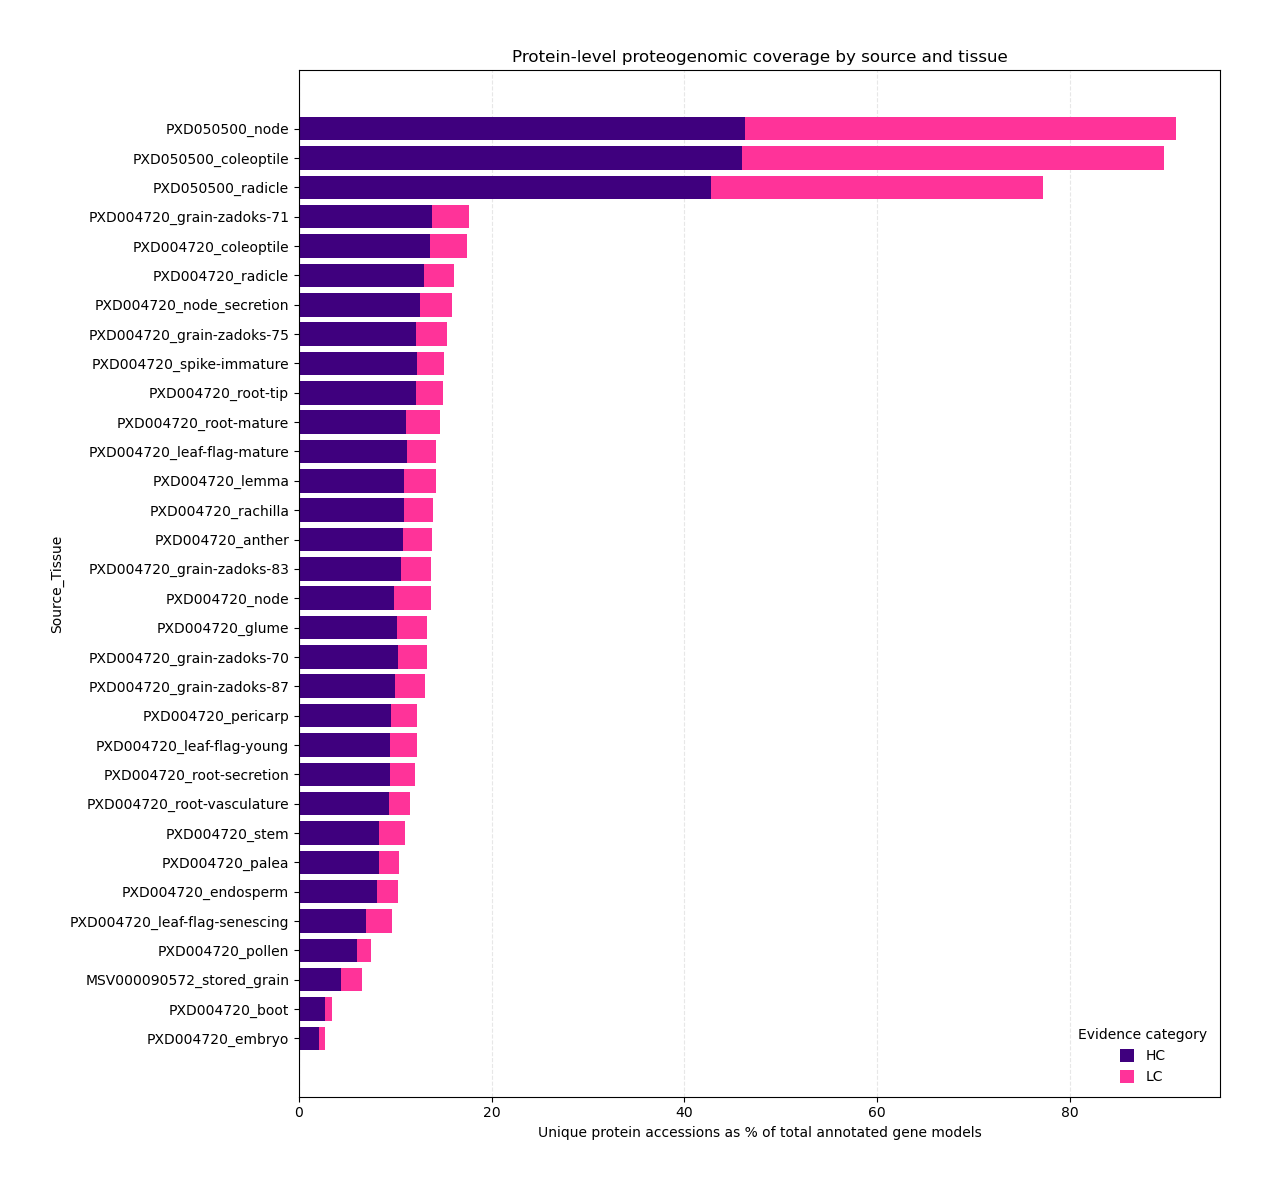

Figure saved: python_outputs\figures\step15_source_tissue_protein_coverage_HC_LC.png


,Source,Tissue,Source_Tissue,HC_unique_proteins,LC_unique_proteins,HC_unique_peptides,LC_unique_peptides,HC_protein_percent,LC_protein_percent,Total_protein_percent
7,PXD004720,embryo,PXD004720_embryo,5544,1676,2166,914,2.078335,0.628299,2.706634
5,PXD004720,boot,PXD004720_boot,7224,1984,2881,1050,2.708133,0.743762,3.451895
0,MSV000090572,stored_grain,MSV000090572_stored_grain,11648,5830,6395,3580,4.366603,2.185551,6.552153
23,PXD004720,pollen,PXD004720_pollen,15984,3947,12494,2799,5.992083,1.479652,7.471734
16,PXD004720,leaf-flag-senescing,PXD004720_leaf-flag-senescing,18655,7041,8807,3707,6.993387,2.639530,9.632917
8,PXD004720,endosperm,PXD004720_endosperm,21535,5919,18150,4153,8.073042,2.218915,10.291957
21,PXD004720,palea,PXD004720_palea,22119,5461,20187,4039,8.291972,2.047220,10.339191
31,PXD004720,stem,PXD004720_stem,22217,7193,11574,4207,8.328710,2.696512,11.025222
29,PXD004720,root-vasculature,PXD004720_root-vasculature,24900,5726,19182,3879,9.334513,2.146563,11.481076
27,PXD004720,root-secretion,PXD004720_root-secretion,25118,6928,18206,5146,9.416237,2.597169,12.013406


In [10]:
# ============================================================
# Step 15 — EDA: HC/LC coverage by tissue
# Memory-safe version: does not load long BED/peptide label columns
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1. Paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"
protein_gene_mapping_file = tables_dir / "wheat_protein_gene_mapping_HC_LC.csv"

protein_plot_out = figures_dir / "step15_source_tissue_protein_coverage_HC_LC.png"
gene_model_plot_out = figures_dir / "step15_source_tissue_gene_model_coverage_HC_LC.png"
step15_summary_out = tables_dir / "wheat_eda_coverage_HC_LC_step15.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")
protein_gene_mapping = pd.read_csv(protein_gene_mapping_file, low_memory=False)

# -----------------------------
# 2. Brand colours
# -----------------------------
brand_colours = {
    "HC": "#3F007E",
    "LC": "#FF3399",
    "background": "#E6CDFF"
}

# -----------------------------
# 3. Annotation denominator
# -----------------------------
gene_col = "GeneModel" if "GeneModel" in protein_gene_mapping.columns else "GeneID"
confidence_col = "Annotation_confidence"

total_gene_models = protein_gene_mapping[gene_col].nunique()

print(f"Total annotated gene models used as denominator: {total_gene_models:,}")

# -----------------------------
# 4. Load projected peptide tables from Step 9
# Only load columns required for this EDA step
# -----------------------------
projected_tables = []

projection_usecols = [
    "Projection_status",
    "ProteinID",
    "Peptide",
    confidence_col
]

for _, row in manifest.iterrows():

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Warning: missing projection file, skipped: {projection_path}")
        continue

    data = pd.read_csv(
        projection_path,
        usecols=lambda col: col in projection_usecols,
        low_memory=False
    )

    data = data[data["Projection_status"] == "projected"].copy()

    data["Source"] = row["Source"]
    data["Species"] = row["Species"]
    data["Tissue"] = row["Tissue-Raw-Code"]
    data["Source_Tissue"] = (
        data["Source"].astype(str) + "_" + data["Tissue"].astype(str)
    )

    projected_tables.append(data)

if not projected_tables:
    raise ValueError("No projected peptide tables were loaded. Please check Step 9 outputs.")

projected_all = pd.concat(projected_tables, ignore_index=True)

print(f"Projected rows loaded for Step 15: {len(projected_all):,}")

# -----------------------------
# 5. Annotation-projected HC/LC metrics
# -----------------------------
records = []

for (source, tissue, source_tissue), group in projected_all.groupby(
    ["Source", "Tissue", "Source_Tissue"],
    dropna=False
):

    hc = group[group[confidence_col].astype(str).str.upper() == "HC"]
    lc = group[group[confidence_col].astype(str).str.upper() == "LC"]

    records.append({
        "Source": source,
        "Tissue": tissue,
        "Source_Tissue": source_tissue,
        "HC_unique_proteins": hc["ProteinID"].nunique(),
        "LC_unique_proteins": lc["ProteinID"].nunique(),
        "HC_unique_peptides": hc["Peptide"].nunique(),
        "LC_unique_peptides": lc["Peptide"].nunique()
    })

coverage = pd.DataFrame(records)

# Ensure all manifest tissues are present
all_tissues = manifest[["Source", "Tissue-Raw-Code"]].copy()
all_tissues = all_tissues.rename(columns={"Tissue-Raw-Code": "Tissue"})
all_tissues["Source_Tissue"] = (
    all_tissues["Source"].astype(str) + "_" + all_tissues["Tissue"].astype(str)
)

coverage = all_tissues.merge(
    coverage,
    on=["Source", "Tissue", "Source_Tissue"],
    how="left"
).fillna(0)


# -----------------------------
# 6. Convert counts to percentage of total annotated gene models
# -----------------------------

# Total annotated gene models from Step 5
# (266,752 unique mapped gene models)
# total_gene_models = 266752

# Protein-level coverage percentages
coverage["HC_protein_percent"] = (
    coverage["HC_unique_proteins"] / total_gene_models
) * 100

coverage["LC_protein_percent"] = (
    coverage["LC_unique_proteins"] / total_gene_models
) * 100

# Total protein coverage
coverage["Total_protein_percent"] = (
    coverage["HC_protein_percent"] +
    coverage["LC_protein_percent"]
)

# -----------------------------
# Remove peptide percentage columns
# (biologically misleading and can exceed 100%)
# -----------------------------
cols_to_remove = [
    "HC_peptide_percent",
    "LC_peptide_percent",
    "Total_peptide_percent"
]

coverage = coverage.drop(
    columns=[c for c in cols_to_remove if c in coverage.columns],
    errors="ignore"
)

# -----------------------------
# Sort and export
# -----------------------------
coverage = coverage.sort_values(
    "Total_protein_percent",
    ascending=True
)

coverage.to_csv(step15_summary_out, index=False)

print(f"Saved corrected Step 15 summary: {step15_summary_out}")

display(coverage.head())

# -----------------------------
# 8. Plotting helper
# -----------------------------
def plot_stacked_horizontal_bar(data, value_cols, labels, title, xlabel, output_path):

    plot_data = data.copy()
    y = plot_data["Source_Tissue"]

    fig_height = max(8, len(plot_data) * 0.35)

    fig, ax = plt.subplots(figsize=(12, fig_height))

    left = pd.Series([0] * len(plot_data), index=plot_data.index)

    for col, label in zip(value_cols, labels):
        ax.barh(
            y,
            plot_data[col],
            left=left,
            label=label,
            color=brand_colours[label]
        )
        left = left + plot_data[col]

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Source_Tissue")
    ax.set_title(title)
    ax.legend(title="Evidence category", loc="lower right")

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Figure saved: {output_path}")

# -----------------------------
# 9. Protein-level plot
# -----------------------------
plot_stacked_horizontal_bar(
    data=coverage,
    value_cols=["HC_protein_percent", "LC_protein_percent"],
    labels=["HC", "LC"],
    title="Protein-level proteogenomic coverage by source and tissue",
    xlabel="Unique protein accessions as % of total annotated gene models",
    output_path=protein_plot_out
)

display(coverage)

# -----------------------------
# 10. Gene-model coverage plot
# -----------------------------
if (
    "HC_gene_model_percent" in coverage.columns and
    "LC_gene_model_percent" in coverage.columns
):

    coverage_gene_sorted = coverage.sort_values(
        "Total_gene_model_percent",
        ascending=True
    )

    plot_stacked_horizontal_bar(
        data=coverage_gene_sorted,
        value_cols=[
            "HC_gene_model_percent",
            "LC_gene_model_percent"
        ],
        labels=["HC", "LC"],
        title="Gene-model proteogenomic coverage by source and tissue",
        xlabel="Supported gene models as % of total annotated gene models",
        output_path=peptide_plot_out
    )

# Step 16 — EDA: Tissue Overlap Using UpSet Plots

This exploratory analysis investigates the overlap of proteogenomic evidence across wheat tissues using UpSet plots.

Because the study includes a large number of tissues and datasets, traditional Venn diagrams become impractical. UpSet plots provide a scalable alternative for visualising shared and tissue-specific proteogenomic features.

---

## Input files

### Peptide genome projection tables from Step 9

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only successfully projected peptide rows were included.

### Filtering rule

```text
Projection_status == "projected"
```

---

## Tissue grouping strategy

Each tissue was represented using a combined identifier:

```text
Source_Tissue
```

### Example

```text
PXD004720_anther
MSV000090572_stored_grain
```

This allows tissue-specific overlap analysis while preserving the origin of the proteomics dataset.

---

## Overlap categories analysed

Three independent UpSet analyses were performed:

| Analysis | Feature type |
|---|---|
| Protein overlap | Protein isoforms |
| Peptide overlap | Peptide sequences |
| Gene model overlap | Wheat gene models |

---

## UpSet plot interpretation

The UpSet plots visualise:

- tissue-specific features,
- shared features across tissues,
- and the frequency of different tissue-overlap combinations.

### Main components

| Component | Meaning |
|---|---|
| Horizontal bars | Total feature count per tissue |
| Vertical bars | Size of feature intersections |
| Connected dots | Tissue combinations contributing to each intersection |

---

## Figures generated

### Protein isoform overlap

```text
step16_upsetplot_tissue_overlap_proteins.png
```

### Peptide sequence overlap

```text
step16_upsetplot_tissue_overlap_peptides.png
```

### Gene model overlap

```text
step16_upsetplot_tissue_overlap_gene_models.png
```

---

## Output directory

```text
python_outputs/figures/
```

---

## Summary table

A Step 16 summary table was generated.

### Output file

```text
wheat_tissue_overlap_summary_step16.csv
```

### Metrics captured

| Metric | Description |
|---|---|
| Unique_projected_proteins | Number of unique projected protein isoforms |
| Unique_projected_peptides | Number of unique projected peptide sequences |
| Unique_projected_gene_models | Number of unique projected wheat gene models |

---

## Purpose

These analyses help identify:

- highly tissue-specific proteogenomic signatures,
- broadly shared wheat proteins and peptides,
- and tissues contributing the greatest diversity of proteogenomic evidence.

The UpSet plots also provide a global overview of tissue complementarity within the proteogenomics workflow.

Projected rows loaded: 8,291,056


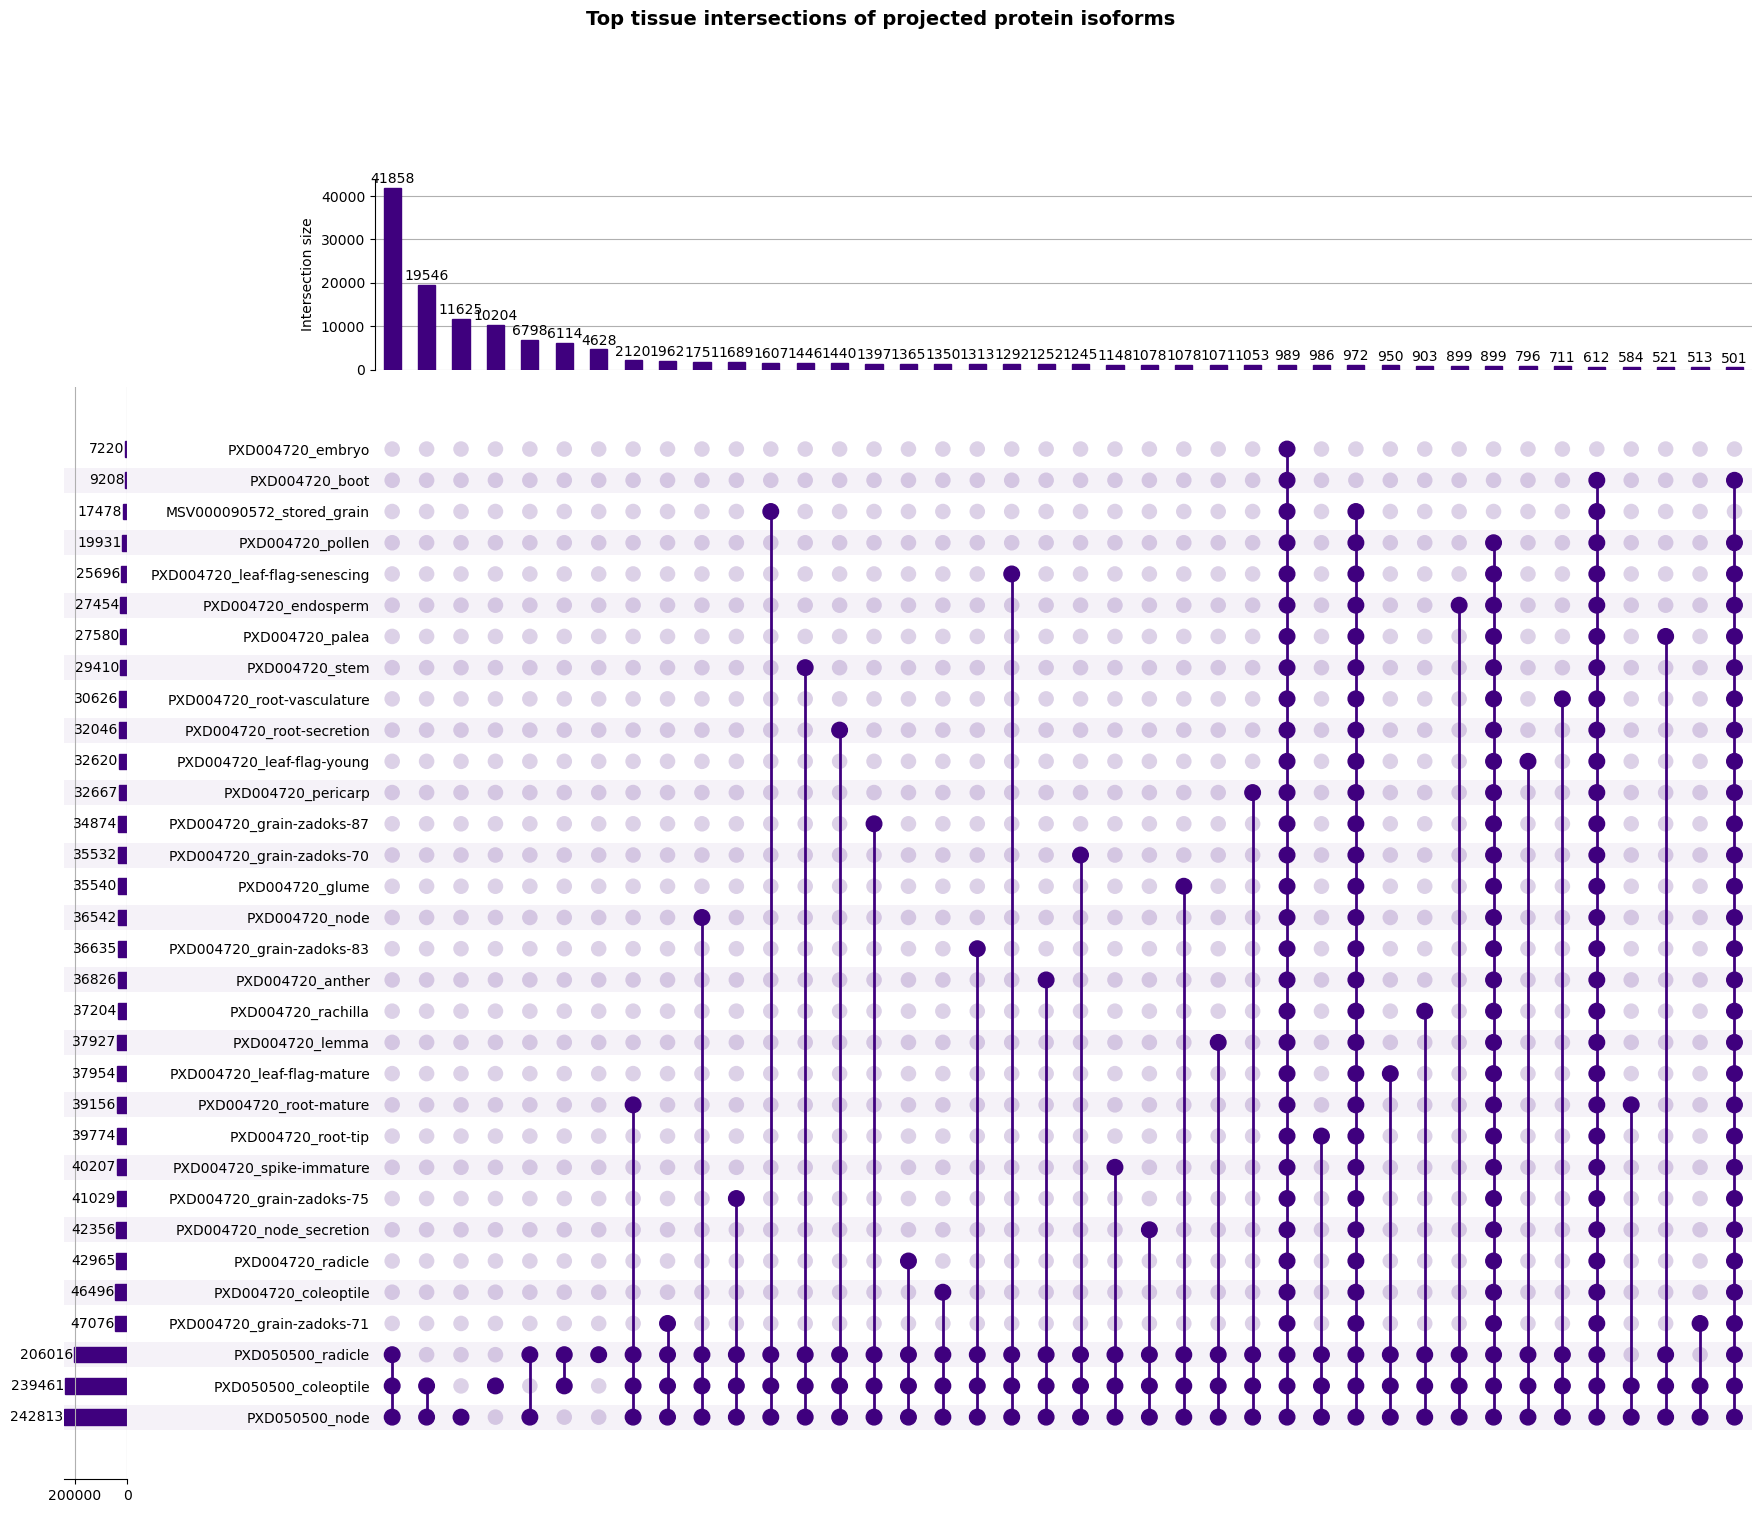

Figure saved: python_outputs\figures\step16_upsetplot_tissue_overlap_proteins.png


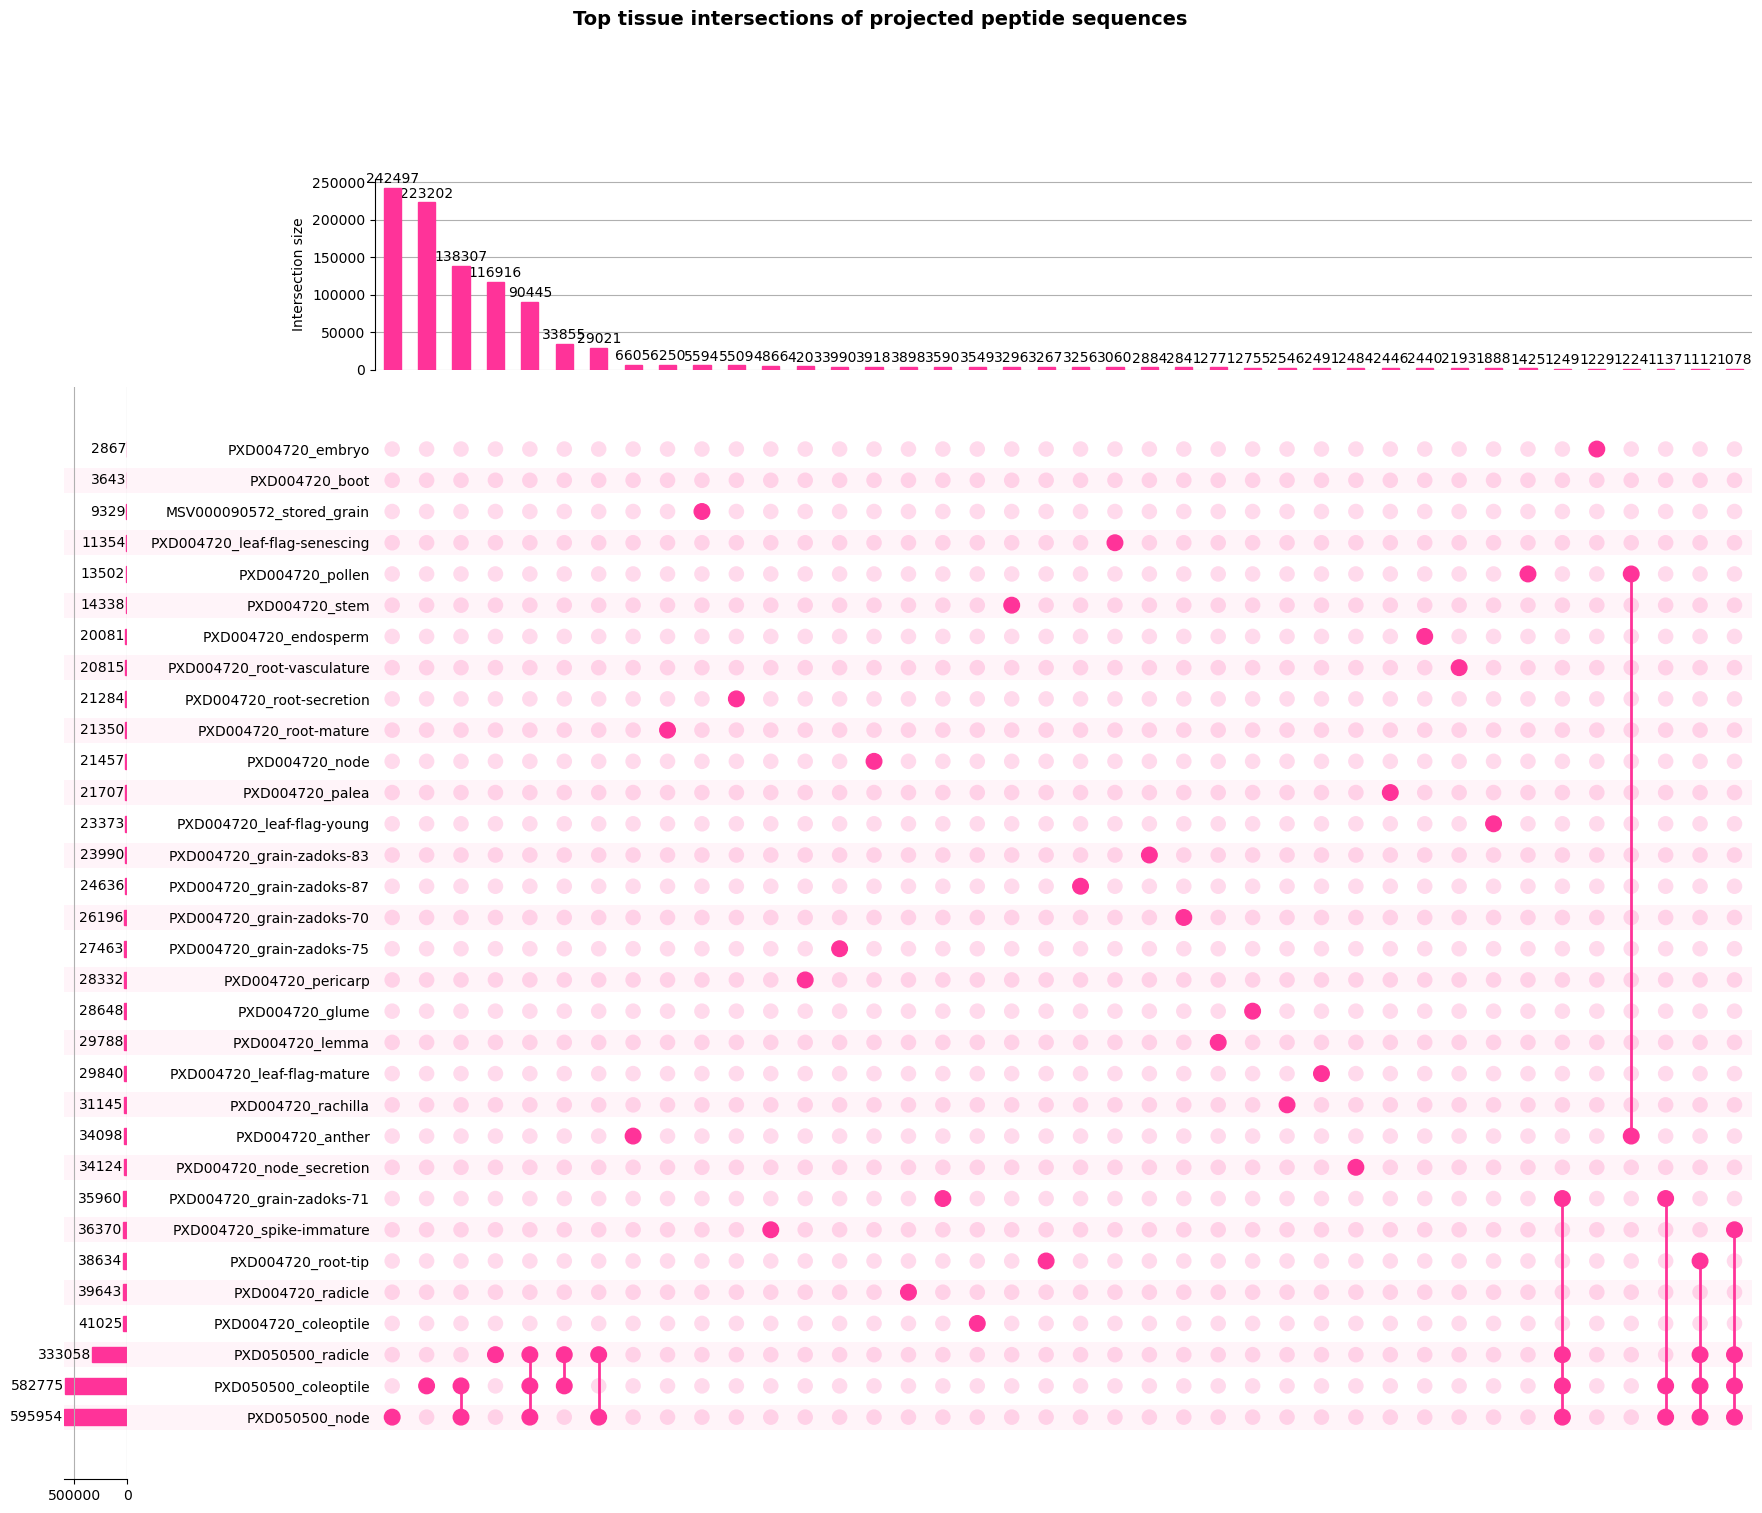

Figure saved: python_outputs\figures\step16_upsetplot_tissue_overlap_peptides.png


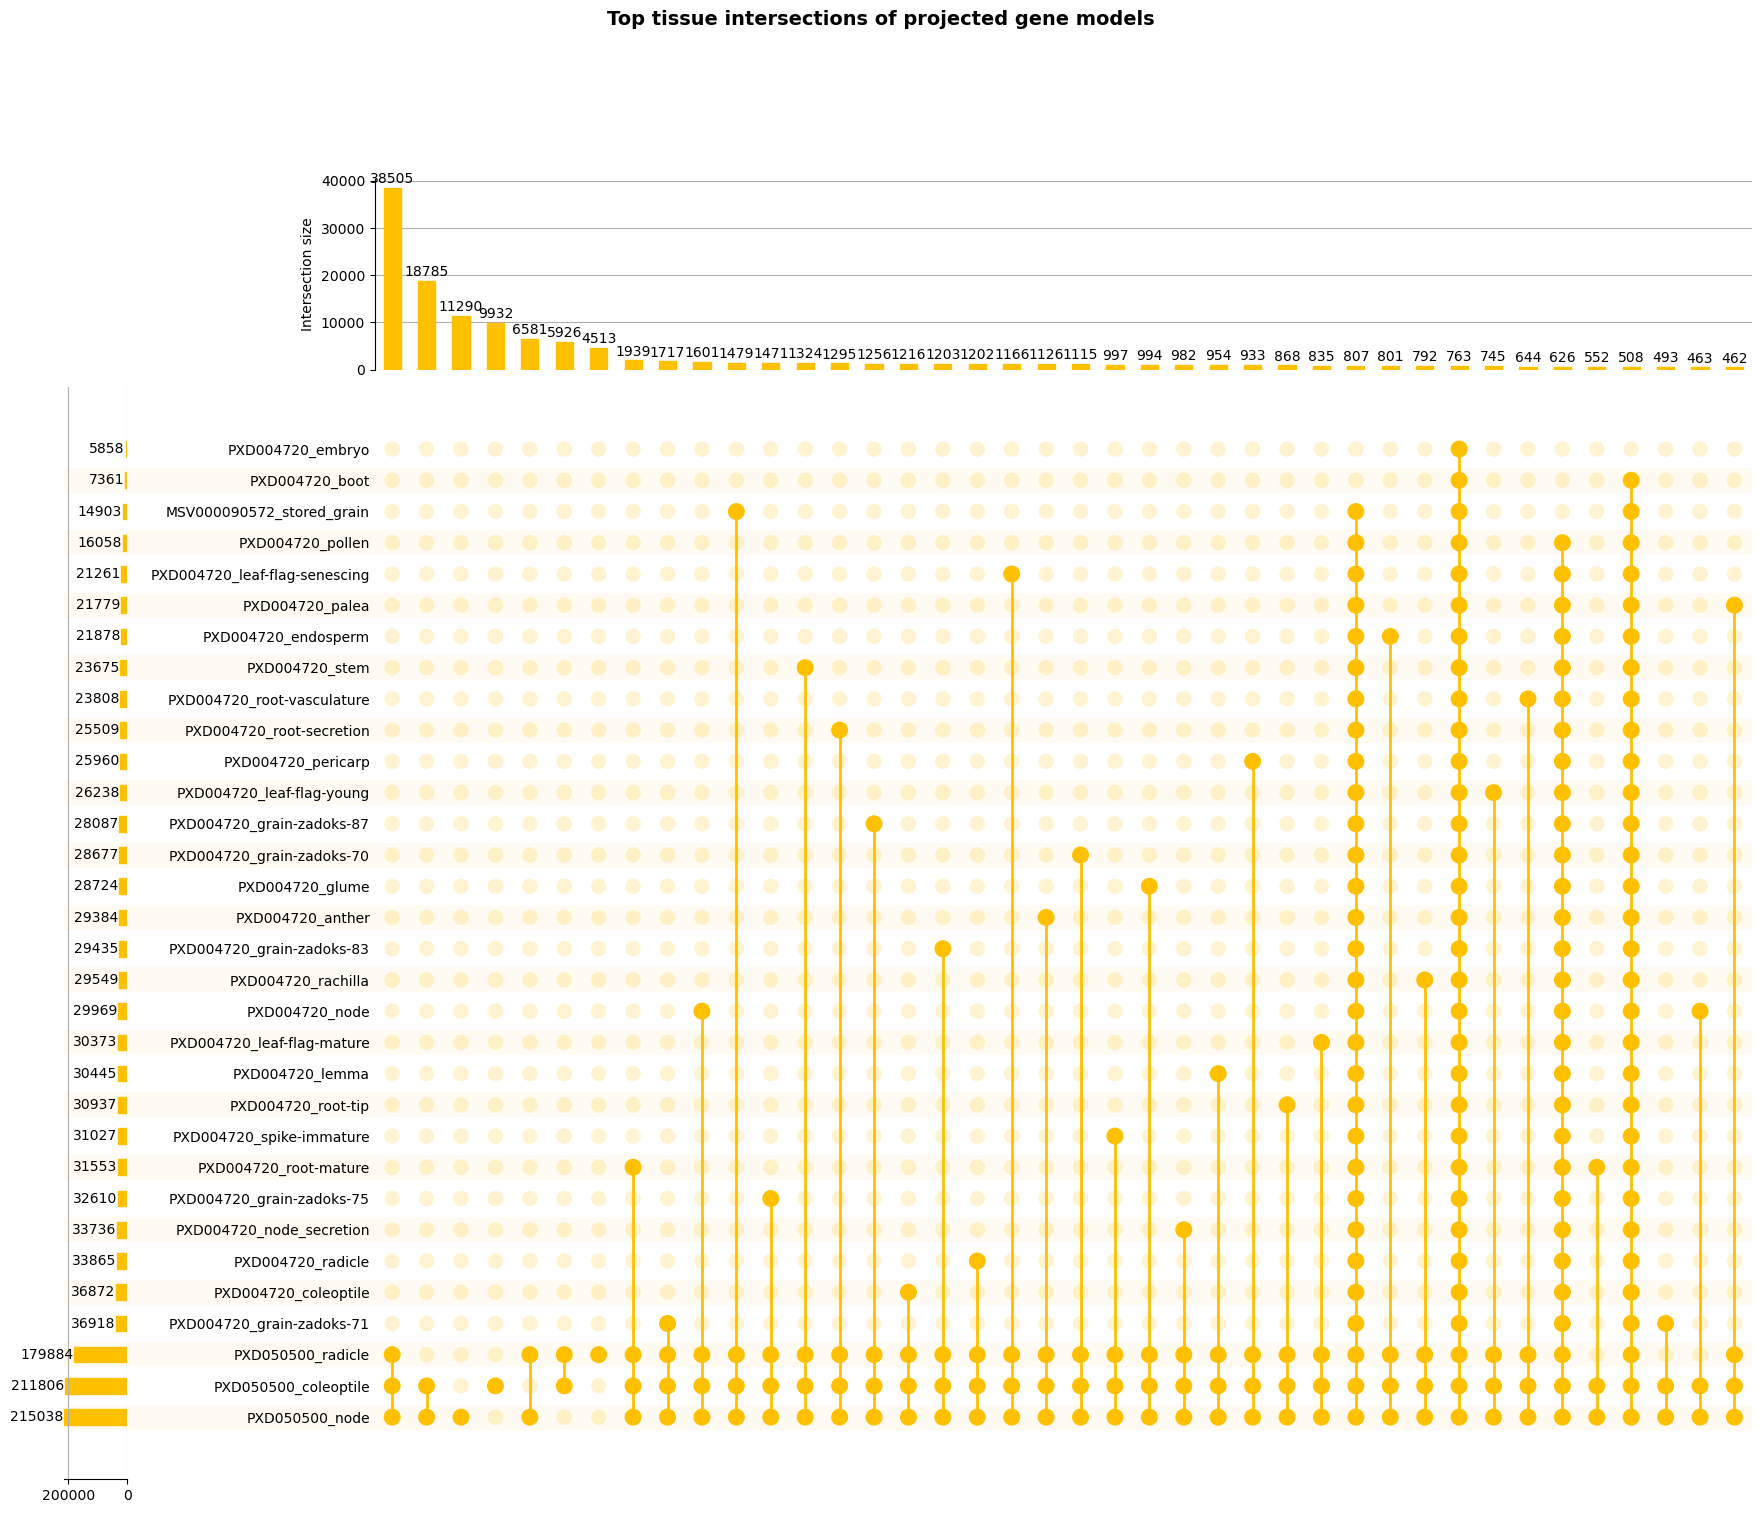

Figure saved: python_outputs\figures\step16_upsetplot_tissue_overlap_gene_models.png

Step 16 summary saved: python_outputs\tables\wheat_tissue_overlap_summary_step16.csv


,Source_Tissue,Unique_projected_proteins,Unique_projected_peptides,Unique_projected_gene_models
30,PXD050500_node,242813,595954,215038
29,PXD050500_coleoptile,239461,582775,211806
31,PXD050500_radicle,206016,333058,179884
8,PXD004720_grain-zadoks-71,47076,35960,36918
3,PXD004720_coleoptile,46496,41025,36872
22,PXD004720_radicle,42965,39643,33865
17,PXD004720_node_secretion,42356,34124,33736
9,PXD004720_grain-zadoks-75,41029,27463,32610
23,PXD004720_root-mature,39156,21350,31553
27,PXD004720_spike-immature,40207,36370,31027


In [10]:
# ============================================================
# Step 16 — EDA: Tissue overlap using UpSet plots
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from upsetplot import UpSet, from_contents
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

# -----------------------------
# 1. Paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")

figures_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

protein_upset_out = figures_dir / "step16_upsetplot_tissue_overlap_proteins.png"
peptide_upset_out = figures_dir / "step16_upsetplot_tissue_overlap_peptides.png"
gene_upset_out = figures_dir / "step16_upsetplot_tissue_overlap_gene_models.png"

step16_summary_out = tables_dir / "wheat_tissue_overlap_summary_step16.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")

# -----------------------------
# 2. Brand colours
# -----------------------------
brand_colours = {
    "dark_purple": "#3F007E",
    "pink": "#FF3399",
    "gold": "#FFC000",
    "lavender": "#E6CDFF"
}

# -----------------------------
# 3. Load projected peptide tables
# Memory-safe: only load columns required for Step 16
# -----------------------------
projected_tables = []

usecols_needed = [
    "Projection_status",
    "ProteinID",
    "Peptide",
    "GeneModel",
    "GeneID"
]

for _, row in manifest.iterrows():

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Warning: missing projection file, skipped: {projection_path}")
        continue

    data = pd.read_csv(
        projection_path,
        usecols=lambda col: col in usecols_needed,
        low_memory=False
    )

    data = data[data["Projection_status"] == "projected"].copy()

    data["Source"] = row["Source"]
    data["Species"] = row["Species"]
    data["Tissue"] = row["Tissue-Raw-Code"]
    data["Source_Tissue"] = (
        data["Source"].astype(str) + "_" +
        data["Tissue"].astype(str)
    )

    projected_tables.append(data)

projected_all = pd.concat(projected_tables, ignore_index=True)

print(f"Projected rows loaded: {len(projected_all):,}")

# -----------------------------
# 4. Build overlap dictionaries
# -----------------------------
gene_col = "GeneModel" if "GeneModel" in projected_all.columns else "GeneID"

protein_contents = {}
peptide_contents = {}
gene_contents = {}

for tissue, group in projected_all.groupby("Source_Tissue", dropna=False):

    protein_contents[tissue] = set(
        group["ProteinID"].dropna().astype(str)
    )

    peptide_contents[tissue] = set(
        group["Peptide"].dropna().astype(str)
    )

    gene_contents[tissue] = set(
        group[gene_col].dropna().astype(str)
    )

# -----------------------------
# 5. Create UpSet-compatible data
# -----------------------------
protein_upset_data = from_contents(protein_contents)
peptide_upset_data = from_contents(peptide_contents)
gene_upset_data = from_contents(gene_contents)

# -----------------------------
# 6. Plot helper function
# -----------------------------
def create_upset_plot(
    upset_data,
    title,
    output_path,
    facecolor,
    max_subset_rank=40,
    min_subset_size=50
):
    """
    Create a manageable UpSet plot by showing only the largest intersections.
    This avoids excessively large figures when many tissues are included.
    """

    fig = plt.figure(figsize=(16, 8))

    upset = UpSet(
        upset_data,
        subset_size="count",
        show_counts=True,
        sort_by="cardinality",
        facecolor=facecolor,
        min_subset_size=min_subset_size,
        max_subset_rank=max_subset_rank
    )

    upset.plot(fig=fig)

    plt.suptitle(title, fontsize=14, fontweight="bold")

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Figure saved: {output_path}")
    
# -----------------------------
# 7. Protein overlap UpSet plot
# -----------------------------
create_upset_plot(
    upset_data=protein_upset_data,
    title="Top tissue intersections of projected protein isoforms",
    output_path=protein_upset_out,
    facecolor=brand_colours["dark_purple"],
    max_subset_rank=40,
    min_subset_size=50
)

# -----------------------------
# 8. Peptide overlap UpSet plot
# -----------------------------
create_upset_plot(
    upset_data=peptide_upset_data,
    title="Top tissue intersections of projected peptide sequences",
    output_path=peptide_upset_out,
    facecolor=brand_colours["pink"],
    max_subset_rank=40,
    min_subset_size=50
)

# -----------------------------
# 9. Gene model overlap UpSet plot
# -----------------------------
create_upset_plot(
    upset_data=gene_upset_data,
    title="Top tissue intersections of projected gene models",
    output_path=gene_upset_out,
    facecolor=brand_colours["gold"],
    max_subset_rank=40,
    min_subset_size=50
)

# -----------------------------
# 10. Generate overlap summary table
# -----------------------------
summary_records = []

for tissue, group in projected_all.groupby("Source_Tissue", dropna=False):

    summary_records.append({
        "Source_Tissue": tissue,
        "Unique_projected_proteins": group["ProteinID"].nunique(),
        "Unique_projected_peptides": group["Peptide"].nunique(),
        "Unique_projected_gene_models": group[gene_col].nunique()
    })

step16_summary = pd.DataFrame(summary_records)

step16_summary = step16_summary.sort_values(
    "Unique_projected_gene_models",
    ascending=False
)

step16_summary.to_csv(step16_summary_out, index=False)

print(f"\nStep 16 summary saved: {step16_summary_out}")

display(step16_summary)

# Step 17 — EDA: Peptide Support per Gene Model

This exploratory analysis examines how many unique peptide sequences support each detected wheat gene model.

The aim is to evaluate the strength of proteomics evidence at the gene model level and compare peptide support between high-confidence (HC) and low-confidence (LC) annotations.

---

## Input file

### Gene model summary table from Step 13

```text
wheat_gene_model_summary_step13.csv
```

This table contains one row per detected gene model and includes the number of unique peptides, protein isoforms, tissues, and sources supporting each gene model.

---

## Analysis strategy

For each detected gene model, the number of unique supporting peptide sequences was extracted.

The analysis was stratified by annotation confidence:

```text
HC = high-confidence gene model
LC = low-confidence gene model
```

---

## Peptide support categories

Gene models were grouped into peptide-support classes:

| Category | Description |
|---|---|
| 1 peptide | Gene model supported by one unique peptide |
| 2–4 peptides | Gene model supported by two to four unique peptides |
| 5–9 peptides | Gene model supported by five to nine unique peptides |
| ≥10 peptides | Gene model supported by ten or more unique peptides |

---

## Figures generated

### 1. Histogram of peptide support per gene model

```text
step17_peptide_support_per_gene_model_histogram.png
```

This plot shows the distribution of unique peptide counts per gene model. A log-scaled x-axis was used because most gene models are expected to be supported by relatively few peptides, while a smaller number may be supported by many peptides.

### 2. HC vs LC boxplot

```text
step17_peptide_support_per_gene_model_HC_LC_boxplot.png
```

This plot compares peptide support between HC and LC gene models. The y-axis was log-scaled to improve visualisation of both low- and high-support gene models.

---

## Summary table

A Step 17 summary table was generated.

### Output file

```text
wheat_peptide_support_per_gene_model_summary_step17.csv
```

### Metrics captured

| Metric | Description |
|---|---|
| Gene_model_count | Number of gene models in each peptide-support category |
| Median_unique_peptides | Median number of unique peptides per gene model |
| Mean_unique_peptides | Mean number of unique peptides per gene model |
| Max_unique_peptides | Maximum number of unique peptides observed |
| Total_gene_models_with_peptide_support | Total detected gene models within each annotation class |
| Percent_within_confidence_class | Percentage of detected HC or LC gene models in each support category |

---

## Purpose

This analysis provides an overview of the strength of peptide evidence supporting wheat gene model annotations.

It helps identify:

- gene models supported by minimal peptide evidence,
- gene models with strong multi-peptide support,
- differences in evidence strength between HC and LC annotations,
- and highly supported gene models that may represent abundant or broadly detected proteins.

Gene models with peptide support: 249,082


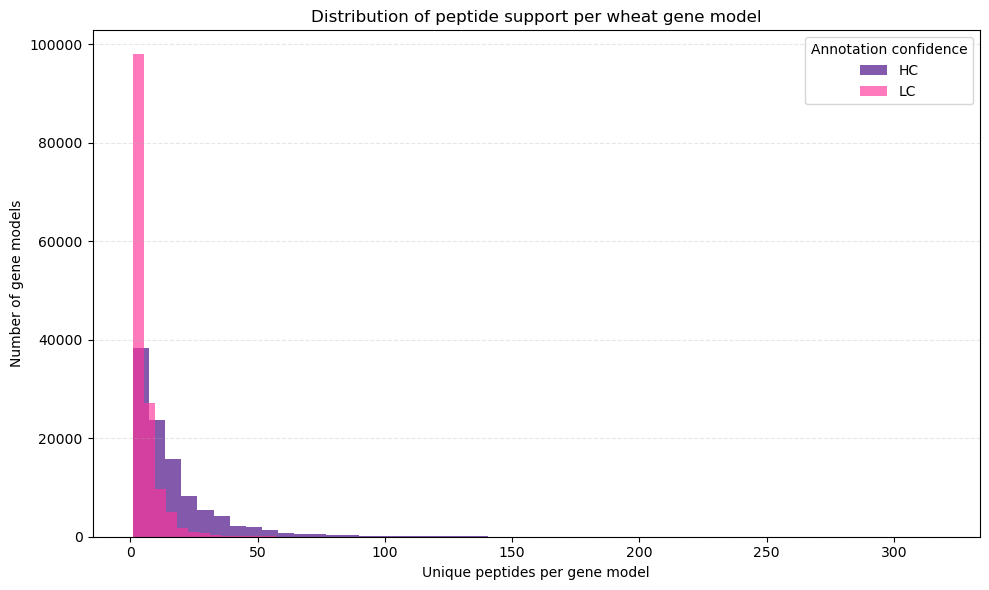

Histogram saved: python_outputs\figures\step17_peptide_support_per_gene_model_histogram.png


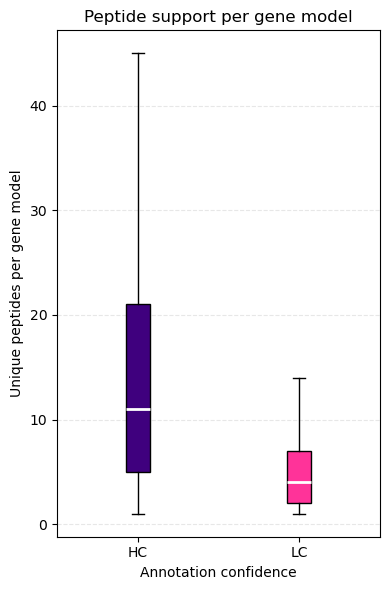

Boxplot saved: python_outputs\figures\step17_peptide_support_per_gene_model_HC_LC_boxplot.png
Step 17 summary saved: python_outputs\tables\wheat_peptide_support_per_gene_model_summary_step17.csv


,Annotation_confidence,Peptide_support_bin,Gene_model_count,Median_unique_peptides,Mean_unique_peptides,Max_unique_peptides,Total_gene_models_with_peptide_support,Percent_within_confidence_class
0,HC,1 peptide,4088,1.0,1.000000,1,104576,3.9091
1,HC,2–4 peptides,17236,3.0,3.038698,4,104576,16.4818
2,HC,5–9 peptides,26541,7.0,6.868430,9,104576,25.3796
3,HC,≥10 peptides,56711,20.0,26.219622,318,104576,54.2295
4,LC,1 peptide,23596,1.0,1.000000,1,144506,16.3287
5,LC,2–4 peptides,61744,3.0,2.870400,4,144506,42.7276
6,LC,5–9 peptides,39752,6.0,6.490466,9,144506,27.5089
7,LC,≥10 peptides,19414,13.0,16.487792,217,144506,13.4347


In [13]:
# ============================================================
# Step 17 — EDA: Peptide support per gene model
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1. Paths
# -----------------------------
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

gene_summary_file = tables_dir / "wheat_gene_model_summary_step13.csv"

histogram_out = figures_dir / "step17_peptide_support_per_gene_model_histogram.png"
boxplot_out = figures_dir / "step17_peptide_support_per_gene_model_HC_LC_boxplot.png"
step17_summary_out = tables_dir / "wheat_peptide_support_per_gene_model_summary_step17.csv"

# -----------------------------
# 2. Brand colours
# -----------------------------
brand_colours = {
    "HC": "#3F007E",      # dark purple
    "LC": "#FF3399",      # pink
    "gold": "#FFC000",
    "lavender": "#E6CDFF"
}

# -----------------------------
# 3. Load gene model summary
# -----------------------------
gene_summary = pd.read_csv(gene_summary_file, low_memory=False)

gene_col = "GeneModel" if "GeneModel" in gene_summary.columns else "GeneID"
confidence_col = "Annotation_confidence"

required_cols = [gene_col, confidence_col, "Unique_peptides"]
missing_cols = [col for col in required_cols if col not in gene_summary.columns]

if missing_cols:
    raise KeyError(f"Missing required column(s): {missing_cols}")

gene_summary["Unique_peptides"] = pd.to_numeric(
    gene_summary["Unique_peptides"],
    errors="coerce"
).fillna(0)

gene_summary = gene_summary[gene_summary["Unique_peptides"] > 0].copy()

gene_summary[confidence_col] = gene_summary[confidence_col].astype(str).str.upper()

print(f"Gene models with peptide support: {gene_summary[gene_col].nunique():,}")

# -----------------------------
# 4. Peptide support bins
# -----------------------------
def peptide_support_bin(value):
    if value == 1:
        return "1 peptide"
    elif 2 <= value <= 4:
        return "2–4 peptides"
    elif 5 <= value <= 9:
        return "5–9 peptides"
    else:
        return "≥10 peptides"

gene_summary["Peptide_support_bin"] = gene_summary["Unique_peptides"].apply(peptide_support_bin)

# -----------------------------
# 5. Summary table
# -----------------------------
step17_summary = (
    gene_summary
    .groupby([confidence_col, "Peptide_support_bin"], dropna=False)
    .agg(
        Gene_model_count=(gene_col, "nunique"),
        Median_unique_peptides=("Unique_peptides", "median"),
        Mean_unique_peptides=("Unique_peptides", "mean"),
        Max_unique_peptides=("Unique_peptides", "max")
    )
    .reset_index()
)

total_by_confidence = (
    gene_summary
    .groupby(confidence_col)[gene_col]
    .nunique()
    .reset_index(name="Total_gene_models_with_peptide_support")
)

step17_summary = step17_summary.merge(
    total_by_confidence,
    on=confidence_col,
    how="left"
)

step17_summary["Percent_within_confidence_class"] = (
    step17_summary["Gene_model_count"] /
    step17_summary["Total_gene_models_with_peptide_support"] *
    100
).round(4)

bin_order = ["1 peptide", "2–4 peptides", "5–9 peptides", "≥10 peptides"]
step17_summary["Peptide_support_bin"] = pd.Categorical(
    step17_summary["Peptide_support_bin"],
    categories=bin_order,
    ordered=True
)

step17_summary = step17_summary.sort_values(
    [confidence_col, "Peptide_support_bin"]
)

step17_summary.to_csv(step17_summary_out, index=False)

# -----------------------------
# 6. Histogram: unique peptide support per gene model
# -----------------------------
plt.figure(figsize=(10, 6))

for confidence, colour in [("HC", brand_colours["HC"]), ("LC", brand_colours["LC"])]:

    subset = gene_summary[
        gene_summary[confidence_col] == confidence
    ]

    if len(subset) > 0:

        plt.hist(
            subset["Unique_peptides"],
            bins=50,
            alpha=0.65,
            label=confidence,
            color=colour
        )

plt.xlabel("Unique peptides per gene model")
plt.ylabel("Number of gene models")
plt.title("Distribution of peptide support per wheat gene model")

plt.legend(title="Annotation confidence")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    histogram_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Histogram saved: {histogram_out}")

# -----------------------------
# 7. HC vs LC boxplot
# -----------------------------
hc_values = gene_summary.loc[
    gene_summary[confidence_col] == "HC",
    "Unique_peptides"
]

lc_values = gene_summary.loc[
    gene_summary[confidence_col] == "LC",
    "Unique_peptides"
]

plt.figure(figsize=(4, 6))

box = plt.boxplot(
    [hc_values, lc_values],
    tick_labels=["HC", "LC"],   # updated Matplotlib syntax
    patch_artist=True,
    showfliers=False
)

box["boxes"][0].set_facecolor(brand_colours["HC"])
box["boxes"][1].set_facecolor(brand_colours["LC"])

for median in box["medians"]:
    median.set_color("white")
    median.set_linewidth(2)

plt.ylabel("Unique peptides per gene model")
plt.xlabel("Annotation confidence")

plt.title("Peptide support per gene model")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    boxplot_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Boxplot saved: {boxplot_out}")

# -----------------------------
# 8. Display summary
# -----------------------------
print(f"Step 17 summary saved: {step17_summary_out}")
display(step17_summary)

# Step 18 — EDA: Peptide Length, Probability, and Charge by Annotation Confidence

This exploratory analysis compares peptide-level identification characteristics between high-confidence (HC) and low-confidence (LC) wheat gene model annotations.

A scatterplot was generated to visualise the relationship between peptide length and peptide identification probability, with charge state represented by point size.

---

## Input files

### Peptide genome projection tables from Step 9

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only successfully projected peptide rows were included.

### Filtering rule

```text
Projection_status == "projected"
```

---

## Plot design

| Visual element | Variable |
|---|---|
| x-axis | Peptide length in amino acids |
| y-axis | Peptide probability |
| Point colour | Annotation confidence: HC or LC |
| Point size | Peptide charge state |

---

## Charge handling

FragPipe may report one or multiple charge states for a peptide.

When multiple charge states were present, the maximum reported charge state was used for point size representation.

---

## Downsampling

Because the full projected peptide table contains millions of rows, a random sample was used for plotting to improve readability and computational performance.

The summary statistics were calculated from the full dataset.

---

## Output files

### Figure

```text
step18_peptide_length_probability_charge_HC_LC_scatter.png
```

### Summary table

```text
wheat_peptide_length_charge_probability_summary_step18.csv
```

---

## Purpose

This plot helps assess whether peptides supporting HC and LC annotations differ in:

- peptide length,
- identification probability,
- charge state distribution,
- or overall peptide evidence quality.

Sampling from: FragPipe_Vincent_MSV000090572_stored-grain_peptide_genome_projection.csv
Sampling from: FragPipe_Liu_PXD050500_coleoptile_peptide_genome_projection.csv
Sampling from: FragPipe_Liu_PXD050500_node_peptide_genome_projection.csv
Sampling from: FragPipe_Liu_PXD050500_radicle_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_anther_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_boot_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_coleoptile_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_embryo_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_endosperm_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_glume_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_grain-zadoks-70_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD004720_grain-zadoks-71_peptide_genome_projection.csv
Sampling from: FragPipe_Duncan_PXD0047

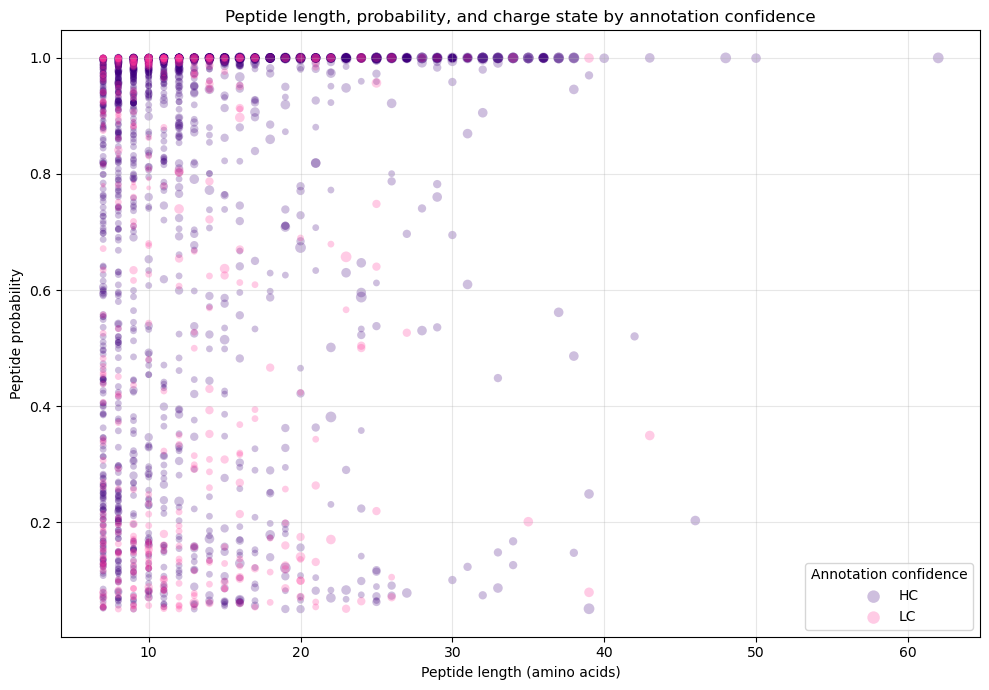

Scatterplot saved: python_outputs\figures\step18_peptide_length_probability_charge_HC_LC_scatter.png
Step 18 summary saved: python_outputs\tables\wheat_peptide_length_charge_probability_summary_step18.csv


,Annotation_confidence,Sampled_peptide_rows,Unique_peptides,Mean_peptide_length,Median_peptide_length,Mean_probability,Median_probability,Mean_charge,Median_charge
0,HC,3064,2891,13.698433,12.0,0.855652,0.9989,2.458551,2.0
1,LC,422,408,12.457346,11.0,0.586741,0.6620,2.319905,2.0


In [14]:
# ============================================================
# Step 18 — EDA: Peptide length, probability, and charge by HC/LC
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# -----------------------------
# 1. Paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

step18_summary_out = tables_dir / "wheat_peptide_length_charge_probability_summary_step18.csv"
scatter_out = figures_dir / "step18_peptide_length_probability_charge_HC_LC_scatter.png"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")

# -----------------------------
# 2. Brand colours
# -----------------------------
brand_colours = {
    "HC": "#3F007E",
    "LC": "#FF3399",
    "gold": "#FFC000",
    "lavender": "#E6CDFF"
}

# -----------------------------
# 3. Helper function
# -----------------------------
def parse_charge(value):
    """
    Convert FragPipe charge values into one numeric value.
    Handles values such as:
    2
    2,3
    2;3
    2|3
    """
    if pd.isna(value):
        return pd.NA

    values = re.findall(r"\d+", str(value))

    if len(values) == 0:
        return pd.NA

    # Use maximum observed charge state when multiple are reported
    return max(int(v) for v in values)

# -----------------------------
# 4. Load a small random sample from projected peptide tables
# -----------------------------
all_sampled_tables = []

max_points_total = 10000
n_files = len(manifest)
sample_per_file = max(200, max_points_total // n_files)

needed_cols = [
    "Projection_status",
    "Peptide",
    "Peptide_length_AA",
    "Probability",
    "Charges",
    "Annotation_confidence"
]

chunksize = 100_000

for _, row in manifest.iterrows():

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Warning: missing file, skipped: {projection_path}")
        continue

    print(f"Sampling from: {projection_filename}")

    file_samples = []

    for chunk in pd.read_csv(
        projection_path,
        usecols=lambda col: col in needed_cols,
        chunksize=chunksize,
        low_memory=False
    ):

        chunk = chunk[
            (chunk["Projection_status"] == "projected") &
            (chunk["Annotation_confidence"].isin(["HC", "LC"]))
        ]

        if chunk.empty:
            continue

        n_sample = min(50, len(chunk))

        file_samples.append(
            chunk.sample(
                n=n_sample,
                random_state=42
            )
        )

    if len(file_samples) == 0:
        continue

    file_sample = pd.concat(file_samples, ignore_index=True)

    if len(file_sample) > sample_per_file:
        file_sample = file_sample.sample(
            n=sample_per_file,
            random_state=42
        )

    all_sampled_tables.append(file_sample)

plot_data = pd.concat(all_sampled_tables, ignore_index=True)

if len(plot_data) > max_points_total:
    plot_data = plot_data.sample(
        n=max_points_total,
        random_state=42
    ).copy()

print(f"Rows used for scatterplot: {len(plot_data):,}")

# -----------------------------
# 5. Prepare plotting variables
# -----------------------------
confidence_col = "Annotation_confidence"

if "Peptide_length_AA" not in plot_data.columns:
    plot_data["Peptide_length_AA"] = plot_data["Peptide"].astype(str).str.len()

plot_data["Probability"] = pd.to_numeric(
    plot_data["Probability"],
    errors="coerce"
)

plot_data["Charge_numeric"] = plot_data["Charges"].apply(parse_charge)

plot_data = plot_data.dropna(
    subset=["Peptide_length_AA", "Probability", "Charge_numeric"]
).copy()

plot_data["Dot_size"] = plot_data["Charge_numeric"] * 12

# -----------------------------
# 6. Summary table
# -----------------------------
# randomly sampled dataset (memory friendly)
step18_summary = (
    plot_data
    .groupby(confidence_col, dropna=False)
    .agg(
        Sampled_peptide_rows=("Peptide", "size"),
        Unique_peptides=("Peptide", "nunique"),
        Mean_peptide_length=("Peptide_length_AA", "mean"),
        Median_peptide_length=("Peptide_length_AA", "median"),
        Mean_probability=("Probability", "mean"),
        Median_probability=("Probability", "median"),
        Mean_charge=("Charge_numeric", "mean"),
        Median_charge=("Charge_numeric", "median")
    )
    .reset_index()
)

step18_summary.to_csv(step18_summary_out, index=False)

# -----------------------------
# 7. Scatterplot
# -----------------------------
plt.figure(figsize=(10, 7))

for confidence in ["HC", "LC"]:

    subset = plot_data[plot_data[confidence_col] == confidence]

    plt.scatter(
        subset["Peptide_length_AA"],
        subset["Probability"],
        s=subset["Dot_size"],
        alpha=0.25,
        color=brand_colours[confidence],
        label=confidence,
        edgecolors="none"
    )

plt.xlabel("Peptide length (amino acids)")
plt.ylabel("Peptide probability")
plt.title("Peptide length, probability, and charge state by annotation confidence")

plt.legend(
    title="Annotation confidence",
    markerscale=1.5
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    scatter_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Scatterplot saved: {scatter_out}")
print(f"Step 18 summary saved: {step18_summary_out}")

display(step18_summary)

# Step 19 — EDA: Protein Length versus Peptide Support

This exploratory analysis investigates the relationship between protein length and peptide support across wheat protein isoforms.

The aim is to determine whether longer proteins tend to accumulate greater peptide evidence and whether this relationship differs between high-confidence (HC) and low-confidence (LC) annotations.

---

## Input files

### Protein isoform summary table from Step 13

```text
wheat_protein_isoform_summary_step13.csv
```

### Protein-to-gene mapping table from Step 5

```text
wheat_protein_gene_mapping_HC_LC.csv
```

---

## Plot design

| Visual element | Variable |
|---|---|
| x-axis | Protein length derived from CDS annotation |
| y-axis | Number of unique supporting peptides |
| Point colour | Annotation confidence (HC or LC) |

---

## Variables used

### Protein length

```text
Protein_length_aa_from_CDS
```

Protein length corresponds to the amino acid length inferred from CDS annotations in the wheat genome annotation.

### Peptide support

```text
Unique_peptides
```

This corresponds to the number of unique peptide sequences supporting each protein isoform.

---

## Figure generated

```text
step19_protein_length_vs_peptide_support_scatter.png
```

---

## Summary table

A Step 22 summary table was generated.

### Output file

```text
wheat_protein_length_vs_peptide_support_summary_step19.csv
```

### Metrics captured

| Metric | Description |
|---|---|
| Protein_isoforms | Number of detected protein isoforms |
| Mean_protein_length_aa | Mean protein length |
| Median_protein_length_aa | Median protein length |
| Max_protein_length_aa | Maximum protein length |
| Mean_unique_peptides | Mean number of unique peptides |
| Median_unique_peptides | Median number of unique peptides |
| Max_unique_peptides | Maximum number of unique peptides observed |

---

## Purpose

This analysis helps evaluate whether peptide support scales with protein length and whether HC and LC annotations display different peptide-support characteristics.

The plot also highlights highly supported protein isoforms and potential outliers within the wheat proteogenomics dataset.

Proteins plotted: 277,852


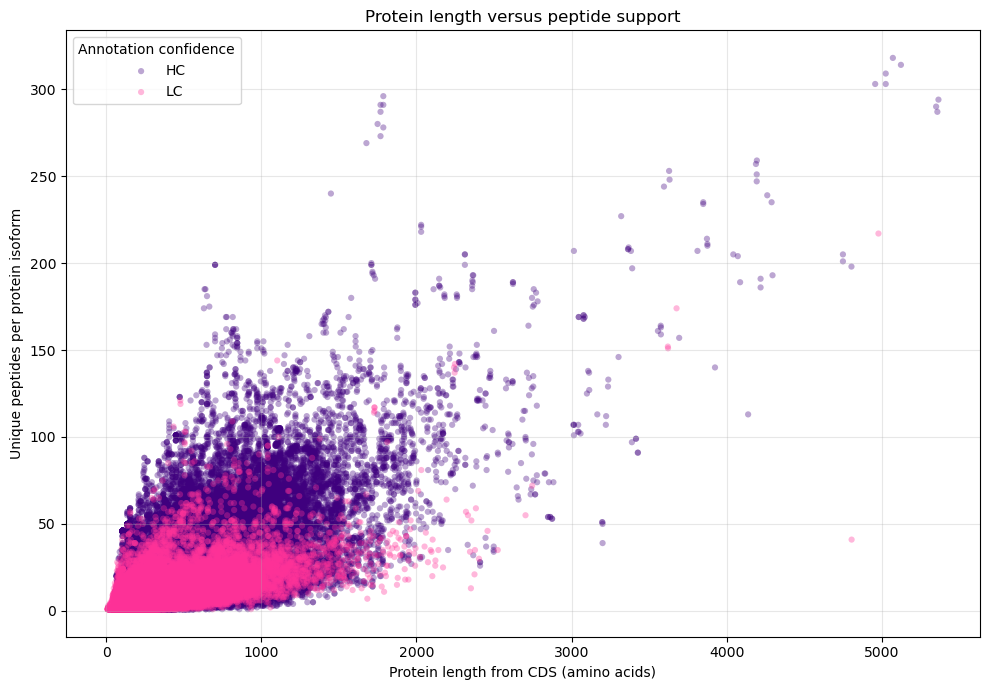

Scatterplot saved: python_outputs\figures\step19_protein_length_vs_peptide_support_scatter.png
Step 19 summary saved: python_outputs\tables\wheat_protein_length_vs_peptide_support_summary_step19.csv


,Annotation_confidence,Protein_isoforms,Mean_protein_length_aa,Median_protein_length_aa,Max_protein_length_aa,Mean_unique_peptides,Median_unique_peptides,Max_unique_peptides
0,HC,130182,450.447317,383.0,5366.0,18.652425,12.0,318
1,LC,147670,211.899793,158.0,4979.0,5.392280,4.0,217


In [15]:
# ============================================================
# Step 19 — EDA: Protein length vs peptide support
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1. Paths
# -----------------------------
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")

figures_dir.mkdir(parents=True, exist_ok=True)

protein_summary_file = tables_dir / "wheat_protein_isoform_summary_step13.csv"
protein_gene_mapping_file = tables_dir / "wheat_protein_gene_mapping_HC_LC.csv"

scatter_out = figures_dir / "step19_protein_length_vs_peptide_support_scatter.png"
step19_summary_out = tables_dir / "wheat_protein_length_vs_peptide_support_summary_step19.csv"

# -----------------------------
# 2. Brand colours
# -----------------------------
brand_colours = {
    "HC": "#3F007E",      # dark purple
    "LC": "#FF3399",      # pink
    "gold": "#FFC000",
    "lavender": "#E6CDFF"
}

# -----------------------------
# 3. Load tables
# -----------------------------
protein_summary = pd.read_csv(protein_summary_file, low_memory=False)
protein_mapping = pd.read_csv(protein_gene_mapping_file, low_memory=False)

# -----------------------------
# 4. Detect columns
# -----------------------------
protein_col = "ProteinID"

length_col = "Protein_length_aa_from_CDS"

if length_col not in protein_mapping.columns:
    raise KeyError(f"Could not find '{length_col}' in protein mapping table.")

if "Unique_peptides" not in protein_summary.columns:
    raise KeyError("Missing 'Unique_peptides' in protein summary table.")

# Use confidence from protein_summary if present, otherwise from mapping table
if "Annotation_confidence" in protein_summary.columns:
    confidence_col = "Annotation_confidence"
    protein_summary_clean = protein_summary.copy()

elif "Annotation_confidence" in protein_mapping.columns:
    confidence_col = "Annotation_confidence"

    protein_meta_conf = (
        protein_mapping[[protein_col, confidence_col]]
        .drop_duplicates(subset=[protein_col])
        .copy()
    )

    protein_summary_clean = protein_summary.merge(
        protein_meta_conf,
        on=protein_col,
        how="left"
    )

else:
    raise KeyError("Could not find 'Annotation_confidence' in either input table.")

# -----------------------------
# 5. Add protein length
# -----------------------------
protein_length_meta = (
    protein_mapping[[protein_col, length_col]]
    .drop_duplicates(subset=[protein_col])
    .copy()
)

plot_data = protein_summary_clean.merge(
    protein_length_meta,
    on=protein_col,
    how="left"
)

# -----------------------------
# 6. Clean variables
# -----------------------------
plot_data["Unique_peptides"] = pd.to_numeric(
    plot_data["Unique_peptides"],
    errors="coerce"
)

plot_data[length_col] = pd.to_numeric(
    plot_data[length_col],
    errors="coerce"
)

plot_data[confidence_col] = plot_data[confidence_col].astype(str).str.upper()

plot_data = plot_data.dropna(
    subset=["Unique_peptides", length_col, confidence_col]
)

plot_data = plot_data[
    plot_data[confidence_col].isin(["HC", "LC"])
].copy()

print(f"Proteins plotted: {len(plot_data):,}")

# -----------------------------
# 7. Summary table
# -----------------------------
step19_summary = (
    plot_data
    .groupby(confidence_col, dropna=False)
    .agg(
        Protein_isoforms=(protein_col, "nunique"),
        Mean_protein_length_aa=(length_col, "mean"),
        Median_protein_length_aa=(length_col, "median"),
        Max_protein_length_aa=(length_col, "max"),
        Mean_unique_peptides=("Unique_peptides", "mean"),
        Median_unique_peptides=("Unique_peptides", "median"),
        Max_unique_peptides=("Unique_peptides", "max")
    )
    .reset_index()
)

step19_summary.to_csv(step19_summary_out, index=False)

# -----------------------------
# 8. Scatterplot
# -----------------------------
plt.figure(figsize=(10, 7))

for confidence in ["HC", "LC"]:

    subset = plot_data[
        plot_data[confidence_col] == confidence
    ]

    plt.scatter(
        subset[length_col],
        subset["Unique_peptides"],
        alpha=0.35,
        s=20,
        color=brand_colours[confidence],
        label=confidence,
        edgecolors="none"
    )

plt.xlabel("Protein length from CDS (amino acids)")
plt.ylabel("Unique peptides per protein isoform")

plt.title("Protein length versus peptide support")

plt.legend(title="Annotation confidence")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    scatter_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Scatterplot saved: {scatter_out}")
print(f"Step 19 summary saved: {step19_summary_out}")

display(step19_summary)

# Step 20 — EDA: Chromosomal Distribution of Peptide Genomic Start Positions

This exploratory analysis recreates the chromosome-level violin plot used in the 2024 wheat proteogenomics study, updated with the expanded 2026 multi-tissue dataset.

The aim is to visualise where peptide evidence is distributed along each wheat chromosome, including annotation-projected HC and LC peptides.

---

## Input files

### Non-redundant annotation-projected peptide table from Step 11

```text
wheat_all_tissues_nonredundant_projected_peptides.csv
```
---

## Evidence categories

| Category | Description |
|---|---|
| HC peptide | Peptide projected through a high-confidence wheat gene model |
| LC peptide | Peptide projected through a low-confidence wheat gene model |

---

## Plot design

| Plot element | Variable |
|---|---|
| x-axis | Wheat chromosome |
| y-axis | Peptide genomic start position |
| Colour | Evidence category: HC, LC |

The plot includes the 21 wheat chromosomes plus:

```text
ChrUnknown
```

so that all chromosome categories represented in the dataset can be visualised.

---

## Sampling strategy

Because the full peptide projection table contains millions of rows, values were sampled within each chromosome/evidence group for plotting efficiency.

The summary table was calculated from the full dataset.

---

## Output files

### Figure

```text
step20_violinplot_peptide_genomic_start_by_chromosome.png
```

### Summary table

```text
wheat_peptide_genomic_start_by_chromosome_summary_step20.csv
```

---

## Purpose

This visualisation provides a genome-wide overview of peptide evidence distribution and enables comparison of:

- HC annotation-supported peptide evidence,
- LC annotation-supported peptide evidence.

It is designed to support direct comparison with the chromosome-level proteogenomic distribution figure from the 2024 wheat proteogenomics resource paper.

Projected rows for summary: 3,224,488
Projected sampled rows before group cap: 99,000
Rows used for violin plot: 99,000


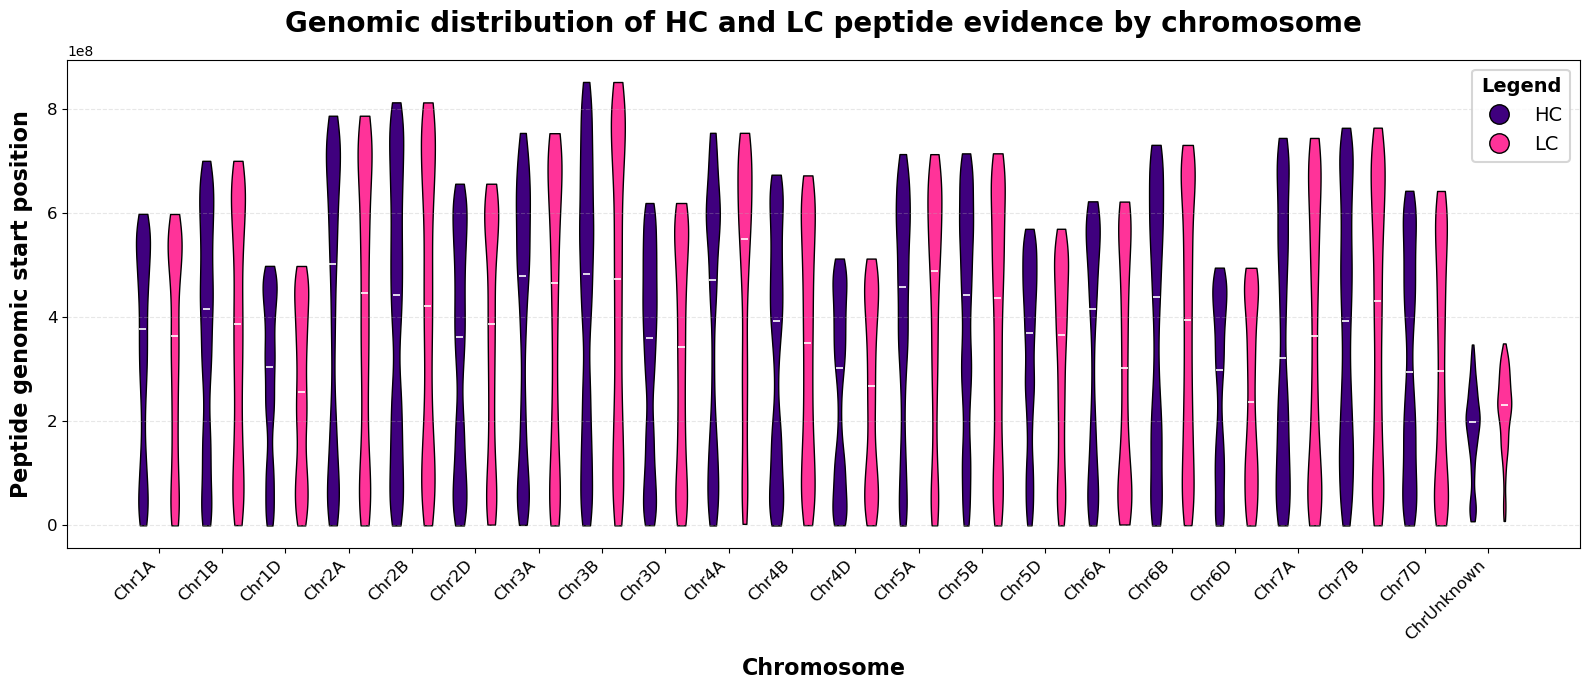

Figure saved: python_outputs\figures\step20_violinplot_peptide_genomic_start_by_chromosome.png
Summary saved: python_outputs\tables\wheat_peptide_genomic_start_by_chromosome_summary_step20.csv


,Chromosome,Evidence,Peptide_rows,Median_genomic_start,Mean_genomic_start,Min_genomic_start,Max_genomic_start
0,Chr1A,HC,102785,378520882.0,3.411754e+08,58543,598561110
1,Chr1A,LC,33210,370919131.5,3.332170e+08,41201,598363879
2,Chr1B,HC,109468,416739307.0,3.834039e+08,168112,700379123
3,Chr1B,LC,39263,370917562.0,3.624798e+08,520312,700376310
4,Chr1D,HC,106460,303287708.0,2.775585e+08,20705,498609718
5,Chr1D,LC,30206,266404424.0,2.672430e+08,20687,498498248
6,Chr2A,HC,130632,501782804.5,4.238702e+08,251216,787195194
7,Chr2A,LC,39713,428628820.0,4.121603e+08,249001,787082048
8,Chr2B,HC,135400,444573110.0,4.146318e+08,29396,812720911
9,Chr2B,LC,47911,418945614.0,4.155830e+08,113609,812724460


In [8]:
# ============================================================
# Step 20 — EDA: Chromosome distribution of peptide genomic positions
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1. Paths
# -----------------------------
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

projection_combined_file = tables_dir / "wheat_all_tissues_nonredundant_projected_peptides.csv"

figure_out = figures_dir / "step20_violinplot_peptide_genomic_start_by_chromosome.png"
summary_out = tables_dir / "wheat_peptide_genomic_start_by_chromosome_summary_step20.csv"

# -----------------------------
# 2. Brand colours
# -----------------------------
brand_colours = {
    "HC": "#3F007E",
    "LC": "#FF3399"
}

# -----------------------------
# 3. Load annotation-projected peptide data in chunks
# -----------------------------
protein_gene_mapping_file = tables_dir / "wheat_protein_gene_mapping_HC_LC.csv"

chrom_col = "Chromosome"
start_col = "BED_start_0based"
protein_col = "ProteinID"
confidence_col = "Annotation_confidence"

# Load ProteinID → Annotation_confidence lookup
protein_mapping = pd.read_csv(
    protein_gene_mapping_file,
    usecols=lambda col: col in [protein_col, confidence_col],
    low_memory=False
)

protein_conf_lookup = (
    protein_mapping
    .dropna(subset=[protein_col, confidence_col])
    .drop_duplicates(subset=[protein_col])
)

projected_needed_cols = [
    chrom_col,
    start_col,
    protein_col
]

max_points_per_group = 50000
chunksize = 100_000

summary_chunks = []
sample_chunks = []

for chunk in pd.read_csv(
    projection_combined_file,
    usecols=lambda col: col in projected_needed_cols,
    chunksize=chunksize,
    low_memory=False
):

    chunk = chunk.merge(
        protein_conf_lookup,
        on=protein_col,
        how="left"
    )

    chunk = chunk.rename(columns={
        chrom_col: "Chromosome",
        start_col: "Genomic_start",
        confidence_col: "Evidence"
    })

    chunk["Evidence"] = chunk["Evidence"].astype(str).str.upper()
    chunk["Evidence"] = chunk["Evidence"].map({
        "HC": "HC",
        "LC": "LC"
    })

    chunk["Genomic_start"] = pd.to_numeric(
        chunk["Genomic_start"],
        errors="coerce"
    )

    chunk = chunk.dropna(
        subset=["Chromosome", "Genomic_start", "Evidence"]
    )

    chunk["Chromosome"] = chunk["Chromosome"].astype(str)

    summary_chunks.append(
        chunk[["Chromosome", "Genomic_start", "Evidence"]]
    )

    # Sample lightly from each chunk for plotting
    if len(chunk) > 3000:
        chunk_sample = chunk.sample(
            n=3000,
            random_state=42
        )
    else:
        chunk_sample = chunk

    sample_chunks.append(
        chunk_sample[["Chromosome", "Genomic_start", "Evidence"]]
    )

projected_summary_data = pd.concat(summary_chunks, ignore_index=True)
projected_plot_sample = pd.concat(sample_chunks, ignore_index=True)

print(f"Projected rows for summary: {len(projected_summary_data):,}")
print(f"Projected sampled rows before group cap: {len(projected_plot_sample):,}")

# -----------------------------
# 4. Chromosome ordering
# -----------------------------
def normalise_chromosome_name(value):
    value = str(value).strip()

    if value.lower() in ["chrunknown", "unknown", "nan"]:
        return "ChrUnknown"

    if value.startswith("Chr"):
        return value

    return "Chr" + value

chrom_order = [
    "Chr1A", "Chr1B", "Chr1D",
    "Chr2A", "Chr2B", "Chr2D",
    "Chr3A", "Chr3B", "Chr3D",
    "Chr4A", "Chr4B", "Chr4D",
    "Chr5A", "Chr5B", "Chr5D",
    "Chr6A", "Chr6B", "Chr6D",
    "Chr7A", "Chr7B", "Chr7D",
    "ChrUnknown"
]

projected_summary_data["Chromosome"] = projected_summary_data["Chromosome"].apply(normalise_chromosome_name)
projected_plot_sample["Chromosome"] = projected_plot_sample["Chromosome"].apply(normalise_chromosome_name)

projected_summary_data = projected_summary_data[
    projected_summary_data["Chromosome"].isin(chrom_order)
].copy()

projected_plot_sample = projected_plot_sample[
    projected_plot_sample["Chromosome"].isin(chrom_order)
].copy()

# -----------------------------
# 5. Build summary table from full projected data
# -----------------------------
summary_data = projected_summary_data.copy()

summary_data["Chromosome"] = pd.Categorical(
    summary_data["Chromosome"],
    categories=chrom_order,
    ordered=True
)

summary = (
    summary_data
    .groupby(["Chromosome", "Evidence"], observed=True)
    .agg(
        Peptide_rows=("Genomic_start", "size"),
        Median_genomic_start=("Genomic_start", "median"),
        Mean_genomic_start=("Genomic_start", "mean"),
        Min_genomic_start=("Genomic_start", "min"),
        Max_genomic_start=("Genomic_start", "max")
    )
    .reset_index()
)

summary.to_csv(summary_out, index=False)

# Free memory before plotting
del projected_summary_data
del summary_data
del summary_chunks

# -----------------------------
# 6. Build plot sample and cap per chromosome/evidence group
# -----------------------------
plot_data = projected_plot_sample.copy()

plot_data["Chromosome"] = pd.Categorical(
    plot_data["Chromosome"],
    categories=chrom_order,
    ordered=True
)

sampled_groups = []

for (chrom, evidence), group in plot_data.groupby(
    ["Chromosome", "Evidence"],
    observed=True
):

    if len(group) > max_points_per_group:
        group = group.sample(
            n=max_points_per_group,
            random_state=42
        )

    sampled_groups.append(group)

if len(sampled_groups) == 0:
    raise ValueError(
        "No chromosome/evidence groups remained after filtering. "
        "Check chromosome names in the input tables."
    )

plot_sample = pd.concat(sampled_groups, ignore_index=True)

print(f"Rows used for violin plot: {len(plot_sample):,}")


# -----------------------------
# 7. Violin plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 7))

positions = range(len(chrom_order))
offsets = {
    "HC": -0.25,
    "LC": 0.25
}

width = 0.22

for evidence in ["HC", "LC"]:

    data_by_chrom = []
    pos_by_chrom = []

    for i, chrom in enumerate(chrom_order):

        values = plot_sample.loc[
            (plot_sample["Chromosome"] == chrom) &
            (plot_sample["Evidence"] == evidence),
            "Genomic_start"
        ].dropna()

        if len(values) > 0:
            data_by_chrom.append(values)
            pos_by_chrom.append(i + offsets[evidence])

    if len(data_by_chrom) == 0:
        continue

    violin = ax.violinplot(
        data_by_chrom,
        positions=pos_by_chrom,
        widths=width,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    for body in violin["bodies"]:
        body.set_facecolor(brand_colours[evidence])
        body.set_edgecolor("black")
        body.set_alpha(1)

    violin["cmedians"].set_color("white")
    violin["cmedians"].set_linewidth(1.2)

# -----------------------------
# 8. Plot formatting
# -----------------------------

ax.set_xticks(list(positions))

ax.set_xticklabels(
    chrom_order,
    rotation=45,
    ha="right",
    fontsize=12
)

# Y-axis tick labels
ax.tick_params(
    axis="y",
    labelsize=12
)

# Axis labels
ax.set_xlabel(
    "Chromosome",
    fontsize=16,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Peptide genomic start position",
    fontsize=16,
    fontweight="bold",
    labelpad=10
)

# Title
ax.set_title(
    "Genomic distribution of HC and LC peptide evidence by chromosome",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Manual legend
legend_labels = {
    "HC": "HC",
    "LC": "LC"
}

legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=legend_labels[label],
        markerfacecolor=colour,
        markeredgecolor="black",
        markersize=14
    )
    for label, colour in brand_colours.items()
]

legend = ax.legend(
    handles=legend_handles,
    title="Legend",
    title_fontsize=14,
    fontsize=14,
    loc="upper right",
    frameon=True
)

# Bold legend title
legend.get_title().set_fontweight("bold")

# Optional: thicker legend border
legend.get_frame().set_linewidth(1.5)

# Tight layout
plt.tight_layout()

plt.savefig(
    figure_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved: {figure_out}")
print(f"Summary saved: {summary_out}")

display(summary)

# Step 21 — EDA: Circular Tissue-Level Peptide Genome Map

This final exploratory analysis generates a Circos-style circular genome map showing projected peptide evidence across wheat chromosomes and tissues.

The figure is inspired by the circular peptide distribution plot generated in the 2024 wheat proteogenomics study, but is produced here directly in Python using `pycirclize`.

---

## Input files

### Peptide genome projection tables from Step 9

One file per tissue:

```text
FragPipe_FirstAuthor_Source_Tissue-Raw-Code_peptide_genome_projection.csv
```

Only successfully projected peptide rows were included.

### Filtering rule

```text
Projection_status == "projected"
```

### Parsed GFF3 annotation table from Step 5

```text
wheat_gff3_parsed_features_HC_LC.csv
```

This table was used to estimate chromosome lengths for circular plotting.

---

## Plot design

The circular plot contains:

| Plot element | Description |
|---|---|
| Outer sectors | Wheat chromosomes |
| Inner rings | Individual source–tissue peptide tracks |
| Tick marks | Projected peptide genomic start positions |
| Colour | Tissue track identity |

Each tissue is represented as a separate ring, similar to the 2024 Galaxy Circos visualisation.

---

## Memory-light plotting strategy

Because the full projected peptide dataset contains millions of rows, the plotting procedure was designed to be memory efficient.

The workflow:

1. Reads each tissue projection file in chunks.
2. Keeps only projected peptide rows.
3. Samples peptide positions within each tissue/chromosome group.
4. Caps the number of plotted points per tissue and chromosome.

The summary table retains total projected peptide counts and sampled plotted counts.

---

## Chromosomes included

The plot includes the 21 assembled wheat chromosomes:

```text
Chr1A–Chr7D
```

`ChrUnknown` was excluded from the circular plot to preserve chromosome-scale interpretability.

---

## Output files

### Figure

```text
step21_circos_tissue_peptide_tracks.png
```

### Summary table

```text
wheat_circos_tissue_peptide_summary_step21.csv
```

---

## Purpose

This figure provides a genome-wide overview of peptide evidence across wheat tissues.

It highlights:

- chromosome-level peptide distribution,
- tissue-specific peptide evidence patterns,
- broad proteogenomic coverage across the wheat genome,
- and the suitability of the generated peptide tracks for public Apollo/JBrowse exploration.

In [2]:
# # install library
# !pip install pycirclize

Chromosomes loaded: 21
Sampling: MSV000090572_stored_grain
Sampling: PXD050500_coleoptile
Sampling: PXD050500_node
Sampling: PXD050500_radicle
Sampling: PXD004720_anther
Sampling: PXD004720_boot
Sampling: PXD004720_coleoptile
Sampling: PXD004720_embryo
Sampling: PXD004720_endosperm
Sampling: PXD004720_glume
Sampling: PXD004720_grain_zadoks_70
Sampling: PXD004720_grain_zadoks_71
Sampling: PXD004720_grain_zadoks_75
Sampling: PXD004720_grain_zadoks_83
Sampling: PXD004720_grain_zadoks_87
Sampling: PXD004720_leaf_flag_mature
Sampling: PXD004720_leaf_flag_senescing
Sampling: PXD004720_leaf_flag_young
Sampling: PXD004720_lemma
Sampling: PXD004720_node
Sampling: PXD004720_node_secretion
Sampling: PXD004720_palea
Sampling: PXD004720_pericarp
Sampling: PXD004720_pollen
Sampling: PXD004720_rachilla
Sampling: PXD004720_radicle
Sampling: PXD004720_root_mature
Sampling: PXD004720_root_secretion
Sampling: PXD004720_root_tip
Sampling: PXD004720_root_vasculature
Sampling: PXD004720_spike_immature
Sampl

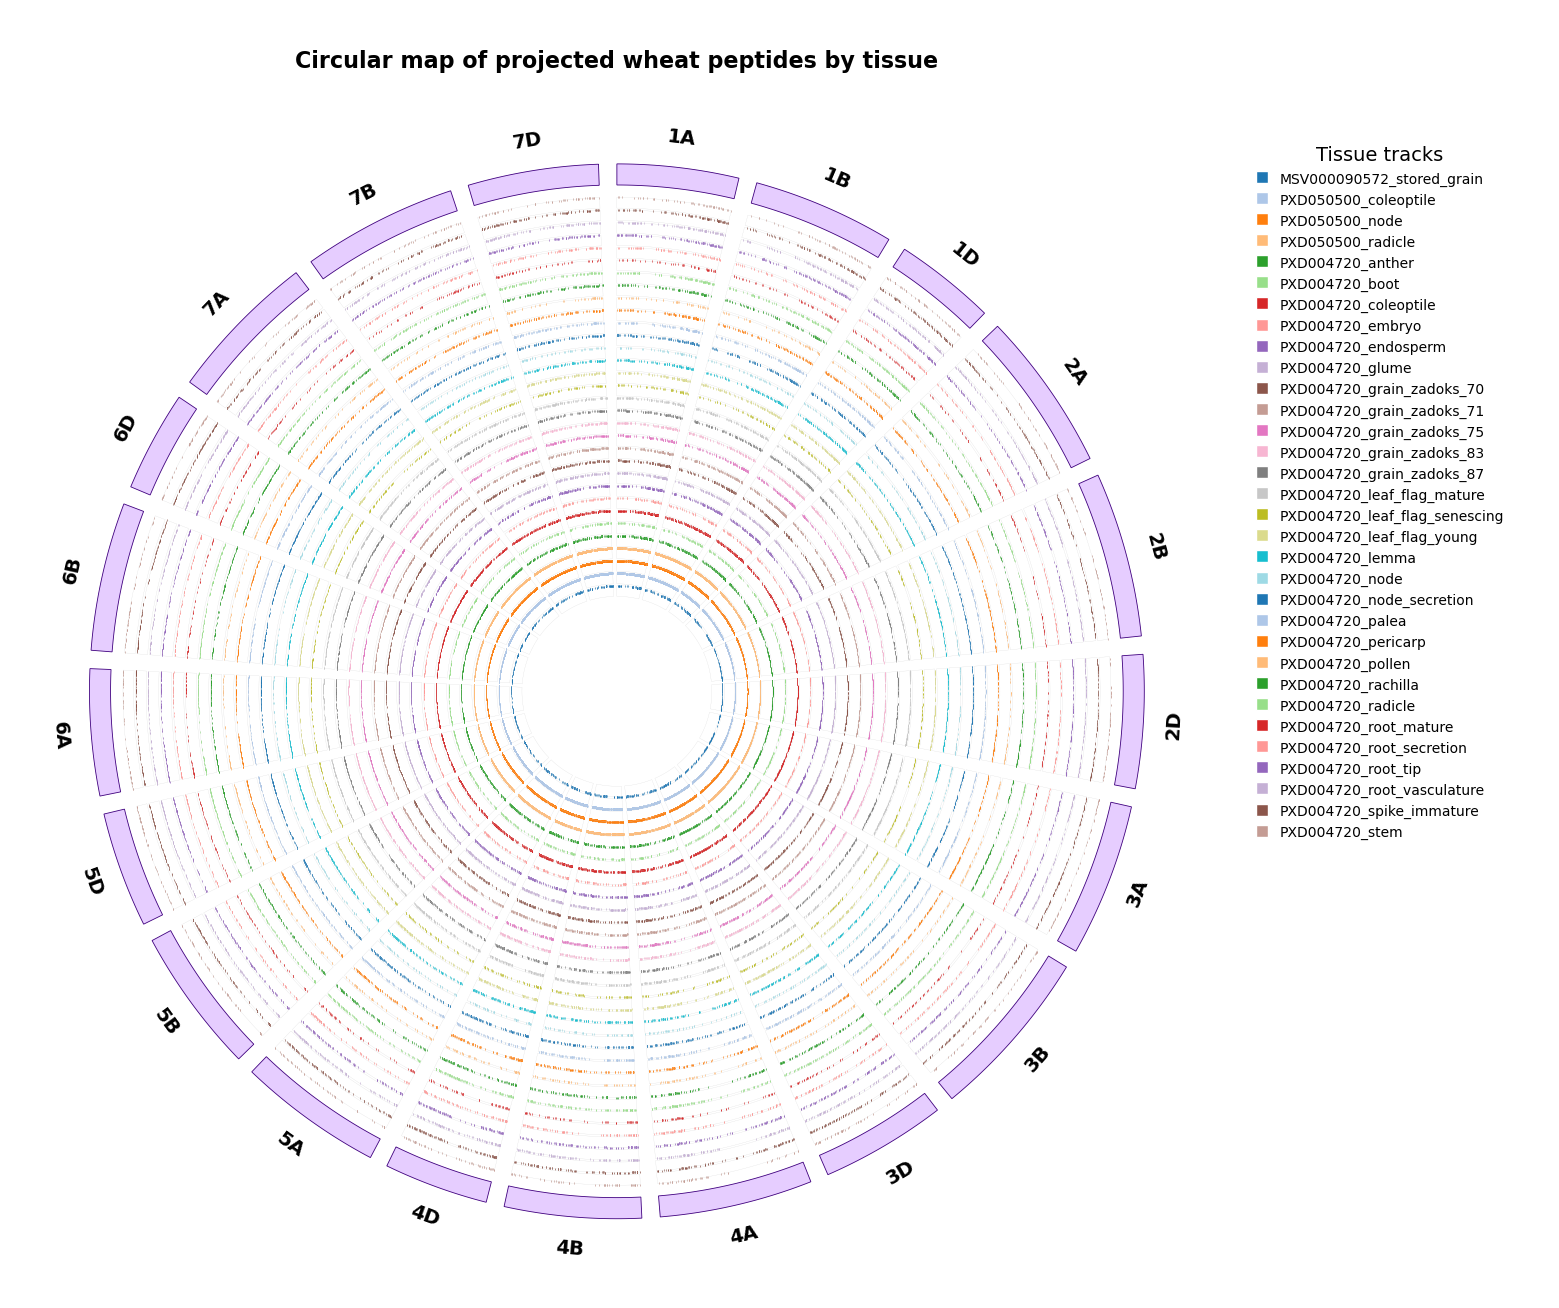

Figure saved: python_outputs\figures\step21_circos_tissue_peptide_tracks.png


,Source,Tissue,Source_Tissue,Chromosome,Total_projected_peptide_rows,Sampled_points_plotted
0,MSV000090572,stored_grain,MSV000090572_stored_grain,Chr1A,1498,50
1,MSV000090572,stored_grain,MSV000090572_stored_grain,Chr1B,1676,50
2,MSV000090572,stored_grain,MSV000090572_stored_grain,Chr1D,1477,50
3,MSV000090572,stored_grain,MSV000090572_stored_grain,Chr2A,1264,50
4,MSV000090572,stored_grain,MSV000090572_stored_grain,Chr2B,1444,50


In [9]:
# ============================================================
# Step 21 — EDA: Circular tissue-level peptide genome map
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from pycirclize import Circos

# -----------------------------
# 1. Paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"
gff3_features_file = tables_dir / "wheat_gff3_parsed_features_HC_LC.csv"

figure_out = figures_dir / "step21_circos_tissue_peptide_tracks.png"
summary_out = tables_dir / "wheat_circos_tissue_peptide_summary_step21.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")

# -----------------------------
# 2. Parameters
# -----------------------------
chrom_order = [
    "Chr1A", "Chr1B", "Chr1D",
    "Chr2A", "Chr2B", "Chr2D",
    "Chr3A", "Chr3B", "Chr3D",
    "Chr4A", "Chr4B", "Chr4D",
    "Chr5A", "Chr5B", "Chr5D",
    "Chr6A", "Chr6B", "Chr6D",
    "Chr7A", "Chr7B", "Chr7D"
]

max_points_per_tissue_chrom = 400
chunksize = 100_000

# -----------------------------
# 3. Helper functions
# -----------------------------
def normalise_chromosome_name(value):
    value = str(value).strip()

    if value.lower() in ["chrunknown", "unknown", "nan"]:
        return "ChrUnknown"

    if value.startswith("Chr"):
        return value

    return "Chr" + value


def clean_tissue_label(value):
    return str(value).replace("-", "_").replace(" ", "_")


# -----------------------------
# 4. Estimate chromosome lengths from GFF3 annotation
# -----------------------------
chrom_lengths = {}

for chunk in pd.read_csv(
    gff3_features_file,
    usecols=lambda col: col in ["SeqID", "End"],
    chunksize=chunksize,
    low_memory=False
):

    chunk["SeqID"] = chunk["SeqID"].apply(normalise_chromosome_name)
    chunk["End"] = pd.to_numeric(chunk["End"], errors="coerce")

    chunk = chunk.dropna(subset=["SeqID", "End"])

    for chrom, group in chunk.groupby("SeqID"):
        if chrom in chrom_order:
            max_end = int(group["End"].max())
            chrom_lengths[chrom] = max(max_end, chrom_lengths.get(chrom, 0))

chrom_lengths = {
    chrom: chrom_lengths[chrom]
    for chrom in chrom_order
    if chrom in chrom_lengths
}

print(f"Chromosomes loaded: {len(chrom_lengths)}")

# -----------------------------
# 5. Sample projected peptide positions by tissue and chromosome
# -----------------------------
tissue_positions = defaultdict(lambda: defaultdict(list))
summary_records = []

for _, row in manifest.iterrows():

    source = row["Source"]
    tissue = clean_tissue_label(row["Tissue-Raw-Code"])
    source_tissue = f"{source}_{tissue}"

    projection_filename = row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Warning: missing projection file, skipped: {projection_path}")
        continue

    print(f"Sampling: {source_tissue}")

    chrom_counts = defaultdict(int)

    for chunk in pd.read_csv(
        projection_path,
        usecols=lambda col: col in [
            "Projection_status",
            "Chromosome",
            "BED_start_0based"
        ],
        chunksize=chunksize,
        low_memory=False
    ):

        chunk = chunk[chunk["Projection_status"] == "projected"].copy()

        if chunk.empty:
            continue

        chunk["Chromosome"] = chunk["Chromosome"].apply(normalise_chromosome_name)

        chunk = chunk[chunk["Chromosome"].isin(chrom_order)].copy()

        chunk["BED_start_0based"] = pd.to_numeric(
            chunk["BED_start_0based"],
            errors="coerce"
        )

        chunk = chunk.dropna(subset=["Chromosome", "BED_start_0based"])

        for chrom, group in chunk.groupby("Chromosome"):

            chrom_counts[chrom] += len(group)

            # Sample small number per chunk to avoid memory overload
            n_sample = min(50, len(group))

            tissue_positions[source_tissue][chrom].extend(
                group["BED_start_0based"]
                .sample(n=n_sample, random_state=42)
                .astype(int)
                .tolist()
            )

    # Final cap per tissue/chromosome
    for chrom in chrom_order:
        positions = tissue_positions[source_tissue][chrom]

        if len(positions) > max_points_per_tissue_chrom:
            positions = (
                pd.Series(positions)
                .sample(n=max_points_per_tissue_chrom, random_state=42)
                .astype(int)
                .tolist()
            )
            tissue_positions[source_tissue][chrom] = positions

        summary_records.append({
            "Source": source,
            "Tissue": tissue,
            "Source_Tissue": source_tissue,
            "Chromosome": chrom,
            "Total_projected_peptide_rows": chrom_counts.get(chrom, 0),
            "Sampled_points_plotted": len(tissue_positions[source_tissue][chrom])
        })

summary = pd.DataFrame(summary_records)
summary.to_csv(summary_out, index=False)

print(f"Summary saved: {summary_out}")

# -----------------------------
# 6. Tissue colours
# -----------------------------
source_tissues = list(tissue_positions.keys())

cmap = plt.get_cmap("tab20")
tissue_colours = {
    tissue: cmap(i % 20)
    for i, tissue in enumerate(source_tissues)
}

# -----------------------------
# 7. Build Circos plot
# -----------------------------
circos = Circos(chrom_lengths, space=2)

# Outer chromosome track
for sector in circos.sectors:
    outer_track = sector.add_track((96, 100))
    outer_track.axis(fc="#E6CDFF", ec="#3F007E", lw=0.6)

    sector.text(
        sector.name.replace("Chr", ""),
        r=104,
        size=14,
        weight="bold"
    )

# Tissue rings
n_tissues = len(source_tissues)
inner_r = 18
outer_r = 94
ring_height = (outer_r - inner_r) / n_tissues

for i, source_tissue in enumerate(source_tissues):

    r0 = inner_r + i * ring_height
    r1 = r0 + ring_height * 0.85

    colour = tissue_colours[source_tissue]

    for sector in circos.sectors:

        track = sector.add_track((r0, r1))
        track.axis(fc="white", ec="lightgrey", lw=0.15)

        chrom = sector.name
        positions = tissue_positions[source_tissue].get(chrom, [])

        if len(positions) == 0:
            continue

        y_values = [0.5] * len(positions)

        track.scatter(
            positions,
            y_values,
            s=4,
            color=colour,
            marker="|",
            linewidths=0.5
        )

# -----------------------------
# 8. Plot and legend
# -----------------------------
fig = circos.plotfig(figsize=(12, 12))

# Manual legend outside plot
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        color="w",
        label=tissue,
        markerfacecolor=tissue_colours[tissue],
        markersize=8
    )
    for tissue in source_tissues
]

fig.legend(
    handles=legend_handles,
    title="Tissue tracks",
    loc="upper right",
    bbox_to_anchor=(1.25, 0.95),
    frameon=True,
    fontsize=10,
    title_fontsize=14
)

legend.get_title().set_fontweight("bold")
legend.get_frame().set_edgecolor("lightgrey")
legend.get_frame().set_linewidth(1)
legend.get_frame().set_facecolor("white")

fig.suptitle(
    "Circular map of projected wheat peptides by tissue",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.savefig(
    figure_out,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure saved: {figure_out}")
display(summary.head())

# Step 22 — EDA: Circular Confidence-Level Peptide Genome Map

This exploratory analysis generates a Circos-style circular genome map showing peptide evidence by annotation-confidence category across the wheat genome.

Unlike the tissue-ring Circos plot in Step 21, this plot groups peptide evidence into three biologically meaningful classes:

```text
HC projected peptides
LC projected peptides
```

---

## Input files

### Non-redundant annotation-projected peptide table from Step 11

```text
wheat_all_tissues_nonredundant_projected_peptides.csv
```

### Protein-to-gene mapping table from Step 5

```text
wheat_protein_gene_mapping_HC_LC.csv
```

### Parsed GFF3 annotation table from Step 5

```text
wheat_gff3_parsed_features_HC_LC.csv
```

The GFF3-derived table was used to estimate chromosome lengths for the circular genome layout.

---

## Plot design

The circular plot contains:

| Ring | Evidence class |
|---|---|
| Inner ring | LC annotation-projected peptides |
| Outer ring | HC annotation-projected peptides |

Each tick mark represents a sampled peptide genomic start position.

---

## Memory-light plotting strategy

Because the full peptide dataset contains millions of mapped positions, the workflow was designed to run on standard desktop hardware.

The code:

1. Reads the projected peptide table in chunks.
2. Keeps only required columns.
3. Maps protein IDs to HC/LC confidence.
4. Samples peptide positions per chromosome and evidence class.
5. Caps the number of plotted points per chromosome/evidence class.

The full counts and sampled counts are retained in the summary table.

---

## Chromosomes included

The plot includes the 21 assembled wheat chromosomes:

```text
Chr1A–Chr7D
```

`ChrUnknown` was excluded to preserve chromosome-scale interpretability.

---

## Output files

### Figure

```text
step22_circos_confidence_level_peptide_map.png
```

### Summary table

```text
wheat_circos_confidence_level_peptide_summary_step22.csv
```

---

## Purpose

This figure provides a compact genome-wide overview of peptide evidence stratified by annotation confidence.


Chromosomes loaded: 21
Summary saved: python_outputs\tables\wheat_circos_confidence_level_peptide_summary_step22.csv


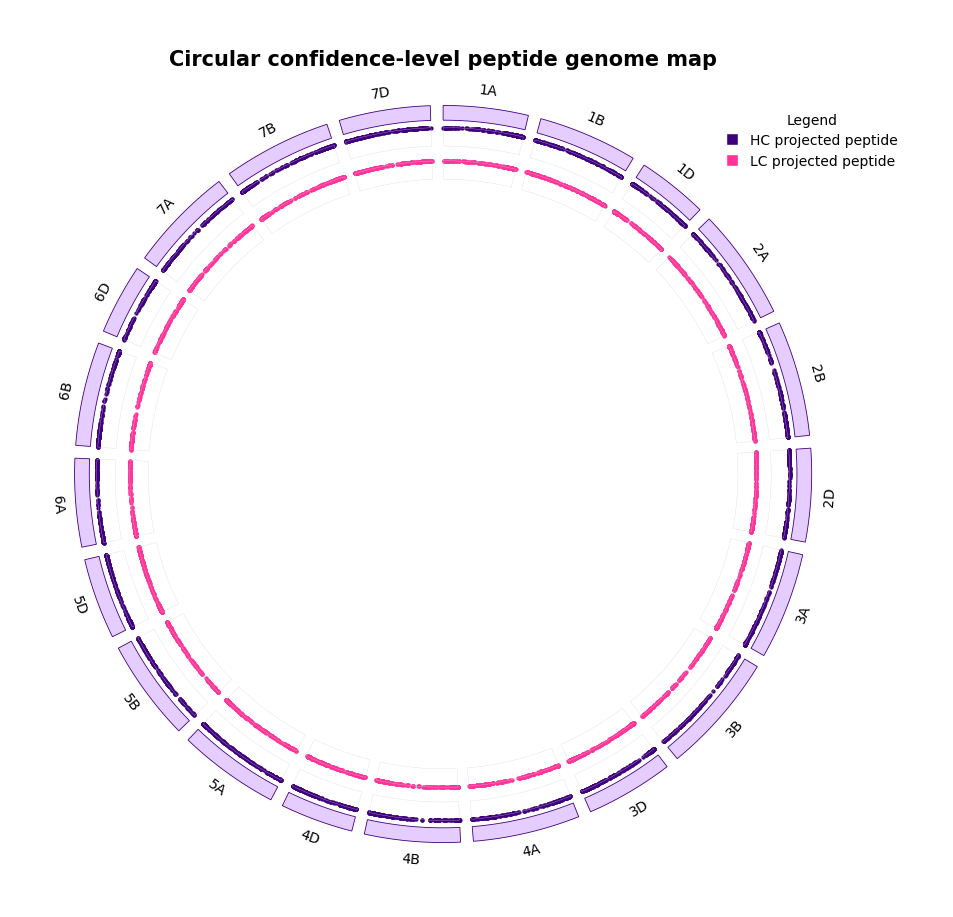

Figure saved: python_outputs\figures\step22_circos_confidence_level_peptide_map.png


,Evidence_class,Chromosome,Total_peptide_rows_or_loci,Sampled_points_plotted
0,HC,Chr1A,102785,160
1,HC,Chr1B,109468,160
2,HC,Chr1D,106460,240
3,HC,Chr2A,130632,160
4,HC,Chr2B,135400,240


In [20]:
# ============================================================
# Step 22 — EDA: Circular confidence-level peptide genome map
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from pycirclize import Circos

# -----------------------------
# 1. Paths
# -----------------------------
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

projection_combined_file = tables_dir / "wheat_all_tissues_nonredundant_projected_peptides.csv"
protein_gene_mapping_file = tables_dir / "wheat_protein_gene_mapping_HC_LC.csv"
gff3_features_file = tables_dir / "wheat_gff3_parsed_features_HC_LC.csv"

figure_out = figures_dir / "step22_circos_confidence_level_peptide_map.png"
summary_out = tables_dir / "wheat_circos_confidence_level_peptide_summary_step22.csv"

# -----------------------------
# 2. Parameters
# -----------------------------
chrom_order = [
    "Chr1A", "Chr1B", "Chr1D",
    "Chr2A", "Chr2B", "Chr2D",
    "Chr3A", "Chr3B", "Chr3D",
    "Chr4A", "Chr4B", "Chr4D",
    "Chr5A", "Chr5B", "Chr5D",
    "Chr6A", "Chr6B", "Chr6D",
    "Chr7A", "Chr7B", "Chr7D"
]

chunksize = 100_000
max_points_per_chrom_confidence = 800

brand_colours = {
    "HC": "#3F007E",
    "LC": "#FF3399",
    "lavender": "#E6CDFF"
}

track_ranges = {
    "LC": (80, 85),
    "HC": (89, 94)
}

# -----------------------------
# 3. Helper functions
# -----------------------------
def normalise_chromosome_name(value):
    value = str(value).strip()

    if value.lower() in ["chrunknown", "unknown", "nan"]:
        return "ChrUnknown"

    if value.startswith("Chr"):
        return value

    return "Chr" + value


# -----------------------------
# 4. Estimate chromosome lengths from GFF3 annotation
# -----------------------------
chrom_lengths = {}

for chunk in pd.read_csv(
    gff3_features_file,
    usecols=lambda col: col in ["SeqID", "End"],
    chunksize=chunksize,
    low_memory=False
):

    chunk["SeqID"] = chunk["SeqID"].apply(normalise_chromosome_name)
    chunk["End"] = pd.to_numeric(chunk["End"], errors="coerce")

    chunk = chunk.dropna(subset=["SeqID", "End"])

    for chrom, group in chunk.groupby("SeqID"):
        if chrom in chrom_order:
            max_end = int(group["End"].max())
            chrom_lengths[chrom] = max(max_end, chrom_lengths.get(chrom, 0))

chrom_lengths = {
    chrom: chrom_lengths[chrom]
    for chrom in chrom_order
    if chrom in chrom_lengths
}

print(f"Chromosomes loaded: {len(chrom_lengths)}")

# -----------------------------
# 5. Load ProteinID → HC/LC lookup
# -----------------------------
protein_col = "ProteinID"
confidence_col = "Annotation_confidence"

protein_mapping = pd.read_csv(
    protein_gene_mapping_file,
    usecols=lambda col: col in [protein_col, confidence_col],
    low_memory=False
)

protein_conf_lookup = (
    protein_mapping
    .dropna(subset=[protein_col, confidence_col])
    .drop_duplicates(subset=[protein_col])
)

# -----------------------------
# 6. Sample projected HC/LC peptide positions
# -----------------------------
confidence_positions = defaultdict(lambda: defaultdict(list))
summary_counts = defaultdict(lambda: defaultdict(int))

projected_needed_cols = [
    "Chromosome",
    "BED_start_0based",
    "ProteinID"
]

for chunk in pd.read_csv(
    projection_combined_file,
    usecols=lambda col: col in projected_needed_cols,
    chunksize=chunksize,
    low_memory=False
):

    chunk = chunk.merge(
        protein_conf_lookup,
        on="ProteinID",
        how="left"
    )

    chunk["Chromosome"] = chunk["Chromosome"].apply(normalise_chromosome_name)

    chunk = chunk[
        chunk["Chromosome"].isin(chrom_order)
    ].copy()

    chunk["BED_start_0based"] = pd.to_numeric(
        chunk["BED_start_0based"],
        errors="coerce"
    )

    chunk["Annotation_confidence"] = (
        chunk["Annotation_confidence"]
        .astype(str)
        .str.upper()
    )

    chunk = chunk.dropna(
        subset=["Chromosome", "BED_start_0based", "Annotation_confidence"]
    )

    chunk = chunk[
        chunk["Annotation_confidence"].isin(["HC", "LC"])
    ].copy()

    if chunk.empty:
        continue

    for (confidence, chrom), group in chunk.groupby(
        ["Annotation_confidence", "Chromosome"]
    ):

        summary_counts[confidence][chrom] += len(group)

        n_sample = min(80, len(group))

        confidence_positions[confidence][chrom].extend(
            group["BED_start_0based"]
            .sample(n=n_sample, random_state=42)
            .astype(int)
            .tolist()
        )

# Final cap per chromosome/confidence
for confidence in ["HC", "LC"]:
    for chrom in chrom_order:
        positions = confidence_positions[confidence][chrom]

        if len(positions) > max_points_per_chrom_confidence:
            positions = (
                pd.Series(positions)
                .sample(
                    n=max_points_per_chrom_confidence,
                    random_state=42
                )
                .astype(int)
                .tolist()
            )

            confidence_positions[confidence][chrom] = positions

# -----------------------------
# 7. Save summary table
# -----------------------------
summary_records = []

for confidence in ["HC", "LC"]:
    for chrom in chrom_order:
        summary_records.append({
            "Evidence_class": confidence,
            "Chromosome": chrom,
            "Total_peptide_rows_or_loci": summary_counts[confidence].get(chrom, 0),
            "Sampled_points_plotted": len(confidence_positions[confidence][chrom])
        })

summary = pd.DataFrame(summary_records)
summary.to_csv(summary_out, index=False)

print(f"Summary saved: {summary_out}")

# -----------------------------
# 8. Build Circos plot
# -----------------------------
def filter_positions_within_chromosome(positions, chrom, chrom_lengths):
    chrom_len = chrom_lengths.get(chrom)

    if chrom_len is None:
        return []

    return [
        int(pos)
        for pos in positions
        if pd.notna(pos) and 0 <= int(pos) <= chrom_len
    ]

circos = Circos(chrom_lengths, space=2)

# Outer chromosome track
for sector in circos.sectors:
    outer_track = sector.add_track((96, 100))
    outer_track.axis(fc="#E6CDFF", ec="#3F007E", lw=0.6)

    sector.text(
        sector.name.replace("Chr", ""),
        r=103,
        size=10
    )

# Confidence rings: LC centre, HC outside
for evidence_class in ["LC", "HC"]:

    r0, r1 = track_ranges[evidence_class]
    colour = brand_colours[evidence_class]

    for sector in circos.sectors:

        track = sector.add_track((r0, r1))
        track.axis(fc="white", ec="lightgrey", lw=0.2)

        chrom = sector.name
        positions = confidence_positions[evidence_class].get(chrom, [])
        
        positions = filter_positions_within_chromosome(
            positions,
            chrom,
            chrom_lengths
        )
        
        if len(positions) == 0:
            continue

        y_values = [0.5] * len(positions)

        track.scatter(
            positions,
            y_values,
            s=14,
            color=colour,
            marker=".",
            linewidths=1.2
        )

# -----------------------------
# 9. Plot and legend
# -----------------------------
fig = circos.plotfig(figsize=(8.5, 8.5))

legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="HC projected peptide",
        markerfacecolor=brand_colours["HC"],
        markersize=9
    ),
    plt.Line2D(
        [0], [0],
        marker="s",
        color="w",
        label="LC projected peptide",
        markerfacecolor=brand_colours["LC"],
        markersize=9
    )
]

fig.legend(
    handles=legend_handles,
    title="Legend",
    loc="upper right",
    bbox_to_anchor=(1.05, 0.92),
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

fig.suptitle(
    "Circular confidence-level peptide genome map",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

plt.savefig(
    figure_out,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
    facecolor="white"
)

plt.show()

print(f"Figure saved: {figure_out}")
display(summary.head())

# Step 23 — Combine Python Workflow Summary Tables at Source/Tissue Level

This step integrates all major workflow summary tables generated throughout the proteogenomics pipeline into a single comprehensive tissue-level summary table. The resulting dataset provides a unified overview of peptide identification, protein mapping, genomic projection, and BED export statistics across all analysed tissues and data sources.

---

The workflow begins by defining the input/output directories and loading the FragPipe tissue manifest, which serves as the backbone for the integrated summary structure. Helper functions are then used to safely load summary files only if they exist and to standardise merge keys (`Source` and `Tissue`) across datasets. Combined “ALL” rows are removed to retain only tissue-level summaries suitable for downstream comparative analyses.

Summary outputs from previous workflow steps are then loaded, including:

- **Step 6:** FragPipe annotation summaries  
- **Step 7:** Peptide–protein evidence summaries  
- **Step 8:** Peptide–protein–gene mapping summaries  
- **Step 9:** Peptide genomic projection summaries  
- **Step 11:** BED export summaries  
- **Step 13:** Tissue-level proteogenomic summaries  

To minimise redundancy and avoid excessively wide tables, only biologically informative and technically relevant columns are retained from each step. Step 6 data are pivoted to separate peptide and protein statistics into distinct columns while preserving one row per source/tissue combination.

---

All summary tables are sequentially merged into a single integrated dataframe using `Source` and `Tissue` as common merge keys. The final combined summary contains metrics spanning the entire workflow, including:

- total peptide/protein identifications,
- contaminant filtering statistics,
- peptide-to-protein mapping performance,
- gene model coverage,
- peptide genomic projection success,
- BED track export statistics,
- chromosome coverage,
- exon-spanning peptide evidence,
- HC/LC gene model representation.

---

The completed integrated summary table is exported as:

`wheat_complete_python_workflow_summary_step23.csv`

This consolidated table provides a high-level overview of the entire computational proteogenomics workflow and serves as a central resource for downstream exploratory data analysis, comparative tissue assessments, manuscript reporting, and reproducibility documentation.

In [21]:
# ============================================================
# Step 23. Combine Python workflow summary tables at source/tissue level
# ============================================================

import pandas as pd
from pathlib import Path
import re

# -----------------------------
# 1. Input / output paths
# -----------------------------
tables_dir = Path("python_outputs/tables")

tables_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

complete_python_summary_out = tables_dir / "wheat_complete_python_workflow_summary_step23.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")

# -----------------------------
# 2. Helper functions
# -----------------------------

def load_summary_if_exists(path):
    if Path(path).exists():
        return pd.read_csv(path, low_memory=False)
    print(f"Summary not found, skipped: {path}")
    return None


def standardise_tissue_key(data):
    """
    Keep only tissue-level rows and standardise merge keys where possible.
    """
    if data is None:
        return None

    data = data.copy()

    required_keys = ["Source", "Tissue"]
    if not all(col in data.columns for col in required_keys):
        return None

    # Remove combined ALL rows for tissue-level integrated summary
    data = data[
        ~((data["Source"].astype(str) == "ALL") | (data["Tissue"].astype(str) == "ALL"))
    ].copy()

    return data


# -----------------------------
# 3. Combine all summary outputs
# -----------------------------

summary_files = {
    "step6": tables_dir / "wheat_fragpipe_annotation_summary_step6.csv",
    "step7": tables_dir / "wheat_fragpipe_peptide_protein_evidence_summary_step7.csv",
    "step8": tables_dir / "wheat_peptide_protein_gene_mapping_summary_step8.csv",
    "step9": tables_dir / "wheat_peptide_genome_projection_summary_step9.csv",
    "step11": tables_dir / "wheat_bed_export_summary_step11.csv",
    "step13": tables_dir / "wheat_tissue_level_summary_step13.csv"
}

summaries = {
    step: standardise_tissue_key(load_summary_if_exists(path))
    for step, path in summary_files.items()
}

# Start from manifest as the backbone
complete_summary = manifest[[
    "Source",
    "Species",
    "Tissue-Raw-Code",
    "Batch"
]].copy()

complete_summary = complete_summary.rename(columns={"Tissue-Raw-Code": "Tissue"})

# Select useful columns from each step to avoid very wide duplicated tables
merge_specs = {
    "step6": [
        "Source", "Tissue", "FragPipe_result", "Total_rows",
        "Contaminant_count", "Non_contaminant_count"
    ],
    "step7": [
        "Source", "Tissue", "Non_contaminant_peptide_protein_pairs",
        "Unique_peptides", "Unique_proteins",
        "Peptides_mapping_to_multiple_proteins",
        "Proteins_supported_by_one_peptide",
        "Proteins_supported_by_two_or_more_peptides"
    ],
    "step8": [
        "Source", "Tissue", "Peptide_protein_pairs",
        "Mapped_peptide_protein_pairs",
        "Unmapped_peptide_protein_pairs",
        "Mapping_rate_percent",
        "Unique_gene_models",
        "Unique_transcripts"
    ],
    "step9": [
        "Source", "Tissue", "Peptide_protein_gene_rows",
        "Projected_rows", "Unprojected_rows",
        "Projection_rate_percent",
        "Unique_projected_peptides",
        "Unique_projected_proteins",
        "Unique_projected_gene_models",
        "Peptides_crossing_CDS_blocks"
    ],
    "step11": [
        "Source", "Tissue", "Projection_file",
        "BED_rows", "Unique_BED_peptides",
        "Unique_BED_proteins",
        "Unique_BED_gene_models",
        "Multi_block_peptides",
        "BED_labels_with_introns"
    ],
    "step13": [
        "Source", "Tissue", "Projected_peptide_rows",
        "Unique_peptides",	"Unique_proteins_isoforms",
        "Unique_gene_models",	"Unique_HC_gene_models",
        "Unique_LC_gene_models",	"Percent_total_gene_models_detected",
        "Percent_HC_gene_models_detected",	"Percent_LC_gene_models_detected",
        "Unique_chromosomes",	"Multi_block_peptide_rows",
        "Proteins_supported_by_one_peptide",	"Proteins_supported_by_two_or_more_peptides",
        "Genes_supported_by_one_peptide",	"Genes_supported_by_two_or_more_peptides"
    ]
}

for step, cols in merge_specs.items():

    data = summaries.get(step)

    if data is None:
        continue

    available_cols = [col for col in cols if col in data.columns]

    if "Source" not in available_cols or "Tissue" not in available_cols:
        continue

    data = data[available_cols].copy()

    # Step 6 has peptide and protein rows, so pivot to avoid duplicate tissue rows
    if step == "step6" and "FragPipe_result" in data.columns:
        data = data.pivot_table(
            index=["Source", "Tissue"],
            columns="FragPipe_result",
            values=["Total_rows", "Contaminant_count", "Non_contaminant_count"],
            aggfunc="first"
        )

        data.columns = [
            f"step6_{metric}_{result}"
            for metric, result in data.columns
        ]

        data = data.reset_index()

    else:
        # Avoid duplicated column names after merging
        rename_cols = {
            col: f"{step}_{col}"
            for col in data.columns
            if col not in ["Source", "Tissue"]
        }

        data = data.rename(columns=rename_cols)

        # Ensure one row per Source/Tissue
        data = data.drop_duplicates(subset=["Source", "Tissue"])

    complete_summary = complete_summary.merge(
        data,
        on=["Source", "Tissue"],
        how="left"
    )

complete_summary.to_csv(complete_python_summary_out, index=False)

print(f"\nComplete Python workflow summary saved: {complete_python_summary_out}")
display(complete_summary)


Complete Python workflow summary saved: python_outputs\tables\wheat_complete_python_workflow_summary_step23.csv


,Source,Species,Tissue,Batch,step6_Contaminant_count_peptide,step6_Contaminant_count_protein,step6_Non_contaminant_count_peptide,step6_Non_contaminant_count_protein,step6_Total_rows_peptide,step6_Total_rows_protein,...,step13_Unique_LC_gene_models,step13_Percent_total_gene_models_detected,step13_Percent_HC_gene_models_detected,step13_Percent_LC_gene_models_detected,step13_Unique_chromosomes,step13_Multi_block_peptide_rows,step13_Proteins_supported_by_one_peptide,step13_Proteins_supported_by_two_or_more_peptides,step13_Genes_supported_by_one_peptide,step13_Genes_supported_by_two_or_more_peptides
0,MSV000090572,bread wheat,stored_grain,single,14,6,9329,7068,9343.0,7074.0,...,5734,5.5868,8.5761,3.5874,22,3291,14132,3346,12085,2818
1,PXD050500,bread wheat,coleoptile,single,409,79,582775,137762,583184.0,137841.0,...,114284,79.4018,91.2154,71.4999,22,228372,59391,180070,57302,154504
2,PXD050500,bread wheat,node,single,483,94,595954,141678,596437.0,141772.0,...,116759,80.6135,91.9234,73.0483,22,235642,57470,185343,55363,159675
3,PXD050500,bread wheat,radicle,single,342,67,333058,105903,333400.0,105970.0,...,89887,67.4349,84.1770,56.2363,22,118195,68189,137827,64784,115100
4,PXD004720,bread wheat,anther,single,105,10,34098,10085,34203.0,10095.0,...,7959,11.0155,20.0395,4.9794,22,27776,19936,16890,16541,12843
5,PXD004720,bread wheat,boot,single,1,1,3643,2827,3644.0,2828.0,...,1941,2.7595,5.0695,1.2144,22,2728,7285,1923,5897,1464
6,PXD004720,bread wheat,coleoptile,single,101,11,41025,12205,41126.0,12216.0,...,10047,13.8226,25.0903,6.2857,22,31344,23572,22924,19818,17054
7,PXD004720,bread wheat,embryo,single,1,1,2867,2402,2868.0,2403.0,...,1644,2.1960,3.9415,1.0285,22,1411,6285,935,5152,706
8,PXD004720,bread wheat,endosperm,single,93,11,20081,7416,20174.0,7427.0,...,5808,8.2016,15.0308,3.6337,22,14269,15841,11613,13128,8750
9,PXD004720,bread wheat,glume,single,35,8,28648,9604,28683.0,9612.0,...,8169,10.7681,19.2257,5.1108,22,22131,19968,15572,16662,12062


# Step 24 — Compare 2024 tblastn-Based Peptide Alignments with 2026 Annotation-Guided Projections

This step compares the peptide genome coordinates generated in the 2024 `tblastn`-based proteogenomics study with the current 2026 annotation-guided peptide projection workflow.

The purpose is to determine how much of the previously reported peptide-to-genome evidence is recovered by the new exon-aware projection strategy, and to identify differences attributable to the change in mapping approach.

---

Only datasets included in the 2024 study are used for this comparison:

- `MSV000090572`
- `PXD004720`

---

The comparison is performed at three levels:

1. **Peptide sequence overlap**  
   Determines whether the same peptide sequences are present in both the 2024 and 2026 datasets, regardless of genomic position.

2. **Exact coordinate overlap**  
   Identifies peptide alignments with identical chromosome, start coordinate, end coordinate, strand, and peptide sequence.

3. **Locus-level interval overlap**  
   Identifies peptide mappings where the same peptide sequence maps to the same chromosome and strand with overlapping genomic intervals, allowing minor coordinate differences between `tblastn` alignments and annotation-guided projections.

The current workflow first combines all BED6 files from the two shared sources into a non-redundant BED6 table. This combined 2026 BED6 table is then compared with the 2024 BED6 file.

---

The outputs include:

- a non-redundant 2026 BED6 file restricted to the 2024 source datasets,
- a comparison summary table,
- peptide-level overlap tables,
- a bar plot summarising overlap categories.

---

This step provides a direct computational bridge between the previous `tblastn`-based workflow and the current annotation-guided projection workflow.

In [4]:
# # Install Python library
# !pip install matplotlib-venn

2024 tblastn BED loaded
Rows: 106,321
Unique peptides: 102,144

Current 2026 BED files selected:
 - python_outputs\bed\FragPipe_Duncan_PXD004720_anther_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_boot_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_coleoptile_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_embryo_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_endosperm_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_glume_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_grain-zadoks-70_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_grain-zadoks-71_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_grain-zadoks-75_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_grain-zadoks-83_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_grain-zadoks-87_peptides.bed6
 - python_outputs\bed\FragPipe_Duncan_PXD004720_leaf-flag-mature_peptides.bed6
 - python_output

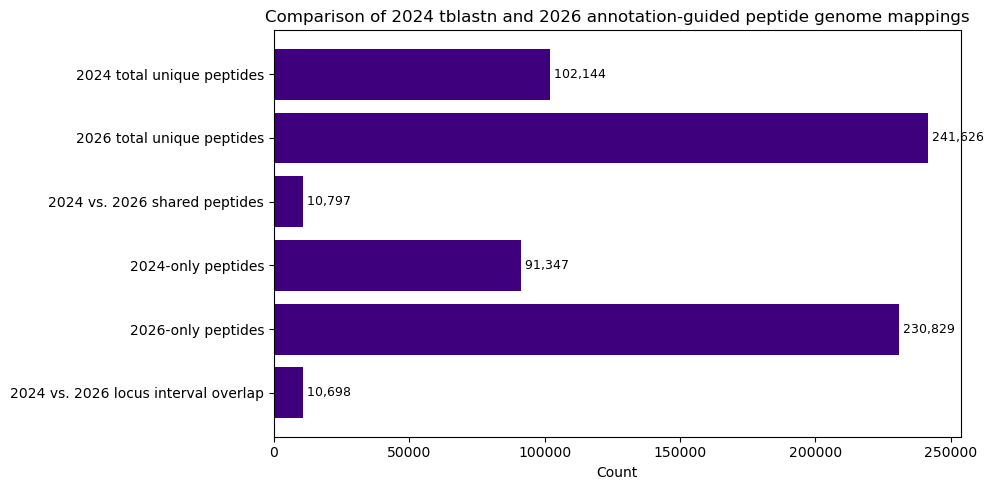

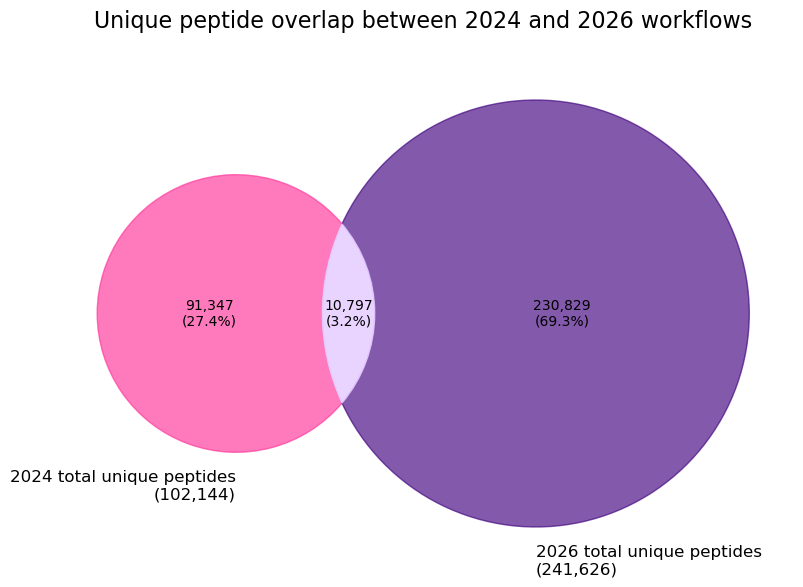

Venn diagram saved: python_outputs\figures\step24_2024_vs_2026_unique_peptide_overlap_venn.png

Summary saved: python_outputs\tables\wheat_2024_vs_2026_peptide_genome_mapping_comparison_summary_step24.csv
Peptide overlap table saved: python_outputs\tables\wheat_2024_vs_2026_peptide_sequence_overlap_step24.csv
Exact coordinate matches saved: python_outputs\tables\wheat_2024_vs_2026_exact_coordinate_matches_step24.csv
Locus interval overlaps saved: python_outputs\tables\wheat_2024_vs_2026_locus_interval_overlaps_step24.csv
Figure saved: python_outputs\figures\step24_2024_vs_2026_peptide_mapping_comparison.png


,Comparison_level,Metric,Value
0,BED rows,2024 tblastn BED rows,106321.00
1,BED rows,"2026 annotation-projected BED rows, non-redundant",2012539.00
2,Peptide sequences,Unique peptides in 2024,102144.00
3,Peptide sequences,Unique peptides in 2026,241626.00
4,Peptide sequences,Shared unique peptides,10797.00
5,Peptide sequences,Peptides only in 2024,91347.00
6,Peptide sequences,Peptides only in 2026,230829.00
7,Peptide sequences,Percent of 2024 peptides recovered in 2026,10.57
8,Peptide sequences,Percent of 2026 peptides already present in 2024,4.47
9,Locus interval overlap,2024 BED rows with at least one overlapping 20...,10698.00


,Category,Count
0,2024 total unique peptides,102144
1,2026 total unique peptides,241626
2,2024 vs. 2026 shared peptides,10797
3,2024-only peptides,91347
4,2026-only peptides,230829
5,2024 vs. 2026 locus interval overlap,10698


In [6]:
# ============================================================
# Step 24 — Compare 2024 tblastn BED6 alignments with 2026 annotation-guided BED6 projections (takes 45 min)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

# -----------------------------
# 1. Input / output paths
# -----------------------------
bed_dir = Path("python_outputs/bed")
tables_dir = Path("python_outputs/tables")
figures_dir = Path("python_outputs/figures")

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

bed_2024_file = Path(
    "tblastn-results/Vincent-Appels_wheat-all-tissues_projected-peptides_tblastn-proteogenomics_20240520.BED"
)

current_sources = ["MSV000090572", "PXD004720"]

current_nonredundant_bed_out = bed_dir / "Vincent_2026_MSV000090572_PXD004720_nonredundant_projected_peptides_annotation_proteogenomics_step24.bed6"

summary_out = tables_dir / "wheat_2024_vs_2026_peptide_genome_mapping_comparison_summary_step24.csv"
peptide_overlap_out = tables_dir / "wheat_2024_vs_2026_peptide_sequence_overlap_step24.csv"
exact_match_out = tables_dir / "wheat_2024_vs_2026_exact_coordinate_matches_step24.csv"
locus_overlap_out = tables_dir / "wheat_2024_vs_2026_locus_interval_overlaps_step24.csv"

figure_out = figures_dir / "step24_2024_vs_2026_peptide_mapping_comparison.png"

# -----------------------------
# 2. Helper functions
# -----------------------------
bed_cols = ["Chromosome", "Start", "End", "Name", "Score", "Strand"]

def read_bed6(path):
    """
    Read a BED6 file safely.
    """
    data = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=bed_cols,
        comment="#",
        low_memory=False
    )

    data["Start"] = pd.to_numeric(data["Start"], errors="coerce")
    data["End"] = pd.to_numeric(data["End"], errors="coerce")

    data = data.dropna(subset=["Chromosome", "Start", "End", "Name", "Strand"]).copy()

    data["Start"] = data["Start"].astype(int)
    data["End"] = data["End"].astype(int)
    data["Chromosome"] = data["Chromosome"].astype(str)
    data["Name"] = data["Name"].astype(str)
    data["Strand"] = data["Strand"].astype(str)

    return data


def normalise_peptide_from_bed_name(name):
    """
    Extract and normalise peptide sequence from BED name field.

    Handles:
    - 2024 BED names containing peptide sequence only
    - 2026 BED names formatted as peptide|protein|...
    - intron-gapped peptide labels containing dashes
    - I/L normalisation for proteomics sequence matching
    """
    name = str(name)

    # If current BED name contains pipes, peptide sequence is expected first
    peptide = name.split("|")[0]

    # Remove intron display dashes and non-amino-acid characters
    peptide = peptide.replace("-", "")
    peptide = re.sub(r"[^A-Z]", "", peptide.upper())

    # Normalise I/L because MS/MS commonly cannot distinguish isoleucine and leucine
    peptide = peptide.replace("I", "L")

    return peptide


def add_comparison_fields(data, source_label):
    data = data.copy()

    data["Source_workflow"] = source_label
    data["Peptide_clean"] = data["Name"].apply(normalise_peptide_from_bed_name)

    data["Exact_key"] = (
        data["Chromosome"].astype(str) + "|" +
        data["Start"].astype(str) + "|" +
        data["End"].astype(str) + "|" +
        data["Strand"].astype(str) + "|" +
        data["Peptide_clean"].astype(str)
    )

    data["Locus_key"] = (
        data["Chromosome"].astype(str) + "|" +
        data["Strand"].astype(str) + "|" +
        data["Peptide_clean"].astype(str)
    )

    data["Interval_length_nt"] = data["End"] - data["Start"]

    return data


def find_current_bed6_files(bed_dir, sources):
    """
    Find current BED6 peptide files from selected sources only.
    """
    all_bed_files = (
        list(bed_dir.glob("*.bed6")) +
        list(bed_dir.glob("*.BED6")) +
        list(bed_dir.glob("*.bed")) +
        list(bed_dir.glob("*.BED"))
    )

    selected = []

    for path in all_bed_files:
        name = path.name

        if any(source in name for source in sources):
            if name.lower().endswith((".bed6", ".bed")):
                selected.append(path)

    selected = sorted(set(selected))

    return selected

    
def interval_overlap(a_start, a_end, b_start, b_end):
    """
    BED intervals are 0-based, half-open.
    Overlap exists if max(start) < min(end).
    """
    return max(a_start, b_start) < min(a_end, b_end)


# -----------------------------
# 3. Load 2024 tblastn BED6 file
# -----------------------------
if not bed_2024_file.exists():
    raise FileNotFoundError(
        f"2024 BED file not found:\n{bed_2024_file}\n\n"
        "Check that the file is located in the tblastn-results folder."
    )

bed_2024 = read_bed6(bed_2024_file)
bed_2024 = add_comparison_fields(bed_2024, "2024_tblastn")

print("2024 tblastn BED loaded")
print(f"Rows: {len(bed_2024):,}")
print(f"Unique peptides: {bed_2024['Peptide_clean'].nunique():,}")

# -----------------------------
# 4. Combine current 2026 BED6 files for shared sources only
# -----------------------------
current_bed_files = find_current_bed6_files(bed_dir, current_sources)

if len(current_bed_files) == 0:
    raise FileNotFoundError(
        "No current BED6/BED files found for MSV000090572 or PXD004720. "
        "Check filenames in python_outputs/bed."
    )

print("\nCurrent 2026 BED files selected:")
for path in current_bed_files:
    print(f" - {path}")

current_bed_parts = []

for path in current_bed_files:
    data = read_bed6(path)
    data["Input_BED_file"] = path.name
    current_bed_parts.append(data)

bed_2026 = pd.concat(current_bed_parts, ignore_index=True)
bed_2026 = add_comparison_fields(bed_2026, "2026_annotation_projection")

# Non-redundant current BED6 based on exact BED6 fields
bed_2026_nr = (
    bed_2026
    .drop_duplicates(subset=["Chromosome", "Start", "End", "Name", "Score", "Strand"])
    .copy()
)

bed_2026_nr[bed_cols].to_csv(
    current_nonredundant_bed_out,
    sep="\t",
    header=False,
    index=False
)

print("\n2026 annotation-guided BED combined")
print(f"Rows before non-redundant filtering: {len(bed_2026):,}")
print(f"Rows after non-redundant filtering: {len(bed_2026_nr):,}")
print(f"Unique peptides: {bed_2026_nr['Peptide_clean'].nunique():,}")
print(f"Saved non-redundant BED6: {current_nonredundant_bed_out}")

# -----------------------------
# 5. Peptide sequence overlap
# -----------------------------
peptides_2024 = set(bed_2024["Peptide_clean"].dropna())
peptides_2026 = set(bed_2026_nr["Peptide_clean"].dropna())

shared_peptides = peptides_2024 & peptides_2026
only_2024_peptides = peptides_2024 - peptides_2026
only_2026_peptides = peptides_2026 - peptides_2024

peptide_overlap = pd.DataFrame({
    "Peptide_clean": sorted(peptides_2024 | peptides_2026)
})

peptide_overlap["In_2024_tblastn"] = peptide_overlap["Peptide_clean"].isin(peptides_2024)
peptide_overlap["In_2026_annotation_projection"] = peptide_overlap["Peptide_clean"].isin(peptides_2026)

peptide_overlap["Overlap_class"] = peptide_overlap.apply(
    lambda row:
        "shared" if row["In_2024_tblastn"] and row["In_2026_annotation_projection"]
        else "2024_only" if row["In_2024_tblastn"]
        else "2026_only",
    axis=1
)

peptide_overlap.to_csv(peptide_overlap_out, index=False)

# -----------------------------
# 6. Locus-level interval overlap
# -----------------------------
# This tests whether the same peptide overlaps the same chromosomal locus
# on the same strand, even if exact start/end differ.

current_groups = {
    key: group[["Chromosome", "Start", "End", "Strand", "Name", "Score", "Peptide_clean"]].copy()
    for key, group in bed_2026_nr.groupby("Locus_key", observed=True)
}

locus_overlap_records = []

for row in bed_2024.itertuples(index=False):

    candidates = current_groups.get(row.Locus_key)

    if candidates is None:
        continue

    overlapping = candidates[
        candidates.apply(
            lambda x: interval_overlap(row.Start, row.End, x["Start"], x["End"]),
            axis=1
        )
    ]

    if overlapping.empty:
        continue

    for current_row in overlapping.itertuples(index=False):

        overlap_start = max(row.Start, current_row.Start)
        overlap_end = min(row.End, current_row.End)
        overlap_nt = overlap_end - overlap_start

        locus_overlap_records.append({
            "Peptide_clean": row.Peptide_clean,
            "Chromosome": row.Chromosome,
            "Strand": row.Strand,
            "Start_2024": row.Start,
            "End_2024": row.End,
            "Name_2024": row.Name,
            "Score_2024": row.Score,
            "Start_2026": current_row.Start,
            "End_2026": current_row.End,
            "Name_2026": current_row.Name,
            "Score_2026": current_row.Score,
            "Overlap_nt": overlap_nt,
            "Interval_length_2024_nt": row.End - row.Start,
            "Interval_length_2026_nt": current_row.End - current_row.Start,
            "Reciprocal_overlap_2024_percent": round(
                (overlap_nt / (row.End - row.Start)) * 100, 2
            ) if (row.End - row.Start) > 0 else pd.NA,
            "Reciprocal_overlap_2026_percent": round(
                (overlap_nt / (current_row.End - current_row.Start)) * 100, 2
            ) if (current_row.End - current_row.Start) > 0 else pd.NA
        })

locus_overlaps = pd.DataFrame(locus_overlap_records)

if not locus_overlaps.empty:
    locus_overlaps.to_csv(locus_overlap_out, index=False)
else:
    pd.DataFrame(columns=[
        "Peptide_clean", "Chromosome", "Strand",
        "Start_2024", "End_2024", "Start_2026", "End_2026"
    ]).to_csv(locus_overlap_out, index=False)

# -----------------------------
# 7. Summary table
# -----------------------------
summary_records = [
    {
        "Comparison_level": "BED rows",
        "Metric": "2024 tblastn BED rows",
        "Value": len(bed_2024)
    },
    {
        "Comparison_level": "BED rows",
        "Metric": "2026 annotation-projected BED rows, non-redundant",
        "Value": len(bed_2026_nr)
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Unique peptides in 2024",
        "Value": len(peptides_2024)
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Unique peptides in 2026",
        "Value": len(peptides_2026)
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Shared unique peptides",
        "Value": len(shared_peptides)
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Peptides only in 2024",
        "Value": len(only_2024_peptides)
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Peptides only in 2026",
        "Value": len(only_2026_peptides)
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Percent of 2024 peptides recovered in 2026",
        "Value": round((len(shared_peptides) / len(peptides_2024)) * 100, 2) if len(peptides_2024) > 0 else pd.NA
    },
    {
        "Comparison_level": "Peptide sequences",
        "Metric": "Percent of 2026 peptides already present in 2024",
        "Value": round((len(shared_peptides) / len(peptides_2026)) * 100, 2) if len(peptides_2026) > 0 else pd.NA
    },
    {
        "Comparison_level": "Locus interval overlap",
        "Metric": "2024 BED rows with at least one overlapping 2026 locus",
        "Value": locus_overlaps[["Peptide_clean", "Chromosome", "Strand", "Start_2024", "End_2024"]].drop_duplicates().shape[0] if not locus_overlaps.empty else 0
    },
    {
        "Comparison_level": "Locus interval overlap",
        "Metric": "Total 2024-vs-2026 overlapping interval pairs",
        "Value": len(locus_overlaps)
    }
]

summary = pd.DataFrame(summary_records)
summary.to_csv(summary_out, index=False)

# -----------------------------
# 8. Figure: comparison overview
# -----------------------------
plot_data = pd.DataFrame({
    "Category": [
        "2024 total unique peptides",
        "2026 total unique peptides",
        "2024 vs. 2026 shared peptides",
        "2024-only peptides",
        "2026-only peptides",
        "2024 vs. 2026 locus interval overlap"
    ],
    "Count": [
        len(peptides_2024),
        len(peptides_2026),
        len(shared_peptides),
        len(only_2024_peptides),
        len(only_2026_peptides),
        locus_overlaps[[
            "Peptide_clean", "Chromosome", "Strand", "Start_2024", "End_2024"
        ]].drop_duplicates().shape[0] if not locus_overlaps.empty else 0
    ]
})

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    plot_data["Category"],
    plot_data["Count"],
    color="#3F007E"
)

ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Comparison of 2024 tblastn and 2026 annotation-guided peptide genome mappings")

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width):,}",
        va="center",
        ha="left",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    figure_out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# -----------------------------
# 9. Venn diagram: unique peptide overlap
# -----------------------------

try:
    from matplotlib_venn import venn2

    venn_figure_out = figures_dir / "step24_2024_vs_2026_unique_peptide_overlap_venn.png"

    n_2024_only = len(only_2024_peptides)
    n_2026_only = len(only_2026_peptides)
    n_shared = len(shared_peptides)

    n_2024_total = len(peptides_2024)
    n_2026_total = len(peptides_2026)
    n_union = len(peptides_2024 | peptides_2026)

    pct_2024_only = (n_2024_only / n_union) * 100
    pct_2026_only = (n_2026_only / n_union) * 100
    pct_shared = (n_shared / n_union) * 100

    fig, ax = plt.subplots(figsize=(9, 6))

    venn = venn2(
        subsets=(n_2024_only, n_2026_only, n_shared),
        set_labels=(
            f"2024 total unique peptides\n({n_2024_total:,})",
            f"2026 total unique peptides\n({n_2026_total:,})"
        ),
        ax=ax
    )

    # Colours
    if venn.get_patch_by_id("10") is not None:
        venn.get_patch_by_id("10").set_color("#FF3399")
        venn.get_patch_by_id("10").set_alpha(0.65)

    if venn.get_patch_by_id("01") is not None:
        venn.get_patch_by_id("01").set_color("#3F007E")
        venn.get_patch_by_id("01").set_alpha(0.65)

    if venn.get_patch_by_id("11") is not None:
        venn.get_patch_by_id("11").set_color("#E6CDFF")
        venn.get_patch_by_id("11").set_alpha(0.85)

    # Labels with counts and percentages
    label_10 = venn.get_label_by_id("10")
    if label_10 is not None:
        label_10.set_text(f"{n_2024_only:,}\n({pct_2024_only:.1f}%)")

    label_01 = venn.get_label_by_id("01")
    if label_01 is not None:
        label_01.set_text(f"{n_2026_only:,}\n({pct_2026_only:.1f}%)")

    label_11 = venn.get_label_by_id("11")
    if label_11 is not None:
        label_11.set_text(f"{n_shared:,}\n({pct_shared:.1f}%)")

    ax.set_title(
        "Unique peptide overlap between 2024 and 2026 workflows",
        fontsize=16,
        pad=20
    )

    plt.tight_layout()

    plt.savefig(
        venn_figure_out,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Venn diagram saved: {venn_figure_out}")

except ImportError:
    print(
        "matplotlib-venn is not installed. "
        "Install it with: pip install matplotlib-venn"
    )

# -----------------------------
# 10. Display outputs
# -----------------------------
print(f"\nSummary saved: {summary_out}")
print(f"Peptide overlap table saved: {peptide_overlap_out}")
print(f"Exact coordinate matches saved: {exact_match_out}")
print(f"Locus interval overlaps saved: {locus_overlap_out}")
print(f"Figure saved: {figure_out}")

display(summary)
display(plot_data)

# Step 25 — Sanity Checks for Annotation-Guided Peptide Genome Projections

This step performs final quality-control checks on the projected peptide genome coordinates before public upload to Apollo/JBrowse.

The aim is to verify that the annotation-guided peptide projections generated in Step 9 are internally consistent and suitable for genome-browser visualisation.

---

Three independent sanity checks are performed:

1. **BED geometry check**  
   Confirms that BED coordinates are valid, that start coordinates are smaller than end coordinates, and that BED block sizes and block starts are consistent with each peptide genomic interval.

2. **Chromosome and strand check**  
   Confirms that projected peptides are assigned only to expected wheat chromosomes and valid strand values (`+` or `-`).

3. **Protein-coordinate consistency check**  
   Confirms that each peptide projection has coherent amino-acid coordinates, including matching peptide length and valid protein coordinate intervals.

For each projected peptide row, the workflow records pass/fail flags for each check and assigns an overall sanity-check status.

---

The outputs include:

- a full sanity-check table for all projected peptide rows,
- a failed-row diagnostic table,
- a tissue-level sanity-check summary table.

---

These checks provide an additional safeguard before sharing the BED tracks as a public genome-browser resource.

In [7]:
# ============================================================
# Step 25 — Sanity checks for annotation-guided peptide genome projections (takes 30 min)
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
fragpipe_dir = Path("FragPipe_results")
tables_dir = Path("python_outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

manifest_file = fragpipe_dir / "wheat_tissues_FragPipe-result-manifest_2026-05-11.csv"

sanity_full_out = tables_dir / "wheat_projection_sanity_checks_full_step25.csv"
sanity_failed_out = tables_dir / "wheat_projection_sanity_checks_failed_rows_step25.csv"
sanity_summary_out = tables_dir / "wheat_projection_sanity_checks_summary_step25.csv"

manifest = pd.read_csv(manifest_file, encoding="utf-8-sig")

# -----------------------------
# 2. Expected wheat chromosomes and valid strands
# -----------------------------
valid_chromosomes = {
    "Chr1A", "Chr1B", "Chr1D",
    "Chr2A", "Chr2B", "Chr2D",
    "Chr3A", "Chr3B", "Chr3D",
    "Chr4A", "Chr4B", "Chr4D",
    "Chr5A", "Chr5B", "Chr5D",
    "Chr6A", "Chr6B", "Chr6D",
    "Chr7A", "Chr7B", "Chr7D"
}

valid_strands = {"+", "-"}

# -----------------------------
# 3. Helper functions
# -----------------------------
def parse_bed_list(value):
    """
    Convert comma-separated BED block size/start strings into integer lists.
    Handles empty or missing values.
    """
    if pd.isna(value):
        return []

    value = str(value).strip().strip(",")

    if value == "":
        return []

    try:
        return [int(x) for x in value.split(",") if str(x).strip() != ""]
    except ValueError:
        return []


def check_bed_geometry(row):
    """
    Check BED interval and BED12-style block geometry.
    """
    try:
        bed_start = int(row["BED_start_0based"])
        bed_end = int(row["BED_end_0based_exclusive"])
        block_count = int(row["BED_block_count"])
    except Exception:
        return False

    if bed_start < 0:
        return False

    if bed_end <= bed_start:
        return False

    block_sizes = parse_bed_list(row["BED_block_sizes"])
    block_starts = parse_bed_list(row["BED_block_starts"])

    if block_count <= 0:
        return False

    if len(block_sizes) != block_count:
        return False

    if len(block_starts) != block_count:
        return False

    if any(size <= 0 for size in block_sizes):
        return False

    if any(start < 0 for start in block_starts):
        return False

    interval_length = bed_end - bed_start

    # Every block must fit inside the BED interval
    for block_start, block_size in zip(block_starts, block_sizes):
        if block_start + block_size > interval_length:
            return False

    return True


def check_block_nt_length(row):
    """
    Check that the sum of BED block nucleotide lengths matches peptide length × 3.
    """
    try:
        peptide_len = int(row["Peptide_length_AA"])
    except Exception:
        return False

    block_sizes = parse_bed_list(row["BED_block_sizes"])

    if len(block_sizes) == 0:
        return False

    return sum(block_sizes) == peptide_len * 3


def check_chromosome_and_strand(row):
    """
    Check valid chromosome and strand assignment.
    """
    chrom = str(row["Chromosome"])
    strand = str(row["Strand"])

    return chrom in valid_chromosomes and strand in valid_strands


def check_protein_coordinates(row):
    """
    Check that amino-acid coordinates are internally consistent with peptide length.
    """
    try:
        aa_start = int(row["AA_start"])
        aa_end = int(row["AA_end"])
        peptide_len = int(row["Peptide_length_AA"])
    except Exception:
        return False

    if aa_start <= 0:
        return False

    if aa_end < aa_start:
        return False

    if (aa_end - aa_start + 1) != peptide_len:
        return False

    peptide = str(row["Peptide"])

    if len(peptide) != peptide_len:
        return False

    return True


# -----------------------------
# 4. Run sanity checks across all projected peptide tables
# -----------------------------
all_checked = []
summary_records = []

for _, manifest_row in manifest.iterrows():

    source = manifest_row["Source"]
    species = manifest_row["Species"]
    tissue = manifest_row["Tissue-Raw-Code"]
    batch = manifest_row["Batch"]

    projection_filename = manifest_row["FragPipe-Output-Peptide"].replace(
        "_peptide.tsv",
        "_peptide_genome_projection.csv"
    )

    projection_path = tables_dir / projection_filename

    if not projection_path.exists():
        print(f"Projection file not found, skipped: {projection_path}")
        continue

    data = pd.read_csv(projection_path, low_memory=False)

    # Keep only successfully projected rows
    projected = data[data["Projection_status"] == "projected"].copy()

    if projected.empty:
        print(f"No projected rows found in: {projection_path}")
        continue

    projected["Source"] = source
    projected["Species"] = species
    projected["Tissue"] = tissue
    projected["Batch"] = batch
    projected["Projection_file"] = projection_filename

    # Sanity checks
    projected["Check_BED_geometry"] = projected.apply(check_bed_geometry, axis=1)
    projected["Check_block_nt_length"] = projected.apply(check_block_nt_length, axis=1)
    projected["Check_chromosome_and_strand"] = projected.apply(check_chromosome_and_strand, axis=1)
    projected["Check_protein_coordinates"] = projected.apply(check_protein_coordinates, axis=1)

    check_cols = [
        "Check_BED_geometry",
        "Check_block_nt_length",
        "Check_chromosome_and_strand",
        "Check_protein_coordinates"
    ]

    projected["All_sanity_checks_passed"] = projected[check_cols].all(axis=1)

    projected["Sanity_check_status"] = projected["All_sanity_checks_passed"].map({
        True: "passed",
        False: "failed"
    })

    failed = projected[~projected["All_sanity_checks_passed"]]

    summary_records.append({
        "Source": source,
        "Species": species,
        "Tissue": tissue,
        "Batch": batch,
        "Projection_file": projection_filename,
        "Projected_rows_checked": len(projected),
        "Rows_passing_all_sanity_checks": int(projected["All_sanity_checks_passed"].sum()),
        "Rows_failing_any_sanity_check": int((~projected["All_sanity_checks_passed"]).sum()),
        "Percent_passing_all_sanity_checks": round(
            projected["All_sanity_checks_passed"].mean() * 100, 4
        ),
        "BED_geometry_failures": int((~projected["Check_BED_geometry"]).sum()),
        "Block_nt_length_failures": int((~projected["Check_block_nt_length"]).sum()),
        "Chromosome_strand_failures": int((~projected["Check_chromosome_and_strand"]).sum()),
        "Protein_coordinate_failures": int((~projected["Check_protein_coordinates"]).sum())
    })

    print(
        f"{source} | {tissue}: "
        f"{projected['All_sanity_checks_passed'].sum():,} / {len(projected):,} passed"
    )

    all_checked.append(projected)

# -----------------------------
# 5. Combine and export outputs
# -----------------------------
if len(all_checked) == 0:
    raise ValueError("No projected peptide rows were available for sanity checking.")

sanity_full = pd.concat(all_checked, ignore_index=True)
sanity_summary = pd.DataFrame(summary_records)

sanity_failed = sanity_full[
    sanity_full["Sanity_check_status"] == "failed"
].copy()

sanity_full.to_csv(sanity_full_out, index=False)
sanity_failed.to_csv(sanity_failed_out, index=False)
sanity_summary.to_csv(sanity_summary_out, index=False)

# -----------------------------
# 6. Overall summary
# -----------------------------
overall_checked = len(sanity_full)
overall_passed = int(sanity_full["All_sanity_checks_passed"].sum())
overall_failed = overall_checked - overall_passed
overall_pass_percent = round((overall_passed / overall_checked) * 100, 4)

print("\n===== STEP 25 SANITY CHECK SUMMARY =====")
print(f"Projected rows checked: {overall_checked:,}")
print(f"Rows passing all sanity checks: {overall_passed:,}")
print(f"Rows failing at least one sanity check: {overall_failed:,}")
print(f"Overall pass rate: {overall_pass_percent}%")

print(f"\nFull sanity-check table saved: {sanity_full_out}")
print(f"Failed-row diagnostic table saved: {sanity_failed_out}")
print(f"Tissue-level sanity summary saved: {sanity_summary_out}")

display(sanity_summary)
display(sanity_failed.head(20))

MSV000090572 | stored_grain: 29,836 / 30,314 passed
PXD050500 | coleoptile: 1,832,405 / 1,850,136 passed
PXD050500 | node: 1,868,501 / 1,886,922 passed
PXD050500 | radicle: 1,052,392 / 1,062,508 passed
PXD004720 | anther: 162,834 / 164,365 passed
PXD004720 | boot: 13,114 / 13,227 passed
PXD004720 | coleoptile: 202,433 / 204,476 passed
PXD004720 | embryo: 8,769 / 8,852 passed
PXD004720 | endosperm: 101,946 / 102,830 passed
PXD004720 | glume: 143,464 / 145,133 passed
PXD004720 | grain-zadoks-70: 125,070 / 126,195 passed
PXD004720 | grain-zadoks-71: 178,286 / 179,725 passed
PXD004720 | grain-zadoks-75: 131,666 / 132,701 passed
PXD004720 | grain-zadoks-83: 112,128 / 113,203 passed
PXD004720 | grain-zadoks-87: 110,874 / 111,792 passed
PXD004720 | leaf-flag-mature: 144,063 / 145,632 passed
PXD004720 | leaf-flag-senescing: 45,551 / 46,200 passed
PXD004720 | leaf-flag-young: 119,463 / 120,821 passed
PXD004720 | lemma: 146,124 / 147,618 passed
PXD004720 | node: 98,604 / 99,823 passed
PXD004720 

,Source,Species,Tissue,Batch,Projection_file,Projected_rows_checked,Rows_passing_all_sanity_checks,Rows_failing_any_sanity_check,Percent_passing_all_sanity_checks,BED_geometry_failures,Block_nt_length_failures,Chromosome_strand_failures,Protein_coordinate_failures
0,MSV000090572,bread wheat,stored_grain,single,FragPipe_Vincent_MSV000090572_stored-grain_pep...,30314,29836,478,98.4232,0,0,478,0
1,PXD050500,bread wheat,coleoptile,single,FragPipe_Liu_PXD050500_coleoptile_peptide_geno...,1850136,1832405,17731,99.0416,0,0,17731,0
2,PXD050500,bread wheat,node,single,FragPipe_Liu_PXD050500_node_peptide_genome_pro...,1886922,1868501,18421,99.0238,0,0,18421,0
3,PXD050500,bread wheat,radicle,single,FragPipe_Liu_PXD050500_radicle_peptide_genome_...,1062508,1052392,10116,99.0479,0,0,10116,0
4,PXD004720,bread wheat,anther,single,FragPipe_Duncan_PXD004720_anther_peptide_genom...,164365,162834,1531,99.0685,0,0,1531,0
5,PXD004720,bread wheat,boot,single,FragPipe_Duncan_PXD004720_boot_peptide_genome_...,13227,13114,113,99.1457,0,0,113,0
6,PXD004720,bread wheat,coleoptile,single,FragPipe_Duncan_PXD004720_coleoptile_peptide_g...,204476,202433,2043,99.0009,0,0,2043,0
7,PXD004720,bread wheat,embryo,single,FragPipe_Duncan_PXD004720_embryo_peptide_genom...,8852,8769,83,99.0624,0,0,83,0
8,PXD004720,bread wheat,endosperm,single,FragPipe_Duncan_PXD004720_endosperm_peptide_ge...,102830,101946,884,99.1403,0,0,884,0
9,PXD004720,bread wheat,glume,single,FragPipe_Duncan_PXD004720_glume_peptide_genome...,145133,143464,1669,98.8500,0,0,1669,0


,Index,Source,Species,Tissue,Batch,Peptide,ProteinID,Protein_mapping_type,Contaminant,Probability,...,BED_block_sizes,BED_block_starts,Projection_status,Projection_file,Check_BED_geometry,Check_block_nt_length,Check_chromosome_and_strand,Check_protein_coordinates,All_sanity_checks_passed,Sanity_check_status
354,355,MSV000090572,bread wheat,stored_grain,single,AAVFRWIHGLLKEMK,TraesCSU03G0412800LC.1,primary,no,0.0598,...,45,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
485,486,MSV000090572,bread wheat,stored_grain,single,ADIMESSTDQNF,TraesCSU03G0471100LC.1,mapped,no,0.9703,...,36,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
520,521,MSV000090572,bread wheat,stored_grain,single,ADNLYWEGFK,TraesCSU03G0261100.1,mapped,no,0.9970,...,30,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
521,522,MSV000090572,bread wheat,stored_grain,single,ADNLYWEGFK,TraesCSU03G0261300.1,mapped,no,0.9970,...,30,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
561,562,MSV000090572,bread wheat,stored_grain,single,ADVEAPDDDAEAEVRVDVETGDAAVKGGAPVMKR,TraesCSU03G0110900.1,primary,no,0.3168,...,102,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
641,642,MSV000090572,bread wheat,stored_grain,single,AEHLASIFGTEK,TraesCSU03G0077400LC.1,mapped,no,0.1075,...,36,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
642,643,MSV000090572,bread wheat,stored_grain,single,AEHLASIFGTEK,TraesCSU03G0540200LC.1,mapped,no,0.1075,...,36,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
643,644,MSV000090572,bread wheat,stored_grain,single,AEHLASIFGTEK,TraesCSU03G0553300LC.1,mapped,no,0.1075,...,36,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
929,930,MSV000090572,bread wheat,stored_grain,single,AGLASARELR,TraesCSU03G0085200.1,mapped,no,0.6766,...,30,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed
930,931,MSV000090572,bread wheat,stored_grain,single,AGLASARELR,TraesCSU03G0085200.2,mapped,no,0.6766,...,30,0,projected,FragPipe_Vincent_MSV000090572_stored-grain_pep...,True,True,False,True,False,failed


# Step 26 — Generate Sanity-Validated BED Files for Apollo/JBrowse Upload

This step creates a final set of Apollo/JBrowse BED files containing only peptide genome projections that passed the Step 25 sanity checks.

---

Rows failing any of the following checks are excluded:

- BED geometry validity
- BED block nucleotide length consistency
- chromosome and strand validity
- protein-coordinate consistency

---

The original BED files are preserved unchanged. Filtered versions are written to a new upload-ready directory:

`python_outputs/bed_Apollo_validated/`

---

These validated BED files should be used for public upload to Apollo/JBrowse.

In [11]:
# ============================================================
# Step 26 — Generate sanity-validated BED files for Apollo/JBrowse upload (takes 7 min)
# Memory-light version using failed-row exclusion
# ============================================================

import pandas as pd
from pathlib import Path
import re

# -----------------------------
# 1. Input / output paths
# -----------------------------
bed_apollo_dir = Path("python_outputs/bed_Apollo")
validated_bed_dir = Path("python_outputs/bed_Apollo_validated")
tables_dir = Path("python_outputs/tables")

validated_bed_dir.mkdir(parents=True, exist_ok=True)

sanity_failed_file = tables_dir / "wheat_projection_sanity_checks_failed_rows_step25.csv"

summary_out = tables_dir / "wheat_validated_bed_filtering_summary_step26.csv"

# -----------------------------
# 2. Helper functions
# -----------------------------
def clean_peptide_from_bed_name(name):
    name = str(name)
    peptide = name.split("|")[0]
    peptide = peptide.replace("-", "")
    peptide = re.sub(r"[^A-Z]", "", peptide.upper())
    peptide = peptide.replace("I", "L")
    return peptide


def make_key(chrom, start, end, strand, peptide):
    return (
        chrom.astype(str) + "|" +
        start.astype(str) + "|" +
        end.astype(str) + "|" +
        strand.astype(str) + "|" +
        peptide.astype(str)
    )


# -----------------------------
# 3. Build failed-key set from Step 25 failed rows only
# -----------------------------
failed_keys = set()

if sanity_failed_file.exists():

    failed_usecols = [
        "Chromosome",
        "BED_start_0based",
        "BED_end_0based_exclusive",
        "Strand",
        "Peptide"
    ]

    for chunk in pd.read_csv(
        sanity_failed_file,
        usecols=lambda col: col in failed_usecols,
        chunksize=100_000,
        low_memory=True
    ):

        chunk = chunk.dropna(
            subset=[
                "Chromosome",
                "BED_start_0based",
                "BED_end_0based_exclusive",
                "Strand",
                "Peptide"
            ]
        ).copy()

        chunk["BED_start_0based"] = pd.to_numeric(
            chunk["BED_start_0based"],
            errors="coerce"
        )

        chunk["BED_end_0based_exclusive"] = pd.to_numeric(
            chunk["BED_end_0based_exclusive"],
            errors="coerce"
        )

        chunk = chunk.dropna(
            subset=["BED_start_0based", "BED_end_0based_exclusive"]
        ).copy()

        chunk["BED_start_0based"] = chunk["BED_start_0based"].astype(int)
        chunk["BED_end_0based_exclusive"] = chunk["BED_end_0based_exclusive"].astype(int)

        chunk["peptide_clean"] = (
            chunk["Peptide"]
            .astype(str)
            .str.replace("-", "", regex=False)
            .str.upper()
            .str.replace("I", "L", regex=False)
        )

        keys = make_key(
            chunk["Chromosome"],
            chunk["BED_start_0based"],
            chunk["BED_end_0based_exclusive"],
            chunk["Strand"],
            chunk["peptide_clean"]
        )

        failed_keys.update(keys.tolist())

else:
    print(f"No failed-row file found: {sanity_failed_file}")
    print("Proceeding with no failed keys.")

print(f"Failed projection keys loaded: {len(failed_keys):,}")

# -----------------------------
# 4. Find Apollo BED files without duplicates
# -----------------------------
bed_extensions = {".bed", ".bed6", ".bed12"}

bed_files = sorted({
    path.resolve()
    for path in bed_apollo_dir.iterdir()
    if path.is_file() and path.suffix.lower() in bed_extensions
})

bed_files = [Path(path) for path in bed_files]

if len(bed_files) == 0:
    raise FileNotFoundError(
        f"No BED files found in {bed_apollo_dir}. "
        "Check the Apollo BED output folder name."
    )

print(f"Unique BED files found: {len(bed_files)}")

# -----------------------------
# 5. Filter BED files in chunks
# -----------------------------
summary_records = []

for bed_file in bed_files:

    print(f"\nFiltering: {bed_file.name}")

    output_file = validated_bed_dir / bed_file.name

    # Clear existing output if rerunning
    if output_file.exists():
        output_file.unlink()

    original_rows_total = 0
    retained_rows_total = 0
    removed_rows_total = 0

    chunk_iter = pd.read_csv(
        bed_file,
        sep="\t",
        header=None,
        comment="#",
        dtype=str,
        chunksize=100_000,
        low_memory=True
    )

    for chunk_i, chunk in enumerate(chunk_iter, start=1):

        original_rows_total += len(chunk)

        if chunk.shape[1] < 6:
            print(f"Skipped chunk {chunk_i}: fewer than 6 BED columns.")
            continue

        chunk = chunk.rename(columns={
            0: "chrom",
            1: "start",
            2: "end",
            3: "name",
            4: "score",
            5: "strand"
        })

        chunk["start"] = pd.to_numeric(chunk["start"], errors="coerce")
        chunk["end"] = pd.to_numeric(chunk["end"], errors="coerce")

        chunk = chunk.dropna(
            subset=["chrom", "start", "end", "name", "strand"]
        ).copy()

        chunk["start"] = chunk["start"].astype(int)
        chunk["end"] = chunk["end"].astype(int)

        chunk["peptide_clean"] = chunk["name"].apply(clean_peptide_from_bed_name)

        chunk["validation_key"] = make_key(
            chunk["chrom"],
            chunk["start"],
            chunk["end"],
            chunk["strand"],
            chunk["peptide_clean"]
        )

        filtered = chunk[
            ~chunk["validation_key"].isin(failed_keys)
        ].copy()

        retained_rows_total += len(filtered)
        removed_rows_total += len(chunk) - len(filtered)

        filtered = filtered.drop(columns=["peptide_clean", "validation_key"])

        filtered = filtered.rename(columns={
            "chrom": 0,
            "start": 1,
            "end": 2,
            "name": 3,
            "score": 4,
            "strand": 5
        })

        filtered.to_csv(
            output_file,
            sep="\t",
            header=False,
            index=False,
            mode="a"
        )

    summary_records.append({
        "Input_BED_file": bed_file.name,
        "Original_rows": original_rows_total,
        "Retained_validated_rows": retained_rows_total,
        "Removed_failed_rows": removed_rows_total,
        "Percent_retained": round(
            (retained_rows_total / original_rows_total) * 100,
            4
        ) if original_rows_total > 0 else 0,
        "Output_BED_file": output_file.name
    })

    print(f"Original rows: {original_rows_total:,}")
    print(f"Retained rows: {retained_rows_total:,}")
    print(f"Removed failed rows: {removed_rows_total:,}")
    print(f"Saved: {output_file}")

# -----------------------------
# 6. Save summary
# -----------------------------
summary = pd.DataFrame(summary_records)
summary.to_csv(summary_out, index=False)

print("\n===== STEP 26 BED FILTERING SUMMARY =====")
print(f"BED files processed: {len(summary):,}")
print(f"Total original rows: {summary['Original_rows'].sum():,}")
print(f"Total retained rows: {summary['Retained_validated_rows'].sum():,}")
print(f"Total removed rows: {summary['Removed_failed_rows'].sum():,}")

print(f"\nValidated BED files saved in: {validated_bed_dir}")
print(f"Filtering summary saved: {summary_out}")

display(summary)

Failed projection keys loaded: 32,845
Unique BED files found: 64

Filtering: Vincent_MSV000090572_stored_grain_projected-peptides_annotation-proteogenomics_20260518.bed12
Original rows: 30,314
Retained rows: 29,836
Removed failed rows: 478
Saved: python_outputs\bed_Apollo_validated\Vincent_MSV000090572_stored_grain_projected-peptides_annotation-proteogenomics_20260518.bed12

Filtering: Vincent_MSV000090572_stored_grain_projected-peptides_annotation-proteogenomics_20260518.bed6
Original rows: 30,314
Retained rows: 29,836
Removed failed rows: 478
Saved: python_outputs\bed_Apollo_validated\Vincent_MSV000090572_stored_grain_projected-peptides_annotation-proteogenomics_20260518.bed6

Filtering: Vincent_PXD004720_anther_projected-peptides_annotation-proteogenomics_20260518.bed12
Original rows: 164,365
Retained rows: 162,834
Removed failed rows: 1,531
Saved: python_outputs\bed_Apollo_validated\Vincent_PXD004720_anther_projected-peptides_annotation-proteogenomics_20260518.bed12

Filtering: Vin

,Input_BED_file,Original_rows,Retained_validated_rows,Removed_failed_rows,Percent_retained,Output_BED_file
0,Vincent_MSV000090572_stored_grain_projected-pe...,30314,29836,478,98.4232,Vincent_MSV000090572_stored_grain_projected-pe...
1,Vincent_MSV000090572_stored_grain_projected-pe...,30314,29836,478,98.4232,Vincent_MSV000090572_stored_grain_projected-pe...
2,Vincent_PXD004720_anther_projected-peptides_an...,164365,162834,1531,99.0685,Vincent_PXD004720_anther_projected-peptides_an...
3,Vincent_PXD004720_anther_projected-peptides_an...,164365,162834,1531,99.0685,Vincent_PXD004720_anther_projected-peptides_an...
4,Vincent_PXD004720_boot_projected-peptides_anno...,13227,13114,113,99.1457,Vincent_PXD004720_boot_projected-peptides_anno...
...,...,...,...,...,...,...
59,Vincent_PXD050500_coleoptile_projected-peptide...,1850136,1832405,17731,99.0416,Vincent_PXD050500_coleoptile_projected-peptide...
60,Vincent_PXD050500_node_projected-peptides_anno...,1886922,1868501,18421,99.0238,Vincent_PXD050500_node_projected-peptides_anno...
61,Vincent_PXD050500_node_projected-peptides_anno...,1886922,1868501,18421,99.0238,Vincent_PXD050500_node_projected-peptides_anno...
62,Vincent_PXD050500_radicle_projected-peptides_a...,1062508,1052392,10116,99.0479,Vincent_PXD050500_radicle_projected-peptides_a...


# Step 27 — Create Non-Redundant Combined Validated BED Tracks

This step combines all sanity-validated Apollo/JBrowse BED files generated in Step 26 into single all-tissue BED6 and BED12 tracks.

Unlike simple exact-row deduplication, this version collapses visually identical BED features that differ only by BED score. This is important because the same peptide projection can be observed in multiple tissues or source datasets with different peptide probabilities, producing otherwise identical browser features with different scores.

For each duplicate visual feature, the maximum BED score is retained.

---

BED6 features are collapsed using:

- chromosome
- start
- end
- name
- strand

---

BED12 features are collapsed using:

- chromosome
- start
- end
- name
- strand
- thickStart
- thickEnd
- itemRgb
- blockCount
- blockSizes
- blockStarts

---

The resulting files provide compact non-redundant all-tissue tracks suitable for Apollo/JBrowse upload.

In [3]:
# ============================================================
# Step 27 — Create non-redundant combined validated BED tracks
# ============================================================

import pandas as pd
from pathlib import Path

# -----------------------------
# 1. Input / output paths
# -----------------------------
validated_bed_dir = Path("python_outputs/bed_Apollo_validated")
tables_dir = Path("python_outputs/tables")

tables_dir.mkdir(parents=True, exist_ok=True)

combined_bed6_out = validated_bed_dir / "Vincent_all-tissues_validated_projected-peptides_annotation-proteogenomics_20260518.bed6"
combined_bed12_out = validated_bed_dir / "Vincent_all-tissues_validated_projected-peptides_annotation-proteogenomics_20260518.bed12"

summary_out = tables_dir / "wheat_combined_validated_bed_summary_step27.csv"

# -----------------------------
# 2. Find validated BED files
# -----------------------------
bed_files = sorted({
    path.resolve()
    for path in validated_bed_dir.iterdir()
    if path.is_file() and path.suffix.lower() in {".bed6", ".bed12"}
})

bed_files = [Path(path) for path in bed_files]

# Exclude previous combined outputs if rerunning
bed_files = [
    path for path in bed_files
    if not path.name.startswith("Vincent_all-tissues_validated_projected-peptides")
]

if len(bed_files) == 0:
    raise FileNotFoundError(
        f"No validated BED6/BED12 files found in: {validated_bed_dir}"
    )

bed6_files = [path for path in bed_files if path.suffix.lower() == ".bed6"]
bed12_files = [path for path in bed_files if path.suffix.lower() == ".bed12"]

print(f"Validated BED6 files found: {len(bed6_files)}")
print(f"Validated BED12 files found: {len(bed12_files)}")

# -----------------------------
# 3. Helper function
# -----------------------------
def combine_bed_files_nonredundant(bed_file_list, output_file, expected_min_cols):
    """
    Combine BED files and remove visually duplicated BED features.

    Unlike exact row deduplication, this collapses rows that represent the
    same browser feature but have different BED scores, keeping the highest score.
    """

    combined_chunks = []
    input_row_count = 0

    for bed_file in bed_file_list:
        print(f"Reading: {bed_file.name}")

        data = pd.read_csv(
            bed_file,
            sep="\t",
            header=None,
            comment="#",
            low_memory=False
        )

        if data.shape[1] < expected_min_cols:
            print(f"  Skipped: fewer than {expected_min_cols} columns")
            continue

        data = data.iloc[:, :expected_min_cols].copy()
        input_row_count += len(data)
        combined_chunks.append(data)

    if len(combined_chunks) == 0:
        raise ValueError(f"No valid BED files available for: {output_file.name}")

    combined = pd.concat(combined_chunks, ignore_index=True)
    rows_before_dedup = len(combined)

    # Ensure coordinates and score are numeric
    combined[1] = pd.to_numeric(combined[1], errors="coerce")
    combined[2] = pd.to_numeric(combined[2], errors="coerce")
    combined[4] = pd.to_numeric(combined[4], errors="coerce").fillna(1000).astype(int)

    if expected_min_cols == 6:
        # BED6: chrom, start, end, name, score, strand
        dedup_cols = [0, 1, 2, 3, 5]

        combined = (
            combined
            .groupby(dedup_cols, dropna=False, as_index=False)
            .agg({4: "max"})
        )

        combined = combined[[0, 1, 2, 3, 4, 5]]

    elif expected_min_cols == 12:
        # BED12: collapse same feature/block structure, keep max score
        dedup_cols = [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11]

        combined = (
            combined
            .groupby(dedup_cols, dropna=False, as_index=False)
            .agg({4: "max"})
        )

        combined = combined[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]]

    else:
        raise ValueError("Only BED6 and BED12 are supported.")

    rows_after_dedup = len(combined)

    combined = (
        combined
        .sort_values(by=[0, 1, 2])
        .reset_index(drop=True)
    )

    # Restore integer coordinate display
    for col in [1, 2, 4]:
        combined[col] = combined[col].astype("Int64").astype(str)

    if expected_min_cols == 12:
        for col in [6, 7, 9]:
            combined[col] = pd.to_numeric(combined[col], errors="coerce").astype("Int64").astype(str)

    combined.to_csv(
        output_file,
        sep="\t",
        header=False,
        index=False
    )

    return {
        "Output_file": output_file.name,
        "Input_files": len(bed_file_list),
        "Input_rows_total": input_row_count,
        "Rows_before_deduplication": rows_before_dedup,
        "Rows_after_deduplication": rows_after_dedup,
        "Duplicate_rows_removed": rows_before_dedup - rows_after_dedup
    }

# -----------------------------
# 4. Combine BED6 files
# -----------------------------
summary_records = []

if len(bed6_files) > 0:
    bed6_summary = combine_bed_files_nonredundant(
        bed_file_list=bed6_files,
        output_file=combined_bed6_out,
        expected_min_cols=6
    )
    bed6_summary["BED_format"] = "BED6"
    summary_records.append(bed6_summary)

# -----------------------------
# 5. Combine BED12 files
# -----------------------------
if len(bed12_files) > 0:
    bed12_summary = combine_bed_files_nonredundant(
        bed_file_list=bed12_files,
        output_file=combined_bed12_out,
        expected_min_cols=12
    )
    bed12_summary["BED_format"] = "BED12"
    summary_records.append(bed12_summary)

# -----------------------------
# 6. Save summary
# -----------------------------
summary = pd.DataFrame(summary_records)

summary = summary[
    [
        "BED_format",
        "Output_file",
        "Input_files",
        "Input_rows_total",
        "Rows_before_deduplication",
        "Rows_after_deduplication",
        "Duplicate_rows_removed"
    ]
]

summary.to_csv(summary_out, index=False)

print("\n===== STEP 27 COMBINED VALIDATED BED SUMMARY =====")
display(summary)

print(f"\nCombined BED6 saved: {combined_bed6_out}")
print(f"Combined BED12 saved: {combined_bed12_out}")
print(f"Summary saved: {summary_out}")

Validated BED6 files found: 32
Validated BED12 files found: 32
Reading: Vincent_MSV000090572_stored_grain_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_anther_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_boot_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_coleoptile_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_embryo_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_endosperm_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_glume_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_grain_zadoks_70_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_grain_zadoks_71_projected-peptides_annotation-proteogenomics_20260518.bed6
Reading: Vincent_PXD004720_grain_zadoks_75_projected-peptides_annotat

,BED_format,Output_file,Input_files,Input_rows_total,Rows_before_deduplication,Rows_after_deduplication,Duplicate_rows_removed
0,BED6,Vincent_all-tissues_validated_projected-peptid...,32,8211411,8211411,3188235,5023176
1,BED12,Vincent_all-tissues_validated_projected-peptid...,32,8211411,8211411,3188235,5023176



Combined BED6 saved: python_outputs\bed_Apollo_validated\Vincent_all-tissues_validated_projected-peptides_annotation-proteogenomics_20260518.bed6
Combined BED12 saved: python_outputs\bed_Apollo_validated\Vincent_all-tissues_validated_projected-peptides_annotation-proteogenomics_20260518.bed12
Summary saved: python_outputs\tables\wheat_combined_validated_bed_summary_step27.csv


# Step 28 — Prepare manuscript Table 1 summary statistics

This step prepares a manuscript-oriented summary table for Table 1 by combining selected workflow metrics across previous summary tables.

The table reports dataset-scale, proteomics-scale, projection-scale, validation-scale, and genome-annotation support metrics for each public data source and for the complete study.

Importantly, gene-model mapping rates are calculated from non-redundant projected gene models, not from tissue-level summed counts. This avoids double-counting gene models detected in multiple tissues or sources.

---

Mapping rates are calculated as:

- HC mapping rate = unique projected HC gene models / total GFF3-parsed HC gene models × 100
- LC mapping rate = unique projected LC gene models / total GFF3-parsed LC gene models × 100
- Total mapping rate = unique projected HC+LC gene models / total GFF3-parsed HC+LC gene models × 100
---

The output table is intended as a preparatory version of manuscript Table 1 and can be edited further for publication formatting.

In [2]:
# ============================================================
# Step 28 — Prepare manuscript Table 1 summary statistics
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
import re

# -----------------------------
# 1. Paths
# -----------------------------
tables_dir = Path("python_outputs/tables")
output_file = tables_dir / "wheat_manuscript_table1_preparatory_step28.csv"

# Main input summary tables
step23_file = tables_dir / "wheat_complete_python_workflow_summary_step23.csv"
step25_file = tables_dir / "wheat_projection_sanity_checks_summary_step25.csv"
gff3_summary_file = tables_dir / "wheat_gff3_parsing_summary_HC_LC.csv"

# Row-level projection files are needed for non-redundant gene-model counts.
# Edit this pattern only if your final projected/validated row-level CSV files have a different name.
projection_file_patterns = [
    "*projected*peptide*.csv",
    "*projection*.csv",
    "*peptide*genome*.csv",
]

# -----------------------------
# 2. Manual dataset metadata
# -----------------------------
# These are study-level metadata, not derived from previous summary tables.
dataset_metadata = {
    "MSV000090572": {
        "Total tissues analysed": 1,
        "Total PRIDE/MassIVE datasets": 1,
        "Total raw MS files": 62,
        "Total raw data size (GB)": 12,
    },
    "PXD004720": {
        "Total tissues analysed": 28,
        "Total PRIDE/MassIVE datasets": 1,
        "Total raw MS files": 335,
        "Total raw data size (GB)": 563,
    },
    "PXD050500": {
        "Total tissues analysed": 3,
        "Total PRIDE/MassIVE datasets": 1,
        "Total raw MS files": 180,
        "Total raw data size (GB)": 434,
    },
}

sources = ["MSV000090572", "PXD004720", "PXD050500"]


# -----------------------------
# 3. Helper functions
# -----------------------------
def safe_read_csv(path, **kwargs):
    """Read CSV with a helpful error message."""
    if not path.exists():
        raise FileNotFoundError(f"Required file not found:\n{path}")
    return pd.read_csv(path, low_memory=False, **kwargs)


def clean_number(x):
    """Convert values to numeric where possible."""
    return pd.to_numeric(x, errors="coerce")


def add_row(rows, order, metric, total=np.nan, source_values=None, note=""):
    """Append one formatted row to the Table 1 preparatory output."""
    row = {
        "order": order,
        "Metric": metric,
        "Total": total,
        "MSV000090572": np.nan,
        "PXD004720": np.nan,
        "PXD050500": np.nan,
        "Note": note,
    }

    if source_values is not None:
        for src in sources:
            row[src] = source_values.get(src, np.nan)

    rows.append(row)


def sum_by_source(df, metric_col):
    """
    Sum a metric by Source.
    Requires columns: Source and metric_col.
    """
    if metric_col not in df.columns:
        raise KeyError(f"Column not found: {metric_col}")

    out = (
        df.groupby("Source", dropna=False)[metric_col]
        .sum()
        .to_dict()
    )

    total = sum(v for v in out.values() if pd.notna(v))
    return total, out


def find_source_column(df):
    """Find a likely source column."""
    for col in ["Source", "source", "Dataset", "dataset"]:
        if col in df.columns:
            return col
    return None


def find_gene_column(df):
    """Find a likely gene model column."""
    candidate_cols = [
        "GeneModel", "Gene_model", "GeneID", "Gene_ID",
        "gene_model", "gene_id", "Gene"
    ]
    for col in candidate_cols:
        if col in df.columns:
            return col
    return None


def find_confidence_column(df):
    """Find a likely HC/LC annotation confidence column."""
    candidate_cols = [
        "Annotation_confidence", "AnnotationConfidence",
        "Confidence", "annotation_confidence",
        "HC_LC", "Evidence_category"
    ]
    for col in candidate_cols:
        if col in df.columns:
            return col
    return None


def normalise_confidence(value):
    """Normalise annotation confidence values to HC / LC where possible."""
    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    if value in ["HC", "HIGH", "HIGH_CONFIDENCE", "HIGH CONFIDENCE"]:
        return "HC"

    if value in ["LC", "LOW", "LOW_CONFIDENCE", "LOW CONFIDENCE"]:
        return "LC"

    return value


def collect_projection_row_level_tables():
    """
    Locate and load row-level projection tables that contain Source, GeneModel,
    and Annotation_confidence columns.

    This is required for non-redundant gene-model mapping rates.
    """
    candidate_files = []

    for pattern in projection_file_patterns:
        candidate_files.extend(sorted(tables_dir.glob(pattern)))

    # Remove duplicates while preserving order
    candidate_files = list(dict.fromkeys(candidate_files))

    usable_tables = []

    for file in candidate_files:
        try:
            df = pd.read_csv(file, low_memory=False)
        except Exception:
            continue

        source_col = find_source_column(df)
        gene_col = find_gene_column(df)
        conf_col = find_confidence_column(df)

        if source_col is not None and gene_col is not None and conf_col is not None:
            tmp = df[[source_col, gene_col, conf_col]].copy()
            tmp.columns = ["Source", "GeneModel", "Annotation_confidence"]
            tmp["Annotation_confidence"] = tmp["Annotation_confidence"].apply(normalise_confidence)
            tmp["Input_file"] = file.name

            usable_tables.append(tmp)

    if len(usable_tables) == 0:
        print("No row-level projection table with Source, GeneModel and Annotation_confidence was found.")
        print("Candidate files inspected:")
        for f in candidate_files[:30]:
            print(f"  - {f.name}")
        print("\nPlease update projection_file_patterns or provide the correct row-level projection CSV filename.")
        return pd.DataFrame()

    projected_genes = pd.concat(usable_tables, ignore_index=True)

    # Keep only valid HC/LC gene model rows
    projected_genes = projected_genes[
        projected_genes["Annotation_confidence"].isin(["HC", "LC"])
    ].copy()

    projected_genes = projected_genes.dropna(subset=["Source", "GeneModel"])

    return projected_genes


# -----------------------------
# 4. Load summary tables
# -----------------------------
step23 = safe_read_csv(step23_file)
step25 = safe_read_csv(step25_file)
gff3_summary = safe_read_csv(gff3_summary_file)

# Ensure numeric columns are numeric where needed
for df in [step23, step25]:
    for col in df.columns:
        if col != "Source":
            try:
                df[col] = pd.to_numeric(df[col])
            except (ValueError, TypeError):
                pass


# -----------------------------
# 5. Extract GFF3 denominator values
# -----------------------------
# Expected file structure:
# Metric, Value
if {"Metric", "Value"}.issubset(gff3_summary.columns):
    gff3_dict = dict(zip(gff3_summary["Metric"], gff3_summary["Value"]))
else:
    raise KeyError("GFF3 summary file must contain columns 'Metric' and 'Value'.")

# In Step 5 output:
# Mapping_rows_HC = number of HC protein/transcript mapping rows
# Mapping_rows_LC = number of LC protein/transcript mapping rows
gff3_hc_total = int(gff3_dict.get("Mapping_rows_HC", np.nan))
gff3_lc_total = int(gff3_dict.get("Mapping_rows_LC", np.nan))
gff3_total = gff3_hc_total + gff3_lc_total


# -----------------------------
# 6. Compute non-redundant projected gene-model support
# -----------------------------
projected_genes = collect_projection_row_level_tables()

if projected_genes.empty:
    unique_gene_counts_by_source = pd.DataFrame()
    overall_gene_counts = {"HC": np.nan, "LC": np.nan, "Total": np.nan}
else:
    # Non-redundant within each source
    unique_by_source_conf = (
        projected_genes
        .drop_duplicates(["Source", "Annotation_confidence", "GeneModel"])
        .groupby(["Source", "Annotation_confidence"])["GeneModel"]
        .nunique()
        .unstack(fill_value=0)
    )

    for col in ["HC", "LC"]:
        if col not in unique_by_source_conf.columns:
            unique_by_source_conf[col] = 0

    unique_by_source_conf["Total"] = (
        unique_by_source_conf["HC"] + unique_by_source_conf["LC"]
    )

    unique_gene_counts_by_source = unique_by_source_conf.reset_index()

    # Non-redundant across the complete study
    overall_gene_counts_series = (
        projected_genes
        .drop_duplicates(["Annotation_confidence", "GeneModel"])
        .groupby("Annotation_confidence")["GeneModel"]
        .nunique()
    )

    overall_gene_counts = {
        "HC": int(overall_gene_counts_series.get("HC", 0)),
        "LC": int(overall_gene_counts_series.get("LC", 0)),
    }
    overall_gene_counts["Total"] = overall_gene_counts["HC"] + overall_gene_counts["LC"]


def get_gene_count_source_dict(conf):
    """Return source-level non-redundant gene counts for HC, LC or Total."""
    if unique_gene_counts_by_source.empty:
        return {src: np.nan for src in sources}

    out = {}
    for src in sources:
        match = unique_gene_counts_by_source[unique_gene_counts_by_source["Source"] == src]
        if match.empty:
            out[src] = 0
        else:
            out[src] = int(match.iloc[0][conf])
    return out


# -----------------------------
# 7. Build preparatory Table 1
# -----------------------------
rows = []

# Dataset metadata
for metric, order in [
    ("Total tissues analysed", 1),
    ("Total PRIDE/MassIVE datasets", 2),
    ("Total raw MS files", 3),
    ("Total raw data size (GB)", 4),
]:
    source_values = {src: dataset_metadata[src][metric] for src in sources}
    total = sum(source_values.values())
    add_row(rows, order, metric, total=total, source_values=source_values)

# Proteomics outputs from Step 23
metric_map_step23 = [
    ("step7_Unique_peptides", 5, "Unique peptides"),
    ("step7_Unique_proteins", 6, "Unique proteins"),
    ("step9_Projected_rows", 7, "Projected peptide rows"),
]

for col, order, label in metric_map_step23:
    total, source_values = sum_by_source(step23, col)
    add_row(rows, order, label, total=int(total), source_values={k: int(v) for k, v in source_values.items()})

# Projection sanity checks from Step 25
metric_map_step25 = [
    ("Projected_rows_checked", 8, "Total projected rows"),
    ("Rows_passing_all_sanity_checks", 9, "Validation-passing projected rows"),
    ("Rows_failing_any_sanity_check", 10, "Validation-failing projected rows"),
]

step25_values = {}

for col, order, label in metric_map_step25:
    total, source_values = sum_by_source(step25, col)
    step25_values[col] = {"total": total, "sources": source_values}
    add_row(rows, order, label, total=int(total), source_values={k: int(v) for k, v in source_values.items()})

# Validation rate
validation_rate_sources = {}
for src in sources:
    checked = step25_values["Projected_rows_checked"]["sources"].get(src, np.nan)
    passed = step25_values["Rows_passing_all_sanity_checks"]["sources"].get(src, np.nan)
    validation_rate_sources[src] = round((passed / checked) * 100, 2) if checked else np.nan

validation_rate_total = round(
    (step25_values["Rows_passing_all_sanity_checks"]["total"] /
     step25_values["Projected_rows_checked"]["total"]) * 100,
    2
)

add_row(
    rows,
    11,
    "Validation rate (%)",
    total=validation_rate_total,
    source_values=validation_rate_sources,
    note="Rows passing all projection sanity checks / projected rows checked × 100"
)

# Non-redundant gene-model support
add_row(
    rows,
    12,
    "Non-redundant projected HC gene models",
    total=overall_gene_counts["HC"],
    source_values=get_gene_count_source_dict("HC"),
    note="Computed from row-level projection tables using unique GeneModel counts"
)

add_row(
    rows,
    13,
    "Non-redundant projected LC gene models",
    total=overall_gene_counts["LC"],
    source_values=get_gene_count_source_dict("LC"),
    note="Computed from row-level projection tables using unique GeneModel counts"
)

add_row(
    rows,
    14,
    "Non-redundant projected total gene models",
    total=overall_gene_counts["Total"],
    source_values=get_gene_count_source_dict("Total"),
    note="HC + LC non-redundant projected gene models"
)

# GFF3 denominators
add_row(
    rows,
    15,
    "GFF3-parsed HC gene models",
    total=gff3_hc_total,
    source_values={src: np.nan for src in sources},
    note="Reference denominator from IWGSC RefSeq v2.1 GFF3 parsing"
)

add_row(
    rows,
    16,
    "GFF3-parsed LC gene models",
    total=gff3_lc_total,
    source_values={src: np.nan for src in sources},
    note="Reference denominator from IWGSC RefSeq v2.1 GFF3 parsing"
)

add_row(
    rows,
    17,
    "GFF3-parsed total gene models",
    total=gff3_total,
    source_values={src: np.nan for src in sources},
    note="HC + LC GFF3-parsed gene models"
)

# Mapping rates
hc_rate = round((overall_gene_counts["HC"] / gff3_hc_total) * 100, 2) if gff3_hc_total else np.nan
lc_rate = round((overall_gene_counts["LC"] / gff3_lc_total) * 100, 2) if gff3_lc_total else np.nan
total_rate = round((overall_gene_counts["Total"] / gff3_total) * 100, 2) if gff3_total else np.nan

hc_rate_sources = {
    src: round((get_gene_count_source_dict("HC")[src] / gff3_hc_total) * 100, 2)
    if gff3_hc_total else np.nan
    for src in sources
}

lc_rate_sources = {
    src: round((get_gene_count_source_dict("LC")[src] / gff3_lc_total) * 100, 2)
    if gff3_lc_total else np.nan
    for src in sources
}

total_rate_sources = {
    src: round((get_gene_count_source_dict("Total")[src] / gff3_total) * 100, 2)
    if gff3_total else np.nan
    for src in sources
}

add_row(
    rows,
    18,
    "HC gene model projection rate (%)",
    total=hc_rate,
    source_values=hc_rate_sources,
    note="Non-redundant projected HC gene models / GFF3-parsed HC gene models × 100"
)

add_row(
    rows,
    19,
    "LC gene model projection rate (%)",
    total=lc_rate,
    source_values=lc_rate_sources,
    note="Non-redundant projected LC gene models / GFF3-parsed LC gene models × 100"
)

add_row(
    rows,
    20,
    "Total gene model projection rate (%)",
    total=total_rate,
    source_values=total_rate_sources,
    note="Non-redundant projected total gene models / GFF3-parsed total gene models × 100"
)

# -----------------------------
# 8. Final formatting
# -----------------------------
table1_prep = pd.DataFrame(rows)
table1_prep = table1_prep.sort_values("order").reset_index(drop=True)

# Add formatted display columns while keeping numeric values exportable
display_table = table1_prep.copy()

for col in ["Total", "MSV000090572", "PXD004720", "PXD050500"]:
    display_table[col] = display_table[col].apply(
        lambda x: "" if pd.isna(x) else f"{x:,.2f}" if isinstance(x, float) and not x.is_integer() else f"{int(x):,}"
    )

# Save numeric version
table1_prep.to_csv(output_file, index=False)

print(f"Preparatory manuscript Table 1 saved to:\n{output_file}")
print("\nNon-redundant gene-model counts were computed from:")
if not projected_genes.empty:
    display(projected_genes[["Input_file"]].drop_duplicates().head(20))
else:
    print("No suitable row-level projection files detected.")

display(display_table)

Preparatory manuscript Table 1 saved to:
python_outputs\tables\wheat_manuscript_table1_preparatory_step28.csv

Non-redundant gene-model counts were computed from:


,Input_file
0,FragPipe_Duncan_PXD004720_anther_peptide_genom...
164365,FragPipe_Duncan_PXD004720_boot_peptide_genome_...
177592,FragPipe_Duncan_PXD004720_coleoptile_peptide_g...
382068,FragPipe_Duncan_PXD004720_embryo_peptide_genom...
390920,FragPipe_Duncan_PXD004720_endosperm_peptide_ge...
493750,FragPipe_Duncan_PXD004720_glume_peptide_genome...
638883,FragPipe_Duncan_PXD004720_grain-zadoks-70_pept...
765078,FragPipe_Duncan_PXD004720_grain-zadoks-71_pept...
944803,FragPipe_Duncan_PXD004720_grain-zadoks-75_pept...
1077504,FragPipe_Duncan_PXD004720_grain-zadoks-83_pept...


,order,Metric,Total,MSV000090572,PXD004720,PXD050500,Note
0,1,Total tissues analysed,32,1,28,3,
1,2,Total PRIDE/MassIVE datasets,3,1,1,1,
2,3,Total raw MS files,577,62,335,180,
3,4,Total raw data size (GB),"1,009",12,563,434,
4,5,Unique peptides,"2,226,779","9,329","705,663","1,511,787",
5,6,Unique proteins,"1,648,740","17,481","942,854","688,405",
6,7,Projected peptide rows,"8,291,056","30,314","3,461,176","4,799,566",
7,8,Total projected rows,"8,291,056","30,314","3,461,176","4,799,566",
8,9,Validation-passing projected rows,"8,211,411","29,836","3,428,277","4,753,298",
9,10,Validation-failing projected rows,"79,645",478,"32,899","46,268",


# End of notebook